# Libraries import

In [ ]:
!pip install bertopic
!pip install imbalanced-learn scikit-learn pandas numpy joblib
!pip install xgboost scikit-learn pandas numpy joblib imbalanced-learn
!pip install -q xgboost lightgbm lifelines
!pip install -q shap
!pip install streamlit
!npm install localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 100.2 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 2s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏

In [ ]:
from __future__ import annotations

import json
import subprocess
import sys
import math
import warnings
import joblib
import numpy as np
import pandas as pd
import shutil

from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Dict, List, Protocol, Sequence, Iterable, Tuple, Optional
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

try:
    from xgboost import XGBClassifier
except Exception:  # pragma: no cover
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except Exception:  # pragma: no cover
    LGBMClassifier = None




warnings.filterwarnings("ignore")

#Layer 2

* Model A: issue-topic clusters from issue_description
* Model B: resolution-action clusters from resolution_notes

In [ ]:
# @title
# ============================================================
# 1.CONFIGURATION

@dataclass(frozen=True)
class Layer2Config:


    # INPUTS
    closed_csv_path: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/Ticketing_closed.csv"
    open_csv_path: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/Ticketing_open.csv"

    # OUTPUTS
    output_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/Ticketing_open.csv"

    # BERTopic parameters
    min_topic_size: int = 100
    nr_topics: str = "auto"
    ngram_min: int = 2
    ngram_max: int = 3
    min_df: int = 10
    language: str = "english"
    calculate_probabilities: bool = False

    # Outlier reduction
    reduce_issue_training_outliers: bool = True
    reduce_issue_open_outliers: bool = False

    reduce_resolution_training_outliers: bool = True

    outlier_strategy: str = "embeddings"
    outlier_threshold: float = 0.10

    # Missing text placeholders
    missing_issue_text: str = "unknown issue"
    missing_resolution_text: str = "unknown resolution"


# ============================================================
# 2.DOMAIN OBJECTS / INTERFACES


@dataclass(frozen=True)
class TopicModelResult:
    final_topics: List[int]
    raw_topics: List[int]
    topic_info: pd.DataFrame


@dataclass(frozen=True)
class TransformResult:
    final_topics: List[int]
    raw_topics: List[int]


class TopicModeler(Protocol):
    """
    Interface for topic modelers.

    This makes the pipeline open to BERTopic, LDA, Top2Vec, etc.
    Model A and Model B services do not need to know the internal model.
    """

    def fit_transform(self, documents: Sequence[str], reduce_outliers: bool) -> TopicModelResult:
        ...

    def transform(self, documents: Sequence[str], reduce_outliers: bool) -> TransformResult:
        ...

    def save(self, output_path: Path) -> None:
        ...


# ============================================================
# 3. SMALL UTILITIES


class DurationParser:
    """Single responsibility: convert HH:MM:SS durations into hours."""

    @staticmethod
    def hms_to_hours(value: Any) -> float:
        if pd.isna(value):
            return np.nan

        parts = str(value).strip().split(":")
        if len(parts) != 3:
            return np.nan

        try:
            hours, minutes, seconds = [float(x) for x in parts]
        except ValueError:
            return np.nan

        return hours + minutes / 60.0 + seconds / 3600.0


class TicketDatetimeParser:
    """Single responsibility: build ticket datetimes."""

    @staticmethod
    def created_at(df: pd.DataFrame) -> pd.Series:
        return pd.to_datetime(
            df["date_creation"].astype(str) + " " + df["hour_creation"].astype(str),
            dayfirst=True,
            errors="coerce",
        )

    @staticmethod
    def resolved_at(df: pd.DataFrame) -> pd.Series:
        return pd.to_datetime(
            df["date_closed"].astype(str) + " " + df["hour_closed"].astype(str),
            dayfirst=True,
            errors="coerce",
        )


# ============================================================
# 4. DATA LOADING

class TicketDataLoader:
    """Single responsibility: load raw CSV files."""

    def __init__(self, cfg: Layer2Config):
        self.cfg = cfg

    def load_closed(self) -> pd.DataFrame:
        return pd.read_csv(self.cfg.closed_csv_path)

    def load_open(self) -> pd.DataFrame:
        return pd.read_csv(self.cfg.open_csv_path)


# ============================================================
# 5. SCHEMA STANDARDIZATION

class ClosedTicketStandardizer:
    """
    Standardizes closed-ticket schema.

    This is used for both:
    - Model A issue-topic extraction
    - Model B resolution-action extraction
    """

    def __init__(self, cfg: Layer2Config):
        self.cfg = cfg

    def transform(self, raw: pd.DataFrame) -> pd.DataFrame:
        df = raw.copy()

        df = df.rename(
            columns={
                "Company_ID": "company_id",
                "Product": "product",
                "CSAT": "customer_satisfaction_score",
            }
        )

        df["ticket_created_at"] = TicketDatetimeParser.created_at(df)
        df["ticket_resolved_at"] = TicketDatetimeParser.resolved_at(df)

        df["resolution_time_hours"] = df["resolution_time"].apply(DurationParser.hms_to_hours)
        df["expected_sla_hours"] = df["sla_hours"].apply(DurationParser.hms_to_hours)

        df["issue_description"] = df["issue_description"].fillna(self.cfg.missing_issue_text).astype(str)
        df["resolution_notes"] = df["resolution_notes"].fillna(self.cfg.missing_resolution_text).astype(str)

        df["sla_breached"] = df["sla_breached"].astype(int)

        return df


class OpenTicketStandardizer:
    """
    Standardizes open-ticket schema.

    Open tickets must NOT contain resolution notes, CSAT, NPS, or resolution time
    for Model A prevention.
    """

    def __init__(self, cfg: Layer2Config):
        self.cfg = cfg

    def transform(self, raw: pd.DataFrame) -> pd.DataFrame:
        df = raw.copy()

        df["ticket_created_at"] = TicketDatetimeParser.created_at(df)
        df["expected_sla_hours"] = df["sla_hours"].apply(DurationParser.hms_to_hours)

        if "current_hours" in df.columns:
            df["current_ticket_age_hours"] = df["current_hours"].apply(DurationParser.hms_to_hours)

        df["issue_description"] = df["issue_description"].fillna(self.cfg.missing_issue_text).astype(str)

        if "sla_breached" in df.columns:
            df["sla_breached"] = df["sla_breached"].astype(int)

        return df


# ============================================================
# 6. BUSINESS TARGET BUILDER

class CustomerRiskTargetBuilder:
    """
    Builds customer-risk proxy labels.

    Important:
    - These are NOT real churn.
    - They are proxy labels derived from CSAT and SLA breach.
    """

    def transform_closed(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()

        out["low_csat_risk"] = (out["customer_satisfaction_score"] <= 2).astype(int)

        # Severe service failure: breached SLA AND poor CSAT
        out["service_failure_and"] = (
            (out["sla_breached"] == 1) & (out["low_csat_risk"] == 1)
        ).astype(int)

        # Broad service failure: breached SLA OR poor CSAT
        out["service_failure_or"] = (
            (out["sla_breached"] == 1) | (out["low_csat_risk"] == 1)
        ).astype(int)

        return out


# ============================================================
# 7. BERTopic IMPLEMENTATION

class BERTopicModeler:
    """
    Concrete BERTopic implementation.

    This class satisfies the TopicModeler interface.
    """

    def __init__(self, cfg: Layer2Config):
        vectorizer = CountVectorizer(
            stop_words="english",
            ngram_range=(cfg.ngram_min, cfg.ngram_max),
            min_df=cfg.min_df,
        )

        self.cfg = cfg
        self.model = BERTopic(
            language=cfg.language,
            vectorizer_model=vectorizer,
            min_topic_size=cfg.min_topic_size,
            nr_topics=cfg.nr_topics,
            calculate_probabilities=cfg.calculate_probabilities,
            verbose=True,
        )

    def fit_transform(self, documents: Sequence[str], reduce_outliers: bool) -> TopicModelResult:
        docs = list(documents)

        raw_topics, _ = self.model.fit_transform(docs)
        final_topics = list(raw_topics)

        if reduce_outliers:
            reduced_topics = self.model.reduce_outliers(
                docs,
                raw_topics,
                strategy=self.cfg.outlier_strategy,
                threshold=self.cfg.outlier_threshold,
            )
            self.model.update_topics(docs, topics=reduced_topics)
            final_topics = list(reduced_topics)

        topic_info = self.model.get_topic_info()

        return TopicModelResult(
            final_topics=list(final_topics),
            raw_topics=list(raw_topics),
            topic_info=topic_info,
        )

    def transform(self, documents: Sequence[str], reduce_outliers: bool) -> TransformResult:
        docs = list(documents)

        raw_topics, _ = self.model.transform(docs)
        final_topics = list(raw_topics)

        if reduce_outliers:
            reduced_topics = self.model.reduce_outliers(
                docs,
                raw_topics,
                strategy=self.cfg.outlier_strategy,
                threshold=self.cfg.outlier_threshold,
            )
            final_topics = list(reduced_topics)

        return TransformResult(
            final_topics=list(final_topics),
            raw_topics=list(raw_topics),
        )

    def save(self, output_path: Path) -> None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        self.model.save(str(output_path), serialization="pickle")


# ============================================================
# 8. MODEL A SERVICE: ISSUE TOPIC CLUSTERS

class IssueTopicService:
    """
    Layer 2A.

    Model A input:
    - issue_description

    Model A output:
    - issue_topic_cluster
    - issue_topic_cluster_raw
    - issue_topic_was_outlier
    - issue_topic_label

    This is safe for prevention because issue_description is available before resolution.
    """

    def __init__(self, topic_modeler: TopicModeler):
        self.topic_modeler = topic_modeler

    def fit_closed(self, df_closed: pd.DataFrame, reduce_outliers: bool) -> pd.DataFrame:
        result = self.topic_modeler.fit_transform(
            documents=df_closed["issue_description"].tolist(),
            reduce_outliers=reduce_outliers,
        )

        out = df_closed.copy()
        out["issue_topic_cluster"] = result.final_topics
        out["issue_topic_cluster_raw"] = result.raw_topics
        out["issue_topic_was_outlier"] = (out["issue_topic_cluster_raw"] == -1).astype(int)

        labels = TopicLabelBuilder.from_topic_info(result.topic_info)
        out["issue_topic_label"] = out["issue_topic_cluster"].map(labels).fillna("Unknown_Topic")

        # Backward compatibility with previous Layer 3 code
        out["topic_cluster"] = out["issue_topic_cluster"]
        out["topic_cluster_raw"] = out["issue_topic_cluster_raw"]
        out["was_topic_outlier"] = out["issue_topic_was_outlier"]

        return out

    def transform_open(self, df_open: pd.DataFrame, reduce_outliers: bool) -> pd.DataFrame:
        result = self.topic_modeler.transform(
            documents=df_open["issue_description"].tolist(),
            reduce_outliers=reduce_outliers,
        )

        out = df_open.copy()
        out["issue_topic_cluster"] = result.final_topics
        out["issue_topic_cluster_raw"] = result.raw_topics
        out["issue_topic_was_outlier"] = (out["issue_topic_cluster_raw"] == -1).astype(int)

        # Labels will be attached later from the closed issue-topic dictionary.
        out["issue_topic_label"] = "Unknown_Topic"

        # Backward compatibility with previous Layer 3 code
        out["topic_cluster"] = out["issue_topic_cluster"]
        out["topic_cluster_raw"] = out["issue_topic_cluster_raw"]
        out["was_topic_outlier"] = out["issue_topic_was_outlier"]

        return out


# ============================================================
# 9. MODEL B SERVICE: RESOLUTION-ACTION TOPIC CLUSTERS

class ResolutionActionService:
    """
    Layer 2B.

    Model B input:
    - resolution_notes from CLOSED tickets only

    Model B output:
    - resolution_action_cluster
    - resolution_action_cluster_raw
    - resolution_action_was_outlier
    - resolution_action_label

    This must NOT be used in Model A because resolution_notes is future data.
    """

    def __init__(self, topic_modeler: TopicModeler):
        self.topic_modeler = topic_modeler

    def fit_closed(self, df_closed: pd.DataFrame, reduce_outliers: bool) -> pd.DataFrame:
        result = self.topic_modeler.fit_transform(
            documents=df_closed["resolution_notes"].tolist(),
            reduce_outliers=reduce_outliers,
        )

        out = df_closed.copy()
        out["resolution_action_cluster"] = result.final_topics
        out["resolution_action_cluster_raw"] = result.raw_topics
        out["resolution_action_was_outlier"] = (
            out["resolution_action_cluster_raw"] == -1
        ).astype(int)

        labels = TopicLabelBuilder.from_topic_info(result.topic_info)
        out["resolution_action_label"] = (
            out["resolution_action_cluster"].map(labels).fillna("Unknown_Action")
        )

        return out


# ============================================================
# 10. TOPIC LABELS

class TopicLabelBuilder:
    """Builds mapping dictionaries from BERTopic topic_info."""

    @staticmethod
    def from_topic_info(topic_info: pd.DataFrame) -> Dict[int, str]:
        if topic_info is None or topic_info.empty:
            return {}

        if "Topic" not in topic_info.columns:
            return {}

        label_col = "Name" if "Name" in topic_info.columns else None
        if label_col is None:
            return {int(row["Topic"]): f"Topic_{int(row['Topic'])}" for _, row in topic_info.iterrows()}

        return {
            int(row["Topic"]): str(row[label_col])
            for _, row in topic_info.iterrows()
        }

    @staticmethod
    def dictionary_from_frame(
        df: pd.DataFrame,
        cluster_col: str,
        label_col: str,
        output_cluster_name: str,
        output_label_name: str,
    ) -> pd.DataFrame:
        dictionary = (
            df[[cluster_col, label_col]]
            .drop_duplicates()
            .rename(columns={cluster_col: output_cluster_name, label_col: output_label_name})
            .sort_values(output_cluster_name)
            .reset_index(drop=True)
        )
        return dictionary


# ============================================================
# 11. SUMMARY BUILDERS

class IssueTopicSummaryBuilder:
    """
    Builds topic-level operational summaries.

    These summaries feed:
    - Weighted Pareto
    - Layer 3 validation
    - Results chapter
    """

    def build(self, df_closed: pd.DataFrame) -> pd.DataFrame:
        grouped = df_closed.groupby("issue_topic_cluster", dropna=False)

        summary = grouped.agg(
            volume=("ticket_id", "count"),
            mean_resolution_hours=("resolution_time_hours", "mean"),
            median_resolution_hours=("resolution_time_hours", "median"),
            sla_breach_rate=("sla_breached", "mean"),
            low_csat_rate=("low_csat_risk", "mean"),
            service_failure_and_rate=("service_failure_and", "mean"),
            service_failure_or_rate=("service_failure_or", "mean"),
            original_outlier_rate=("issue_topic_was_outlier", "mean"),
            issue_topic_label=("issue_topic_label", "first"),
        ).reset_index()

        return summary.sort_values("volume", ascending=False)


class ResolutionActionSummaryBuilder:
    """
    Builds resolution-action summaries.

    These summaries are for Model B and retrospective solution analysis.
    """

    def build(self, df_closed: pd.DataFrame) -> pd.DataFrame:
        grouped = df_closed.groupby("resolution_action_cluster", dropna=False)

        summary = grouped.agg(
            volume=("ticket_id", "count"),
            mean_resolution_hours=("resolution_time_hours", "mean"),
            median_resolution_hours=("resolution_time_hours", "median"),
            sla_breach_rate=("sla_breached", "mean"),
            low_csat_rate=("low_csat_risk", "mean"),
            service_failure_and_rate=("service_failure_and", "mean"),
            service_failure_or_rate=("service_failure_or", "mean"),
            original_outlier_rate=("resolution_action_was_outlier", "mean"),
            resolution_action_label=("resolution_action_label", "first"),
        ).reset_index()

        return summary.sort_values("volume", ascending=False)


class IssueResolutionCrosswalkBuilder:
    """
    Builds issue-topic x resolution-action crosswalk.

    This helps answer:
    - Which issue types are solved with which action patterns?
    - Which issue-action pairs are linked to high SLA breach or low CSAT?
    """

    def build(self, df_closed: pd.DataFrame) -> pd.DataFrame:
        grouped = df_closed.groupby(
            ["issue_topic_cluster", "resolution_action_cluster"],
            dropna=False,
        )

        crosswalk = grouped.agg(
            volume=("ticket_id", "count"),
            sla_breach_rate=("sla_breached", "mean"),
            low_csat_rate=("low_csat_risk", "mean"),
            service_failure_and_rate=("service_failure_and", "mean"),
            service_failure_or_rate=("service_failure_or", "mean"),
            mean_resolution_hours=("resolution_time_hours", "mean"),
            issue_topic_label=("issue_topic_label", "first"),
            resolution_action_label=("resolution_action_label", "first"),
        ).reset_index()

        return crosswalk.sort_values("volume", ascending=False)


# ============================================================
# 12. VALIDATION


class Layer2Validator:
    """
    Validates Layer 2 before Layer 3 consumes it.
    """

    REQUIRED_CLOSED_COLUMNS = [
        "ticket_id",
        "issue_topic_cluster",
        "issue_topic_cluster_raw",
        "issue_topic_was_outlier",
        "issue_topic_label",
        "resolution_action_cluster",
        "resolution_action_cluster_raw",
        "resolution_action_was_outlier",
        "resolution_action_label",
    ]

    REQUIRED_OPEN_COLUMNS = [
        "ticket_id",
        "issue_topic_cluster",
        "issue_topic_cluster_raw",
        "issue_topic_was_outlier",
        "issue_topic_label",
    ]

    def validate(
        self,
        df_closed_raw: pd.DataFrame,
        df_open_raw: pd.DataFrame,
        df_closed_out: pd.DataFrame,
        df_open_out: pd.DataFrame,
        issue_summary: pd.DataFrame,
        resolution_summary: pd.DataFrame,
    ) -> pd.DataFrame:
        rows = []

        def add_check(check_name: str, passed: bool, details: str) -> None:
            rows.append(
                {
                    "check": check_name,
                    "passed": bool(passed),
                    "details": details,
                }
            )

        # Row counts
        add_check(
            "closed_row_count_preserved",
            len(df_closed_raw) == len(df_closed_out),
            f"raw={len(df_closed_raw)}, output={len(df_closed_out)}",
        )

        add_check(
            "open_row_count_preserved",
            len(df_open_raw) == len(df_open_out),
            f"raw={len(df_open_raw)}, output={len(df_open_out)}",
        )

        # Ticket ID uniqueness
        add_check(
            "closed_ticket_id_unique",
            df_closed_out["ticket_id"].is_unique,
            f"duplicates={df_closed_out['ticket_id'].duplicated().sum()}",
        )

        add_check(
            "open_ticket_id_unique",
            df_open_out["ticket_id"].is_unique,
            f"duplicates={df_open_out['ticket_id'].duplicated().sum()}",
        )

        # Required columns
        missing_closed = [c for c in self.REQUIRED_CLOSED_COLUMNS if c not in df_closed_out.columns]
        missing_open = [c for c in self.REQUIRED_OPEN_COLUMNS if c not in df_open_out.columns]

        add_check(
            "closed_required_columns_present",
            len(missing_closed) == 0,
            f"missing={missing_closed}",
        )

        add_check(
            "open_required_columns_present",
            len(missing_open) == 0,
            f"missing={missing_open}",
        )

        # Open must not contain Model B resolution-action features.
        forbidden_open = [
            "resolution_action_cluster",
            "resolution_action_cluster_raw",
            "resolution_action_was_outlier",
            "resolution_action_label",
        ]
        forbidden_present = [c for c in forbidden_open if c in df_open_out.columns]

        add_check(
            "open_has_no_resolution_action_features",
            len(forbidden_present) == 0,
            f"forbidden_present={forbidden_present}",
        )

        # Null topic checks
        add_check(
            "closed_issue_topic_not_null",
            df_closed_out["issue_topic_cluster"].notna().all(),
            f"nulls={df_closed_out['issue_topic_cluster'].isna().sum()}",
        )

        add_check(
            "open_issue_topic_not_null",
            df_open_out["issue_topic_cluster"].notna().all(),
            f"nulls={df_open_out['issue_topic_cluster'].isna().sum()}",
        )

        add_check(
            "closed_resolution_action_not_null",
            df_closed_out["resolution_action_cluster"].notna().all(),
            f"nulls={df_closed_out['resolution_action_cluster'].isna().sum()}",
        )

        # Summary volume consistency
        add_check(
            "issue_summary_volume_matches_closed_rows",
            int(issue_summary["volume"].sum()) == len(df_closed_out),
            f"summary_volume={int(issue_summary['volume'].sum())}, closed_rows={len(df_closed_out)}",
        )

        add_check(
            "resolution_summary_volume_matches_closed_rows",
            int(resolution_summary["volume"].sum()) == len(df_closed_out),
            f"summary_volume={int(resolution_summary['volume'].sum())}, closed_rows={len(df_closed_out)}",
        )

        return pd.DataFrame(rows)


# ============================================================
# 13. LAYER 3 CONTRACT

class Layer3ContractBuilder:
    """
    Builds a JSON contract for Layer 3.

    This contract tells Layer 3 which columns are safe for Model A and
    which columns belong only to Model B.
    """

    def build(self) -> Dict[str, Any]:
        return {
            "model_a_prevention": {
                "description": "Operational early-warning model. No future/post-resolution data allowed.",
                "allowed_nlp_features": [
                    "issue_topic_cluster",
                    "issue_topic_cluster_raw",
                    "issue_topic_was_outlier",
                    "issue_topic_label",
                ],
                "forbidden_features": [
                    "resolution_notes",
                    "resolution_action_cluster",
                    "resolution_action_cluster_raw",
                    "resolution_action_was_outlier",
                    "resolution_action_label",
                    "ticket_resolved_at",
                    "resolution_time_hours",
                    "customer_satisfaction_score",
                    "nps_score",
                    "low_csat_risk",
                    "service_failure_and",
                    "service_failure_or",
                ],
            },
            "model_b_explanation": {
                "description": "Retrospective explanation model. Post-resolution variables allowed, but direct target excluded.",
                "allowed_nlp_features": [
                    "issue_topic_cluster",
                    "resolution_action_cluster",
                    "resolution_action_was_outlier",
                    "resolution_action_label",
                ],
                "forbidden_direct_targets": [
                    "sla_breached",
                    "sla_breached_bin",
                    "sla_score",
                ],
            },
            "survival_analysis": {
                "description": "Use issue_topic_cluster and time-to-resolution/censoring variables in Layer 3/4.",
                "safe_nlp_features": [
                    "issue_topic_cluster",
                    "issue_topic_was_outlier",
                ],
            },
            "outputs_expected_by_layer3": {
                "closed_topics_file": "vaco_L2_closed_with_topics.csv",
                "open_topics_file": "vaco_L2_open_with_topics.csv",
                "issue_summary_file": "vaco_L2_issue_topic_business_summary.csv",
                "resolution_action_summary_file": "vaco_L2_resolution_action_summary.csv",
                "crosswalk_file": "vaco_L2_issue_resolution_crosswalk.csv",
            },
        }


# ============================================================
# 14. OUTPUT WRITER

class Layer2OutputWriter:
    """Single responsibility: write output files."""

    def __init__(self, cfg: Layer2Config):
        self.output_dir = Path(cfg.output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

    def write_all(
        self,
        df_closed: pd.DataFrame,
        df_open: pd.DataFrame,
        issue_summary: pd.DataFrame,
        issue_dictionary: pd.DataFrame,
        resolution_summary: pd.DataFrame,
        resolution_dictionary: pd.DataFrame,
        crosswalk: pd.DataFrame,
        validation_report: pd.DataFrame,
        layer3_contract: Dict[str, Any],
    ) -> None:
        # Backward-compatible outputs
        df_closed.to_csv(self.output_dir / "vaco_L2_closed_with_topics.csv", index=False)
        df_open.to_csv(self.output_dir / "vaco_L2_open_with_topics.csv", index=False)

        # Previous name preserved
        issue_summary.to_csv(self.output_dir / "vaco_L2_topic_business_summary.csv", index=False)

        # New explicit outputs
        issue_summary.to_csv(self.output_dir / "vaco_L2_issue_topic_business_summary.csv", index=False)
        issue_dictionary.to_csv(self.output_dir / "vaco_L2_issue_topic_dictionary.csv", index=False)

        resolution_summary.to_csv(self.output_dir / "vaco_L2_resolution_action_summary.csv", index=False)
        resolution_dictionary.to_csv(self.output_dir / "vaco_L2_resolution_action_dictionary.csv", index=False)

        crosswalk.to_csv(self.output_dir / "vaco_L2_issue_resolution_crosswalk.csv", index=False)
        validation_report.to_csv(self.output_dir / "vaco_L2_validation_report.csv", index=False)

        with open(self.output_dir / "vaco_L2_layer3_contract.json", "w", encoding="utf-8") as f:
            json.dump(layer3_contract, f, indent=2, default=str)


# ============================================================
# 15. PIPELINE ORCHESTRATOR

class Layer2Pipeline:
    """
    Thin orchestrator.

    This is the only class that coordinates the workflow.
    It does not contain topic modeling details, schema logic, or saving logic.
    """

    def __init__(
        self,
        cfg: Layer2Config,
        loader: TicketDataLoader,
        closed_standardizer: ClosedTicketStandardizer,
        open_standardizer: OpenTicketStandardizer,
        target_builder: CustomerRiskTargetBuilder,
        issue_service: IssueTopicService,
        resolution_service: ResolutionActionService,
        issue_summary_builder: IssueTopicSummaryBuilder,
        resolution_summary_builder: ResolutionActionSummaryBuilder,
        crosswalk_builder: IssueResolutionCrosswalkBuilder,
        validator: Layer2Validator,
        contract_builder: Layer3ContractBuilder,
        writer: Layer2OutputWriter,
        issue_topic_modeler: TopicModeler,
        resolution_topic_modeler: TopicModeler,
    ):
        self.cfg = cfg
        self.loader = loader
        self.closed_standardizer = closed_standardizer
        self.open_standardizer = open_standardizer
        self.target_builder = target_builder
        self.issue_service = issue_service
        self.resolution_service = resolution_service
        self.issue_summary_builder = issue_summary_builder
        self.resolution_summary_builder = resolution_summary_builder
        self.crosswalk_builder = crosswalk_builder
        self.validator = validator
        self.contract_builder = contract_builder
        self.writer = writer
        self.issue_topic_modeler = issue_topic_modeler
        self.resolution_topic_modeler = resolution_topic_modeler

    def run(self) -> None:
        print("Layer 2 started.")

        # ---------------------------
        # Load raw data
        # ---------------------------
        raw_closed = self.loader.load_closed()
        raw_open = self.loader.load_open()

        print(f"Closed raw shape: {raw_closed.shape}")
        print(f"Open raw shape: {raw_open.shape}")

        # ---------------------------
        # Standardize schema
        # ---------------------------
        closed = self.closed_standardizer.transform(raw_closed)
        open_df = self.open_standardizer.transform(raw_open)

        # ---------------------------
        # Build proxy labels for insight layer
        # ---------------------------
        closed = self.target_builder.transform_closed(closed)

        # ---------------------------
        # MODEL A: issue topics
        # ---------------------------
        print("Training Model A issue-topic model from issue_description...")
        closed = self.issue_service.fit_closed(
            closed,
            reduce_outliers=self.cfg.reduce_issue_training_outliers,
        )

        print("Transforming open tickets with Model A issue-topic model...")
        open_df = self.issue_service.transform_open(
            open_df,
            reduce_outliers=self.cfg.reduce_issue_open_outliers,
        )

        # Attach issue labels to open tickets using closed dictionary
        issue_dictionary = TopicLabelBuilder.dictionary_from_frame(
            closed,
            cluster_col="issue_topic_cluster",
            label_col="issue_topic_label",
            output_cluster_name="issue_topic_cluster",
            output_label_name="issue_topic_label",
        )

        issue_label_map = dict(
            zip(issue_dictionary["issue_topic_cluster"], issue_dictionary["issue_topic_label"])
        )

        open_df["issue_topic_label"] = (
            open_df["issue_topic_cluster"]
            .map(issue_label_map)
            .fillna("Unknown_Topic")
        )

        # ---------------------------
        # MODEL B: resolution-action topics
        # ---------------------------
        print("Training Model B resolution-action model from resolution_notes...")
        closed = self.resolution_service.fit_closed(
            closed,
            reduce_outliers=self.cfg.reduce_resolution_training_outliers,
        )

        resolution_dictionary = TopicLabelBuilder.dictionary_from_frame(
            closed,
            cluster_col="resolution_action_cluster",
            label_col="resolution_action_label",
            output_cluster_name="resolution_action_cluster",
            output_label_name="resolution_action_label",
        )

        # ---------------------------
        # Summaries and crosswalk
        # ---------------------------
        issue_summary = self.issue_summary_builder.build(closed)
        resolution_summary = self.resolution_summary_builder.build(closed)
        crosswalk = self.crosswalk_builder.build(closed)

        # ---------------------------
        # Validation
        # ---------------------------
        validation_report = self.validator.validate(
            df_closed_raw=raw_closed,
            df_open_raw=raw_open,
            df_closed_out=closed,
            df_open_out=open_df,
            issue_summary=issue_summary,
            resolution_summary=resolution_summary,
        )

        # ---------------------------
        # Layer 3 contract
        # ---------------------------
        layer3_contract = self.contract_builder.build()

        # ---------------------------
        # Save outputs
        # ---------------------------
        self.writer.write_all(
            df_closed=closed,
            df_open=open_df,
            issue_summary=issue_summary,
            issue_dictionary=issue_dictionary,
            resolution_summary=resolution_summary,
            resolution_dictionary=resolution_dictionary,
            crosswalk=crosswalk,
            validation_report=validation_report,
            layer3_contract=layer3_contract,
        )

        # Save models
        output_dir = Path(self.cfg.output_dir)
        self.issue_topic_modeler.save(output_dir / "vaco_bertopic_model")
        self.resolution_topic_modeler.save(output_dir / "vaco_bertopic_resolution_action_model")

        print("Layer 2 completed.")
        print(f"Outputs written to: {output_dir}")
        print()
        print("Validation report:")
        print(validation_report.to_string(index=False))


# ============================================================
# 16. FACTORY

class Layer2PipelineFactory:
    """
    Builds concrete dependencies.

    This keeps construction separate from execution.
    """

    @staticmethod
    def create(cfg: Layer2Config) -> Layer2Pipeline:
        issue_topic_modeler = BERTopicModeler(cfg)
        resolution_topic_modeler = BERTopicModeler(cfg)

        return Layer2Pipeline(
            cfg=cfg,
            loader=TicketDataLoader(cfg),
            closed_standardizer=ClosedTicketStandardizer(cfg),
            open_standardizer=OpenTicketStandardizer(cfg),
            target_builder=CustomerRiskTargetBuilder(),
            issue_service=IssueTopicService(issue_topic_modeler),
            resolution_service=ResolutionActionService(resolution_topic_modeler),
            issue_summary_builder=IssueTopicSummaryBuilder(),
            resolution_summary_builder=ResolutionActionSummaryBuilder(),
            crosswalk_builder=IssueResolutionCrosswalkBuilder(),
            validator=Layer2Validator(),
            contract_builder=Layer3ContractBuilder(),
            writer=Layer2OutputWriter(cfg),
            issue_topic_modeler=issue_topic_modeler,
            resolution_topic_modeler=resolution_topic_modeler,
        )

In [ ]:
# ============================================================
# 17. RUN LAYER 2

if __name__ == "__main__":
    CLOSED_CSV_PATH = "/content/drive/MyDrive/School/WSB tesis database/O DB/Ticketing_closed.csv"
    OPEN_CSV_PATH = "/content/drive/MyDrive/School/WSB tesis database/O DB/Ticketing_open.csv"
    OUTPUT_DIRECTORY = "/content/drive/MyDrive/School/WSB tesis database/O DB/output_layer2"



    config = Layer2Config(
        closed_csv_path=CLOSED_CSV_PATH,
        open_csv_path=OPEN_CSV_PATH,
        output_dir=OUTPUT_DIRECTORY,
    )
    pipeline = Layer2PipelineFactory.create(config)
    validation_report = pipeline.run()
    print("Layer 2. Outputs saved to:", OUTPUT_DIRECTORY)


Layer 2 started.
Closed raw shape: (95326, 25)
Open raw shape: (4674, 19)


2026-05-24 14:03:03,337 - BERTopic - Embedding - Transforming documents to embeddings.


Training Model A issue-topic model from issue_description...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/2979 [00:00<?, ?it/s]

2026-05-24 14:10:03,384 - BERTopic - Embedding - Completed ✓
2026-05-24 14:10:03,386 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-24 14:14:23,763 - BERTopic - Dimensionality - Completed ✓
2026-05-24 14:14:23,767 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-24 14:14:40,744 - BERTopic - Cluster - Completed ✓
2026-05-24 14:14:40,745 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-24 14:14:43,042 - BERTopic - Representation - Completed ✓
2026-05-24 14:14:43,043 - BERTopic - Topic reduction - Reducing number of topics
2026-05-24 14:14:43,143 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-24 14:14:46,565 - BERTopic - Representation - Completed ✓
2026-05-24 14:14:46,576 - BERTopic - Topic reduction - Reduced number of topics from 148 to 55
2026-05-24 14:14:52,869 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if

Layer 2 completed.
Outputs written to: /content/drive/MyDrive/School/WSB tesis database/O DB/output_layer2

Validation report:
                                        check  passed                                 details
                   closed_row_count_preserved    True                 raw=95326, output=95326
                     open_row_count_preserved    True                   raw=4674, output=4674
                      closed_ticket_id_unique    True                            duplicates=0
                        open_ticket_id_unique    True                            duplicates=0
              closed_required_columns_present    True                              missing=[]
                open_required_columns_present    True                              missing=[]
       open_has_no_resolution_action_features    True                    forbidden_present=[]
                  closed_issue_topic_not_null    True                                 nulls=0
                    open_is

AttributeError: 'NoneType' object has no attribute 'to_string'

#Layer 3

In [ ]:
# ============================================================
# 1. CONFIGURATION

@dataclass(frozen=True)
class Layer3Config:

    layer2_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/output_layer2"
    output_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/layer3"

    closed_l2_file: str = "vaco_L2_closed_with_topics.csv"
    open_l2_file: str = "vaco_L2_open_with_topics.csv"
    layer3_contract_file: str = "vaco_L2_layer3_contract.json"

    # Time-based split. This replaces the old random stratified split.
    # Train = oldest 70%; validation = next 15%; test = newest 15%.
    train_fraction: float = 0.70
    valid_fraction: float = 0.15

    # Stress-test missingness. This replaces the previous category-only dropout.
    # It simulates incomplete operational metadata without touching the target.
    stress_dropout_rate: float = 0.15
    random_state: int = 42

    # Model A should exclude category by default because open tickets commonly have
    # category='Unassigned'. If you later add a category classifier, set this True.
    include_category_in_model_a: bool = False

    # Model A should exclude agent_id by default because agent assignment may happen
    # after ticket creation. If your prediction point is after assignment, set True.
    include_agent_id_in_model_a: bool = False


# ============================================================
# 2. IO AND SCHEMA HELPERS

class Layer2Reader:
    """Loads Layer 2 outputs. Single responsibility: input IO."""

    def __init__(self, cfg: Layer3Config):
        self.cfg = cfg
        self.layer2_dir = Path(cfg.layer2_dir)

    def load_closed(self) -> pd.DataFrame:
        return pd.read_csv(self.layer2_dir / self.cfg.closed_l2_file)

    def load_open(self) -> pd.DataFrame:
        return pd.read_csv(self.layer2_dir / self.cfg.open_l2_file)

    def load_contract(self) -> Dict:
        path = self.layer2_dir / self.cfg.layer3_contract_file
        if path.exists():
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
        return {}


class Layer3SchemaStandardizer:
    """Normalizes timestamps and creates missing columns needed by Layer 3."""

    @staticmethod
    def ensure_datetime(df: pd.DataFrame, col: str) -> pd.Series:
        if col in df.columns:
            return pd.to_datetime(df[col], errors="coerce")
        return pd.Series(pd.NaT, index=df.index)

    @staticmethod
    def hms_to_hours(value) -> float:
        if pd.isna(value):
            return np.nan
        parts = str(value).split(":")
        if len(parts) != 3:
            return np.nan
        try:
            h, m, s = [float(x) for x in parts]
            return h + m / 60 + s / 3600
        except ValueError:
            return np.nan

    def transform_closed(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()

        # Harmonize names if earlier code produced different versions.
        rename_map = {
            "CSAT": "customer_satisfaction_score",
            "Product": "product",
            "Company_ID": "company_id",
            "topic_cluster": "issue_topic_cluster",
            "was_topic_outlier": "issue_topic_was_outlier",
        }
        for old, new in rename_map.items():
            if old in out.columns and new not in out.columns:
                out[new] = out[old]

        if "ticket_created_at" not in out.columns and "Ticket_creation" in out.columns:
            out["ticket_created_at"] = pd.to_datetime(out["Ticket_creation"], errors="coerce")
        else:
            out["ticket_created_at"] = self.ensure_datetime(out, "ticket_created_at")

        if "ticket_resolved_at" not in out.columns and "ticket_resolved_date" in out.columns:
            out["ticket_resolved_at"] = pd.to_datetime(out["ticket_resolved_date"], errors="coerce")
        else:
            out["ticket_resolved_at"] = self.ensure_datetime(out, "ticket_resolved_at")

        if "expected_sla_hours" not in out.columns and "sla_hours" in out.columns:
            out["expected_sla_hours"] = out["sla_hours"].apply(self.hms_to_hours)

        if "resolution_time_hours" not in out.columns and "resolution_time" in out.columns:
            out["resolution_time_hours"] = out["resolution_time"].apply(self.hms_to_hours)

        if "low_csat_risk" not in out.columns and "customer_satisfaction_score" in out.columns:
            out["low_csat_risk"] = (pd.to_numeric(out["customer_satisfaction_score"], errors="coerce") <= 2).astype(int)

        if "service_failure_and" not in out.columns:
            out["service_failure_and"] = ((out["sla_breached"] == 1) & (out["low_csat_risk"] == 1)).astype(int)

        if "service_failure_or" not in out.columns:
            out["service_failure_or"] = ((out["sla_breached"] == 1) | (out["low_csat_risk"] == 1)).astype(int)

        if "issue_topic_cluster" not in out.columns:
            raise ValueError("Layer 3 requires issue_topic_cluster from Layer 2.")

        if "issue_topic_was_outlier" not in out.columns:
            out["issue_topic_was_outlier"] = 0

        if "resolution_action_cluster" not in out.columns:
            raise ValueError("Model B requires resolution_action_cluster from corrected Layer 2.")

        if "resolution_action_was_outlier" not in out.columns:
            out["resolution_action_was_outlier"] = 0

        out["sla_breached"] = out["sla_breached"].astype(int)
        out = self._add_time_features(out)
        return out

    def transform_open(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()

        rename_map = {
            "Product": "product",
            "Company_ID": "company_id",
            "topic_cluster": "issue_topic_cluster",
            "was_topic_outlier": "issue_topic_was_outlier",
        }
        for old, new in rename_map.items():
            if old in out.columns and new not in out.columns:
                out[new] = out[old]

        if "ticket_created_at" not in out.columns and "Ticket_creation" in out.columns:
            out["ticket_created_at"] = pd.to_datetime(out["Ticket_creation"], errors="coerce")
        else:
            out["ticket_created_at"] = self.ensure_datetime(out, "ticket_created_at")

        if "expected_sla_hours" not in out.columns and "sla_hours" in out.columns:
            out["expected_sla_hours"] = out["sla_hours"].apply(self.hms_to_hours)

        if "current_ticket_age_hours" not in out.columns and "current_hours" in out.columns:
            out["current_ticket_age_hours"] = out["current_hours"].apply(self.hms_to_hours)

        if "issue_topic_cluster" not in out.columns:
            raise ValueError("Open inference requires issue_topic_cluster from Layer 2.")

        if "issue_topic_was_outlier" not in out.columns:
            out["issue_topic_was_outlier"] = 0

        # Guardrail: open inference must not contain Model B resolution-action columns.
        forbidden_open = [
            "resolution_action_cluster",
            "resolution_action_cluster_raw",
            "resolution_action_was_outlier",
            "resolution_action_label",
            "resolution_notes",
            "customer_satisfaction_score",
            "nps_score",
            "resolution_time_hours",
            "ticket_resolved_at",
        ]
        leaked = [c for c in forbidden_open if c in out.columns]
        if leaked:
            raise ValueError(f"Open Layer 2 file contains future/leakage columns: {leaked}")

        out = self._add_time_features(out)
        return out

    @staticmethod
    def _add_time_features(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out["created_hour"] = out["ticket_created_at"].dt.hour
        out["created_dayofweek"] = out["ticket_created_at"].dt.dayofweek
        out["created_month"] = out["ticket_created_at"].dt.month
        out["created_weekofyear"] = out["ticket_created_at"].dt.isocalendar().week.astype("Int64")
        out["created_is_weekend"] = out["created_dayofweek"].isin([5, 6]).astype(int)
        out["created_is_business_day"] = (~out["created_dayofweek"].isin([5, 6])).astype(int)
        return out


# ============================================================
# 3. TIME-BASED SPLIT

class TimeBasedSplitter:
    """Creates chronological train/validation/test splits. No random row split."""

    def __init__(self, cfg: Layer3Config):
        self.cfg = cfg

    def assign_split(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.sort_values("ticket_created_at").reset_index(drop=True).copy()
        n = len(out)
        train_end = int(n * self.cfg.train_fraction)
        valid_end = int(n * (self.cfg.train_fraction + self.cfg.valid_fraction))

        out["split"] = "test"
        out.loc[: train_end - 1, "split"] = "train"
        out.loc[train_end : valid_end - 1, "split"] = "valid"
        return out


# ============================================================
# 4. FEATURE CONTRACTS

class FeatureContracts:
    """Defines what each model may use."""

    def __init__(self, cfg: Layer3Config):
        self.cfg = cfg

    def model_a_features(self, df: pd.DataFrame) -> Tuple[List[str], List[str], List[str]]:
        """
        Model A = prevention.
        No future/post-resolution data allowed.
        """
        numeric = [
            "expected_sla_hours",
            "issue_topic_was_outlier",
            "created_hour",
            "created_dayofweek",
            "created_month",
            "created_weekofyear",
            "created_is_weekend",
            "created_is_business_day",
        ]

        categorical = [
            "product",
            "priority",
            "channel",
            "operating_system",
            "region",
            "language",
            "issue_topic_cluster",
        ]

        if self.cfg.include_category_in_model_a and "category" in df.columns:
            categorical.append("category")

        if self.cfg.include_agent_id_in_model_a and "agent_id" in df.columns:
            categorical.append("agent_id")

        features = self._existing(numeric + categorical, df)
        return self._existing(numeric, df), self._existing(categorical, df), features

    def model_b_features(self, df: pd.DataFrame) -> Tuple[List[str], List[str], List[str]]:
        """
        Model B = retrospective explanation.
        Post-resolution variables are allowed, but the direct target is excluded.
        """
        numeric = [
            "expected_sla_hours",
            "resolution_time_hours",
            "customer_satisfaction_score",
            "nps_score",
            "issue_topic_was_outlier",
            "resolution_action_was_outlier",
            "created_hour",
            "created_dayofweek",
            "created_month",
            "created_weekofyear",
            "created_is_weekend",
        ]

        categorical = [
            "product",
            "priority",
            "channel",
            "operating_system",
            "agent_id",
            "region",
            "category",
            "language",
            "status",
            "issue_topic_cluster",
            "resolution_action_cluster",
        ]

        features = self._existing(numeric + categorical, df)
        return self._existing(numeric, df), self._existing(categorical, df), features

    @staticmethod
    def _existing(cols: Iterable[str], df: pd.DataFrame) -> List[str]:
        return [c for c in cols if c in df.columns]


# ============================================================
# 5. PREPROCESSOR BUILDER

class PreprocessorBuilder:
    """Creates unfitted preprocessors for Layer 4."""

    @staticmethod
    def build(numeric_features: List[str], categorical_features: List[str]) -> ColumnTransformer:
        numeric_pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]
        )

        categorical_pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
            ]
        )

        return ColumnTransformer(
            transformers=[
                ("num", numeric_pipeline, numeric_features),
                ("cat", categorical_pipeline, categorical_features),
            ],
            remainder="drop",
            verbose_feature_names_out=False,
        )


# ============================================================
# 6. DATASET WRITERS
#

class Layer3Writer:
    """Writes all Layer 3 outputs."""

    def __init__(self, cfg: Layer3Config):
        self.cfg = cfg
        self.output_dir = Path(cfg.output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        (self.output_dir / "model_a_prevention").mkdir(exist_ok=True)
        (self.output_dir / "model_b_explanation").mkdir(exist_ok=True)
        (self.output_dir / "survival_time_to_resolution").mkdir(exist_ok=True)

    @staticmethod
    def clean_X(df: pd.DataFrame, features: List[str]) -> pd.DataFrame:
        X = df[features].copy()
        categorical_like = {
            "product", "priority", "channel", "operating_system", "region",
            "language", "issue_topic_cluster", "category", "agent_id",
            "status", "resolution_action_cluster"
        }
        for col in X.columns:
            if col in categorical_like or X[col].dtype == "object":
                X[col] = X[col].fillna("Unknown").astype(str)
        return X

    def write_model_splits(
        self,
        df: pd.DataFrame,
        features: List[str],
        target: str,
        prefix: str,
        folder: str,
    ) -> Dict[str, Dict]:
        manifest = {}
        out_folder = self.output_dir / folder

        for split in ["train", "valid", "test"]:
            part = df[df["split"] == split].copy()
            X = self.clean_X(part, features)
            y = part[[target]].copy()

            X_path = out_folder / f"{prefix}_X_{split}_clean.csv"
            y_path = out_folder / f"{prefix}_y_{split}_{target}.csv"

            X.to_csv(X_path, index=False)
            y.to_csv(y_path, index=False)

            manifest[str(X_path.name)] = {"rows": len(X), "columns": len(X.columns)}
            manifest[str(y_path.name)] = {"rows": len(y), "columns": len(y.columns)}

        return manifest

    def write_backward_compatible_model_a(
        self,
        df: pd.DataFrame,
        features: List[str],
        target: str,
    ) -> None:
        """
        Preserve previous Layer 3 output names.
        These now represent Model A only, because Model A is the thesis main model.
        """
        train = df[df["split"] == "train"].copy()
        test = df[df["split"] == "test"].copy()

        X_train = self.clean_X(train, features)
        X_test = self.clean_X(test, features)
        y_train = train[[target]].copy()
        y_test = test[[target]].copy()

        X_train.to_csv(self.output_dir / "X_train_clean.csv", index=False)
        X_test.to_csv(self.output_dir / "X_test_clean.csv", index=False)
        y_train.to_csv(self.output_dir / "y_train.csv", index=False)
        y_test.to_csv(self.output_dir / "y_test.csv", index=False)

        X_train_dropout = self.make_stress_dropout(X_train)
        X_test_dropout = self.make_stress_dropout(X_test)

        X_train_dropout.to_csv(self.output_dir / "X_train_dropout.csv", index=False)
        X_test_dropout.to_csv(self.output_dir / "X_test_stress_dropout.csv", index=False)

    def make_stress_dropout(self, X: pd.DataFrame) -> pd.DataFrame:
        """Creates a stress-test version by dropping 15% of selected categorical metadata."""
        rng = np.random.default_rng(self.cfg.random_state)
        out = X.copy()
        candidates = [c for c in ["region", "language", "issue_topic_cluster"] if c in out.columns]
        for col in candidates:
            out[col] = out[col].astype(str)
            mask = rng.random(len(out)) < self.cfg.stress_dropout_rate
            out.loc[mask, col] = "Unknown"
        return out


# ============================================================
# 7. SURVIVAL DATA BUILDER

class SurvivalDatasetBuilder:
    """Builds time-to-resolution data. Open tickets are censored observations."""

    def build(self, closed: pd.DataFrame, open_df: pd.DataFrame) -> pd.DataFrame:
        closed_surv = closed.copy()
        closed_surv["duration_hours"] = closed_surv["resolution_time_hours"]
        closed_surv["event_resolved"] = 1
        closed_surv["source_dataset"] = "closed"

        open_surv = open_df.copy()
        open_surv["duration_hours"] = open_surv.get("current_ticket_age_hours", np.nan)
        open_surv["event_resolved"] = 0
        open_surv["source_dataset"] = "open_censored"
        open_surv["split"] = "open_inference"

        keep_cols = [
            "ticket_id",
            "split",
            "source_dataset",
            "duration_hours",
            "event_resolved",
            "sla_breached",
            "expected_sla_hours",
            "issue_topic_cluster",
            "issue_topic_was_outlier",
            "product",
            "priority",
            "channel",
            "operating_system",
            "region",
            "language",
            "created_hour",
            "created_dayofweek",
            "created_month",
            "created_is_weekend",
        ]
        keep_cols = [c for c in keep_cols if c in closed_surv.columns or c in open_surv.columns]
        combined = pd.concat([closed_surv, open_surv], ignore_index=True, sort=False)
        return combined[keep_cols]


# ============================================================
# 8. VALIDATION

class Layer3Validator:
    """Validates that Layer 3 is safe for Layer 4."""

    MODEL_A_FORBIDDEN = [
        "resolution_notes",
        "resolution_action_cluster",
        "resolution_action_cluster_raw",
        "resolution_action_was_outlier",
        "resolution_action_label",
        "ticket_resolved_at",
        "resolution_time_hours",
        "customer_satisfaction_score",
        "nps_score",
        "low_csat_risk",
        "service_failure_and",
        "service_failure_or",
        "status",
    ]

    def validate(
        self,
        closed: pd.DataFrame,
        open_df: pd.DataFrame,
        model_a_features: List[str],
        model_b_features: List[str],
        output_dir: Path,
    ) -> pd.DataFrame:
        rows = []

        def add(check: str, passed: bool, details: str):
            rows.append({"check": check, "passed": bool(passed), "details": details})

        # Model A leakage check
        leaked_a = [c for c in self.MODEL_A_FORBIDDEN if c in model_a_features]
        add("model_a_has_no_future_features", len(leaked_a) == 0, f"leaked={leaked_a}")

        # Split checks
        split_counts = closed["split"].value_counts().to_dict()
        add("time_split_has_train_valid_test", all(s in split_counts for s in ["train", "valid", "test"]), str(split_counts))

        # Non-empty test file check: this fixes the previous X_test_clean.csv problem.
        test_count = split_counts.get("test", 0)
        add("x_test_clean_will_not_be_empty", test_count > 0, f"test_rows={test_count}")

        # Open leakage check
        forbidden_open = [c for c in ["resolution_action_cluster", "resolution_notes", "customer_satisfaction_score", "resolution_time_hours"] if c in open_df.columns]
        add("open_inference_has_no_future_fields", len(forbidden_open) == 0, f"forbidden_present={forbidden_open}")

        # Output checks
        expected_files = [
            "X_train_clean.csv",
            "X_train_dropout.csv",
            "X_test_clean.csv",
            "X_test_stress_dropout.csv",
            "y_train.csv",
            "y_test.csv",
            "vaco_preprocessor_unfitted.joblib",
        ]
        existing = [f for f in expected_files if (output_dir / f).exists()]
        add("backward_compatible_outputs_exist", len(existing) == len(expected_files), f"existing={existing}")

        return pd.DataFrame(rows)


# ============================================================
# 9. PIPELINE

class Layer3Pipeline:
    """Thin orchestrator. Coordinates the process without owning the details."""

    def __init__(self, cfg: Layer3Config):
        self.cfg = cfg
        self.reader = Layer2Reader(cfg)
        self.standardizer = Layer3SchemaStandardizer()
        self.splitter = TimeBasedSplitter(cfg)
        self.contracts = FeatureContracts(cfg)
        self.writer = Layer3Writer(cfg)
        self.survival_builder = SurvivalDatasetBuilder()
        self.validator = Layer3Validator()

    def run(self) -> None:
        print("Loading Layer 2 outputs...")
        closed_raw = self.reader.load_closed()
        open_raw = self.reader.load_open()
        layer2_contract = self.reader.load_contract()

        print(f"Layer 2 closed shape: {closed_raw.shape}")
        print(f"Layer 2 open shape: {open_raw.shape}")

        print("Standardizing schemas...")
        closed = self.standardizer.transform_closed(closed_raw)
        open_df = self.standardizer.transform_open(open_raw)

        print("Creating time-based split...")
        closed = self.splitter.assign_split(closed)

        print("Building Model A feature contract...")
        a_num, a_cat, model_a_features = self.contracts.model_a_features(closed)

        print("Building Model B feature contract...")
        b_num, b_cat, model_b_features = self.contracts.model_b_features(closed)

        print("Writing Model A outputs...")
        manifest = {}
        manifest.update(
            self.writer.write_model_splits(
                df=closed,
                features=model_a_features,
                target="sla_breached",
                prefix="modelA",
                folder="model_a_prevention",
            )
        )

        print("Writing backward-compatible Model A outputs...")
        self.writer.write_backward_compatible_model_a(
            df=closed,
            features=model_a_features,
            target="sla_breached",
        )

        print("Writing Model B outputs...")
        manifest.update(
            self.writer.write_model_splits(
                df=closed,
                features=model_b_features,
                target="sla_breached",
                prefix="modelB",
                folder="model_b_explanation",
            )
        )

        print("Writing open inference matrix for Model A...")
        X_open = self.writer.clean_X(open_df, model_a_features)
        X_open.to_csv(self.writer.output_dir / "model_a_prevention" / "modelA_X_open_inference.csv", index=False)
        open_tracking_cols = [c for c in ["ticket_id", "status", "current_ticket_age_hours", "sla_breached", "issue_topic_cluster", "issue_topic_was_outlier"] if c in open_df.columns]
        open_df[open_tracking_cols].to_csv(self.writer.output_dir / "model_a_prevention" / "modelA_open_ticket_tracking.csv", index=False)

        print("Building survival datasets...")
        survival = self.survival_builder.build(closed, open_df)
        surv_dir = self.writer.output_dir / "survival_time_to_resolution"
        for split in ["train", "valid", "test", "open_inference"]:
            part = survival[survival["split"] == split].copy()
            filename = "survival_open_current_censored.csv" if split == "open_inference" else f"survival_{split}.csv"
            part.to_csv(surv_dir / filename, index=False)

        print("Saving unfitted preprocessors for Layer 4...")
        pre_a = PreprocessorBuilder.build(a_num, a_cat)
        pre_b = PreprocessorBuilder.build(b_num, b_cat)
        joblib.dump(pre_a, self.writer.output_dir / "vaco_preprocessor_unfitted.joblib")
        joblib.dump(pre_a, self.writer.output_dir / "model_a_prevention" / "modelA_preprocessor_unfitted.joblib")
        joblib.dump(pre_b, self.writer.output_dir / "model_b_explanation" / "modelB_preprocessor_unfitted.joblib")

        print("Writing validation and contracts...")
        validation = self.validator.validate(
            closed=closed,
            open_df=open_df,
            model_a_features=model_a_features,
            model_b_features=model_b_features,
            output_dir=self.writer.output_dir,
        )

        split_summary = (
            closed.groupby("split")
            .agg(
                rows=("ticket_id", "count"),
                sla_breach_rate=("sla_breached", "mean"),
                low_csat_rate=("low_csat_risk", "mean"),
                min_created_at=("ticket_created_at", "min"),
                max_created_at=("ticket_created_at", "max"),
            )
            .reset_index()
        )

        validation.to_csv(self.writer.output_dir / "L3_validation_report.csv", index=False)
        split_summary.to_csv(self.writer.output_dir / "L3_split_summary.csv", index=False)

        feature_contract = {
            "layer": "Layer 3 - feature engineering",
            "source_layer2_contract": layer2_contract,
            "model_a_prevention": {
                "role": "main thesis model",
                "future_data_used": False,
                "numeric_features": a_num,
                "categorical_features": a_cat,
                "all_features": model_a_features,
                "target": "sla_breached",
                "outputs": "model_a_prevention/ and backward-compatible root CSVs",
            },
            "model_b_explanation": {
                "role": "secondary / appendix / retrospective explanation",
                "future_data_used": True,
                "numeric_features": b_num,
                "categorical_features": b_cat,
                "all_features": model_b_features,
                "target": "sla_breached",
                "outputs": "model_b_explanation/",
            },
            "survival_analysis": {
                "role": "main operational time-to-event tool",
                "duration": "duration_hours",
                "event": "event_resolved",
                "outputs": "survival_time_to_resolution/",
            },
            "manifest": manifest,
        }

        with open(self.writer.output_dir / "L3_feature_contract.json", "w", encoding="utf-8") as f:
            json.dump(feature_contract, f, indent=2, default=str)

        print("Layer 3 complete.")
        print(f"Outputs saved to: {self.writer.output_dir}")
        print("\nValidation report:")
        print(validation.to_string(index=False))
        print("\nSplit summary:")
        print(split_summary.to_string(index=False))


In [ ]:
# ============================================================
# 10. RUN LAYER 3

if __name__ == "__main__":
    cfg = Layer3Config(
        layer2_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/output_layer2",
        output_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/layer3",
    )

    pipeline = Layer3Pipeline(cfg)
    pipeline.run()

Loading Layer 2 outputs...
Layer 2 closed shape: (95326, 43)
Layer 2 open shape: (4674, 29)
Standardizing schemas...
Creating time-based split...
Building Model A feature contract...
Building Model B feature contract...
Writing Model A outputs...
Writing backward-compatible Model A outputs...
Writing Model B outputs...
Writing open inference matrix for Model A...
Building survival datasets...
Saving unfitted preprocessors for Layer 4...
Writing validation and contracts...
Layer 3 complete.
Outputs saved to: /content/drive/MyDrive/School/WSB tesis database/O DB/layer3

Validation report:
                              check  passed                                                                                                                                                                  details
     model_a_has_no_future_features    True                                                                                                                                                      

#Layer 4

In [ ]:
# @title
# ============================================================
# 1. CONFIGURATION

@dataclass(frozen=True)
class Layer4Config:

    layer3_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/layer3"
    output_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/layer4.0"

    random_state: int = 42

    # Threshold curve.
    threshold_start: float = 0.01
    threshold_end: float = 0.99
    threshold_step: float = 0.01

    # Model selection.
    # PR-AUC is used because SLA breach is the operationally important positive class.
    selection_metric: str = "pr_auc"

    # Model A is prevention-first. This threshold policy prioritizes recall but
    # does not ignore precision.
    model_a_primary_threshold_policy: str = "recall_target_then_precision"
    model_a_min_recall_target: float = 0.75

    # Model B is explanatory, so F1 is acceptable as the default operating policy.
    model_b_primary_threshold_policy: str = "f1"

    # Calibration.
    calibration_method: str = "sigmoid"  # sigmoid is safer than isotonic for moderate data shifts.
    calibration_cv: int = 3

    # Survival.
    run_survival: bool = True
    auto_install_lifelines: bool = True
    include_open_censored_in_survival_fit: bool = True
    survival_penalizer: float = 0.1

    # Debug only. Keep None for final thesis run.
    debug_row_limit: Optional[int] = None


# ============================================================
# 2. DATA OBJECTS AND LOADER


@dataclass
class ClassificationDataset:
    X_train: pd.DataFrame
    y_train: pd.Series
    X_valid: pd.DataFrame
    y_valid: pd.Series
    X_test: pd.DataFrame
    y_test: pd.Series
    preprocessor: Any
    open_inference: Optional[pd.DataFrame] = None
    open_tracking: Optional[pd.DataFrame] = None


@dataclass
class SurvivalDataset:
    train: pd.DataFrame
    valid: pd.DataFrame
    test: pd.DataFrame
    open_censored: pd.DataFrame


class Layer4DataLoader:
    """Single responsibility: read Layer 3 outputs."""

    def __init__(self, cfg: Layer4Config):
        self.cfg = cfg
        self.layer3_dir = Path(cfg.layer3_dir)

    def load_model_a(self) -> ClassificationDataset:
        base = self.layer3_dir / "model_a_prevention"
        return ClassificationDataset(
            X_train=self._read_csv(base / "modelA_X_train_clean.csv"),
            y_train=self._read_y(base / "modelA_y_train_sla_breached.csv"),
            X_valid=self._read_csv(base / "modelA_X_valid_clean.csv"),
            y_valid=self._read_y(base / "modelA_y_valid_sla_breached.csv"),
            X_test=self._read_csv(base / "modelA_X_test_clean.csv"),
            y_test=self._read_y(base / "modelA_y_test_sla_breached.csv"),
            preprocessor=joblib.load(base / "modelA_preprocessor_unfitted.joblib"),
            open_inference=self._read_csv(base / "modelA_X_open_inference.csv"),
            open_tracking=self._read_csv(base / "modelA_open_ticket_tracking.csv"),
        )

    def load_model_b(self) -> ClassificationDataset:
        base = self.layer3_dir / "model_b_explanation"
        return ClassificationDataset(
            X_train=self._read_csv(base / "modelB_X_train_clean.csv"),
            y_train=self._read_y(base / "modelB_y_train_sla_breached.csv"),
            X_valid=self._read_csv(base / "modelB_X_valid_clean.csv"),
            y_valid=self._read_y(base / "modelB_y_valid_sla_breached.csv"),
            X_test=self._read_csv(base / "modelB_X_test_clean.csv"),
            y_test=self._read_y(base / "modelB_y_test_sla_breached.csv"),
            preprocessor=joblib.load(base / "modelB_preprocessor_unfitted.joblib"),
        )

    def load_survival(self) -> SurvivalDataset:
        base = self.layer3_dir / "survival_time_to_resolution"
        return SurvivalDataset(
            train=self._read_csv(base / "survival_train.csv"),
            valid=self._read_csv(base / "survival_valid.csv"),
            test=self._read_csv(base / "survival_test.csv"),
            open_censored=self._read_csv(base / "survival_open_current_censored.csv"),
        )

    def load_feature_contract(self) -> Dict[str, Any]:
        path = self.layer3_dir / "L3_feature_contract.json"
        if path.exists():
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
        return {}

    def _read_csv(self, path: Path) -> pd.DataFrame:
        if not path.exists():
            raise FileNotFoundError(f"Required Layer 3 file not found: {path}")
        df = pd.read_csv(path)
        if self.cfg.debug_row_limit is not None:
            return df.head(self.cfg.debug_row_limit).copy()
        return df

    def _read_y(self, path: Path) -> pd.Series:
        y = self._read_csv(path).squeeze()
        if isinstance(y, pd.DataFrame):
            y = y.iloc[:, 0]
        return y.astype(int)


# ============================================================
# 3. MODEL FACTORY

class ClassificationModelFactory:
    """Builds candidate models.  Only model-level class weighting."""

    def __init__(self, random_state: int):
        self.random_state = random_state

    @staticmethod
    def scale_pos_weight(y: pd.Series) -> float:
        positives = int(np.sum(y == 1))
        negatives = int(np.sum(y == 0))
        return 1.0 if positives == 0 else negatives / positives

    def build_candidates(self, preprocessor: Any, y_train: pd.Series) -> Dict[str, Pipeline]:
        candidates: Dict[str, Pipeline] = {}

        candidates["logistic_regression_balanced"] = Pipeline(
            steps=[
                ("preprocessor", clone(preprocessor)),
                (
                    "classifier",
                    LogisticRegression(
                        max_iter=3000,
                        class_weight="balanced",
                        solver="lbfgs",
                        random_state=self.random_state,
                    ),
                ),
            ]
        )

        candidates["random_forest_balanced"] = Pipeline(
            steps=[
                ("preprocessor", clone(preprocessor)),
                (
                    "classifier",
                    RandomForestClassifier(
                        n_estimators=300,
                        min_samples_leaf=3,
                        class_weight="balanced_subsample",
                        n_jobs=-1,
                        random_state=self.random_state,
                    ),
                ),
            ]
        )

        if XGBClassifier is not None:
            candidates["xgboost_weighted"] = Pipeline(
                steps=[
                    ("preprocessor", clone(preprocessor)),
                    (
                        "classifier",
                        XGBClassifier(
                            n_estimators=350,
                            learning_rate=0.035,
                            max_depth=4,
                            min_child_weight=3,
                            subsample=0.85,
                            colsample_bytree=0.85,
                            objective="binary:logistic",
                            eval_metric="logloss",
                            scale_pos_weight=self.scale_pos_weight(y_train),
                            random_state=self.random_state,
                            n_jobs=-1,
                        ),
                    ),
                ]
            )

        if LGBMClassifier is not None:
            candidates["lightgbm_weighted"] = Pipeline(
                steps=[
                    ("preprocessor", clone(preprocessor)),
                    (
                        "classifier",
                        LGBMClassifier(
                            n_estimators=350,
                            learning_rate=0.035,
                            num_leaves=31,
                            min_child_samples=30,
                            class_weight="balanced",
                            random_state=self.random_state,
                            n_jobs=-1,
                            verbose=-1,
                        ),
                    ),
                ]
            )

        if not candidates:
            raise RuntimeError("No candidate classifiers are available.")
        return candidates


# ============================================================
# 4. CLASSIFICATION EVALUATION AND THRESHOLDS

class ClassificationEvaluator:
    """Computes metrics, curves, and prediction tables."""

    @staticmethod
    def predict_proba_positive(model: Any, X: pd.DataFrame) -> np.ndarray:
        if hasattr(model, "predict_proba"):
            return model.predict_proba(X)[:, 1]
        if hasattr(model, "decision_function"):
            scores = model.decision_function(X)
            return 1.0 / (1.0 + np.exp(-scores))
        raise AttributeError("Model does not support predict_proba or decision_function.")

    def evaluate_proba(
        self,
        y_true: pd.Series,
        proba: np.ndarray,
        threshold: float,
        dataset_name: str,
        model_name: str,
        threshold_policy: str,
    ) -> Dict[str, Any]:
        y_pred = (proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        specificity = tn / max(tn + fp, 1)
        return {
            "dataset": dataset_name,
            "model_name": model_name,
            "threshold_policy": threshold_policy,
            "threshold": float(threshold),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "specificity": float(specificity),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "f2": float(fbeta_score(y_true, y_pred, beta=2, zero_division=0)),
            "roc_auc": float(roc_auc_score(y_true, proba)) if len(np.unique(y_true)) > 1 else np.nan,
            "pr_auc": float(average_precision_score(y_true, proba)) if len(np.unique(y_true)) > 1 else np.nan,
            "brier_score": float(brier_score_loss(y_true, proba)),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "positive_prediction_rate": float(np.mean(y_pred)),
        }

    def evaluate_model_at_default(self, model: Any, X: pd.DataFrame, y: pd.Series, model_name: str) -> Dict[str, Any]:
        proba = self.predict_proba_positive(model, X)
        return self.evaluate_proba(y, proba, 0.50, "validation", model_name, "default_0_50")

    def threshold_curve(self, y_true: pd.Series, proba: np.ndarray, model_name: str, thresholds: np.ndarray) -> pd.DataFrame:
        rows = [
            self.evaluate_proba(y_true, proba, float(t), "validation", model_name, "curve")
            for t in thresholds
        ]
        return pd.DataFrame(rows)

    @staticmethod
    def select_thresholds(curve: pd.DataFrame, min_recall_target: float) -> pd.DataFrame:
        """Return threshold policies for Layer 4 and Layer 5."""
        rows = []

        def add(policy: str, row: pd.Series):
            item = row.to_dict()
            item["selected_policy"] = policy
            rows.append(item)

        add("f1", curve.sort_values(["f1", "precision"], ascending=False).iloc[0])
        add("f2_recall_weighted", curve.sort_values(["f2", "precision"], ascending=False).iloc[0])
        add("balanced_accuracy", curve.assign(balanced_accuracy=(curve["recall"] + curve["specificity"]) / 2)
            .sort_values(["balanced_accuracy", "f1"], ascending=False)
            .iloc[0])

        feasible = curve[curve["recall"] >= min_recall_target]
        if len(feasible) > 0:
            # Among thresholds that hit the recall target, take the best precision.
            add("recall_target_then_precision", feasible.sort_values(["precision", "f1"], ascending=False).iloc[0])
        else:
            # If no threshold reaches the target, take maximum recall, then best precision.
            add("recall_target_then_precision", curve.sort_values(["recall", "precision"], ascending=False).iloc[0])

        selected = pd.DataFrame(rows)
        # Keep columns readable.
        preferred = [
            "selected_policy", "threshold", "accuracy", "precision", "recall",
            "specificity", "f1", "f2", "roc_auc", "pr_auc", "brier_score",
            "tn", "fp", "fn", "tp", "positive_prediction_rate",
        ]
        return selected[[c for c in preferred if c in selected.columns]]


class ProbabilityCalibrator:
    """Fits calibrated probabilities using TRAIN data only."""

    def __init__(self, cfg: Layer4Config):
        self.cfg = cfg

    def calibrate_on_train(self, unfitted_pipeline: Pipeline, X_train: pd.DataFrame, y_train: pd.Series) -> Any:
        estimator = clone(unfitted_pipeline)
        try:
            calibrated = CalibratedClassifierCV(
                estimator=estimator,
                method=self.cfg.calibration_method,
                cv=self.cfg.calibration_cv,
            )
        except TypeError:  # older sklearn compatibility
            calibrated = CalibratedClassifierCV(
                base_estimator=estimator,
                method=self.cfg.calibration_method,
                cv=self.cfg.calibration_cv,
            )
        calibrated.fit(X_train, y_train)
        return calibrated


# ============================================================
# 5. FEATURE IMPORTANCE

class FeatureImportanceExtractor:
    """Extracts approximate feature importance from the uncalibrated best pipeline."""

    def extract(self, fitted_pipeline: Pipeline, output_limit: int = 250) -> pd.DataFrame:
        if "preprocessor" not in fitted_pipeline.named_steps or "classifier" not in fitted_pipeline.named_steps:
            return pd.DataFrame()

        preprocessor = fitted_pipeline.named_steps["preprocessor"]
        classifier = fitted_pipeline.named_steps["classifier"]

        try:
            feature_names = list(preprocessor.get_feature_names_out())
        except Exception:
            feature_names = [f"feature_{i}" for i in range(self._num_features(classifier))]

        if hasattr(classifier, "feature_importances_"):
            values = classifier.feature_importances_
            importance_type = "feature_importance"
        elif hasattr(classifier, "coef_"):
            values = np.abs(np.ravel(classifier.coef_))
            importance_type = "absolute_coefficient"
        else:
            return pd.DataFrame()

        n = min(len(feature_names), len(values))
        out = pd.DataFrame(
            {
                "feature": feature_names[:n],
                "importance": values[:n],
                "importance_type": importance_type,
            }
        )
        return out.sort_values("importance", ascending=False).head(output_limit).reset_index(drop=True)

    @staticmethod
    def _num_features(classifier: Any) -> int:
        if hasattr(classifier, "feature_importances_"):
            return len(classifier.feature_importances_)
        if hasattr(classifier, "coef_"):
            return classifier.coef_.shape[1]
        return 0


# ============================================================
# 6. CLASSIFICATION TRAINER

@dataclass
class ClassificationTrainingResult:
    best_name: str
    best_uncalibrated_model: Any
    calibrated_model: Any
    selected_threshold: float
    selected_policy: str
    candidate_validation_metrics: pd.DataFrame
    calibrated_threshold_curve: pd.DataFrame
    selected_thresholds: pd.DataFrame
    final_metrics: pd.DataFrame
    feature_importance: pd.DataFrame


class ClassificationTrainer:
    """Trains Model A or Model B."""

    def __init__(self, cfg: Layer4Config):
        self.cfg = cfg
        self.factory = ClassificationModelFactory(cfg.random_state)
        self.evaluator = ClassificationEvaluator()
        self.calibrator = ProbabilityCalibrator(cfg)
        self.importance_extractor = FeatureImportanceExtractor()

    def train(self, dataset: ClassificationDataset, model_role: str, primary_policy: str) -> ClassificationTrainingResult:
        candidates = self.factory.build_candidates(dataset.preprocessor, dataset.y_train)
        fitted: Dict[str, Pipeline] = {}
        rows = []

        for name, pipeline in candidates.items():
            print(f"Training {model_role}: {name}")
            pipeline.fit(dataset.X_train, dataset.y_train)
            fitted[name] = pipeline
            rows.append(self.evaluator.evaluate_model_at_default(pipeline, dataset.X_valid, dataset.y_valid, name))

        candidate_metrics = pd.DataFrame(rows).sort_values(self.cfg.selection_metric, ascending=False).reset_index(drop=True)
        best_name = str(candidate_metrics.iloc[0]["model_name"])
        best_uncalibrated = fitted[best_name]

        print(f"Best candidate for {model_role}: {best_name}")
        print(f"Calibrating {model_role} on training folds only...")
        calibrated = self.calibrator.calibrate_on_train(best_uncalibrated, dataset.X_train, dataset.y_train)

        thresholds = np.round(
            np.arange(self.cfg.threshold_start, self.cfg.threshold_end + self.cfg.threshold_step, self.cfg.threshold_step),
            4,
        )
        val_proba_cal = self.evaluator.predict_proba_positive(calibrated, dataset.X_valid)
        threshold_curve = self.evaluator.threshold_curve(dataset.y_valid, val_proba_cal, best_name + "_calibrated", thresholds)
        selected_thresholds = self.evaluator.select_thresholds(threshold_curve, self.cfg.model_a_min_recall_target)

        if primary_policy not in set(selected_thresholds["selected_policy"]):
            raise ValueError(f"Unknown threshold policy: {primary_policy}")
        selected_row = selected_thresholds[selected_thresholds["selected_policy"] == primary_policy].iloc[0]
        selected_threshold = float(selected_row["threshold"])

        final_rows = []
        for policy_row in selected_thresholds.to_dict(orient="records"):
            policy = str(policy_row["selected_policy"])
            threshold = float(policy_row["threshold"])
            for dataset_name, X, y in [
                ("validation", dataset.X_valid, dataset.y_valid),
                ("test", dataset.X_test, dataset.y_test),
            ]:
                proba = self.evaluator.predict_proba_positive(calibrated, X)
                final_rows.append(
                    self.evaluator.evaluate_proba(
                        y_true=y,
                        proba=proba,
                        threshold=threshold,
                        dataset_name=dataset_name,
                        model_name=best_name + "_calibrated",
                        threshold_policy=policy,
                    )
                )

        final_metrics = pd.DataFrame(final_rows)
        importance = self.importance_extractor.extract(best_uncalibrated)

        return ClassificationTrainingResult(
            best_name=best_name,
            best_uncalibrated_model=best_uncalibrated,
            calibrated_model=calibrated,
            selected_threshold=selected_threshold,
            selected_policy=primary_policy,
            candidate_validation_metrics=candidate_metrics,
            calibrated_threshold_curve=threshold_curve,
            selected_thresholds=selected_thresholds,
            final_metrics=final_metrics,
            feature_importance=importance,
        )


# ============================================================
# 7. SURVIVAL DEPENDENCY AND MODELING

class LifelinesProvider:
    """Imports lifelines; optionally installs it in Colab."""

    def __init__(self, cfg: Layer4Config):
        self.cfg = cfg

    def get(self):
        try:
            from lifelines import CoxPHFitter
            from lifelines.utils import concordance_index
            return CoxPHFitter, concordance_index
        except Exception as first_error:
            if not self.cfg.auto_install_lifelines:
                raise RuntimeError(
                    "lifelines is not installed. Run: !pip install lifelines"
                ) from first_error

            print("lifelines not found. Installing lifelines...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lifelines"])
            from lifelines import CoxPHFitter
            from lifelines.utils import concordance_index
            return CoxPHFitter, concordance_index


@dataclass
class SurvivalTrainingResult:
    fitted_model: Any
    metrics: pd.DataFrame
    open_risk_scores: pd.DataFrame
    coefficients: pd.DataFrame
    feature_columns: List[str]


class SurvivalPreprocessor:
    """Prepares Cox-compatible numeric matrix from survival files."""

    ID_COLS = ["ticket_id", "split", "source_dataset"]
    TARGET_COLS = ["duration_hours", "event_resolved", "sla_breached"]
    CATEGORICAL_COLS = [
        "issue_topic_cluster", "product", "priority", "channel",
        "operating_system", "region", "language",
    ]

    def transform_bundle(self, survival: SurvivalDataset, include_open_in_fit: bool) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, List[str]]:
        train = survival.train.copy()
        valid = survival.valid.copy()
        test = survival.test.copy()
        open_ = survival.open_censored.copy()

        train["split"] = "train"
        valid["split"] = "valid"
        test["split"] = "test"
        open_["split"] = "open_inference"

        all_data = pd.concat([train, valid, test, open_], ignore_index=True, sort=False)

        # Clean required survival columns.
        all_data["duration_hours"] = pd.to_numeric(all_data["duration_hours"], errors="coerce").fillna(0.01).clip(lower=0.01)
        all_data["event_resolved"] = pd.to_numeric(all_data["event_resolved"], errors="coerce").fillna(0).astype(int)

        for col in self.CATEGORICAL_COLS:
            if col in all_data.columns:
                all_data[col] = all_data[col].fillna("Unknown").astype(str)

        feature_cols_raw = [c for c in all_data.columns if c not in self.ID_COLS + self.TARGET_COLS]
        for col in feature_cols_raw:
            if col not in self.CATEGORICAL_COLS:
                all_data[col] = pd.to_numeric(all_data[col], errors="coerce")
                all_data[col] = all_data[col].fillna(all_data[col].median())

        encoded = pd.get_dummies(
            all_data,
            columns=[c for c in self.CATEGORICAL_COLS if c in all_data.columns],
            drop_first=True,
        )
        encoded = encoded.loc[:, ~encoded.columns.duplicated()].replace([np.inf, -np.inf], np.nan).fillna(0)

        encoded_train = encoded[encoded["split"] == "train"].copy()
        encoded_valid = encoded[encoded["split"] == "valid"].copy()
        encoded_test = encoded[encoded["split"] == "test"].copy()
        encoded_open = encoded[encoded["split"] == "open_inference"].copy()

        if include_open_in_fit:
            fit_data = pd.concat([encoded_train, encoded_open], ignore_index=True, sort=False)
        else:
            fit_data = encoded_train.copy()

        feature_cols = [c for c in encoded.columns if c not in self.ID_COLS + self.TARGET_COLS]
        return fit_data, encoded_train, encoded_valid, encoded_test, encoded_open, feature_cols


class SurvivalTrainer:
    """Trains CoxPHFitter and scores open tickets."""

    def __init__(self, cfg: Layer4Config):
        self.cfg = cfg
        self.lifelines = LifelinesProvider(cfg)
        self.preprocessor = SurvivalPreprocessor()

    def train(self, survival: SurvivalDataset) -> SurvivalTrainingResult:
        CoxPHFitter, concordance_index = self.lifelines.get()
        fit_data, train, valid, test, open_encoded, feature_cols = self.preprocessor.transform_bundle(
            survival,
            include_open_in_fit=self.cfg.include_open_censored_in_survival_fit,
        )

        fit_cols = ["duration_hours", "event_resolved"] + feature_cols
        print(f"Training CoxPHFitter with {len(fit_data)} rows and {len(feature_cols)} features...")
        cph = CoxPHFitter(penalizer=self.cfg.survival_penalizer)
        cph.fit(fit_data[fit_cols], duration_col="duration_hours", event_col="event_resolved")

        metrics = self._evaluate(cph, concordance_index, train, valid, test, feature_cols)
        open_scores = self._score_open(cph, open_encoded, feature_cols)
        coeffs = cph.summary.reset_index().rename(columns={"covariate": "feature"})
        return SurvivalTrainingResult(cph, metrics, open_scores, coeffs, feature_cols)

    def _evaluate(self, cph: Any, concordance_index: Any, train: pd.DataFrame, valid: pd.DataFrame, test: pd.DataFrame, feature_cols: List[str]) -> pd.DataFrame:
        rows = []
        for name, df in [("train", train), ("validation", valid), ("test", test)]:
            if df.empty:
                continue
            partial_hazard = cph.predict_partial_hazard(df[feature_cols]).values.ravel()
            # Higher hazard implies shorter expected duration, so use -hazard for concordance with duration.
            c_idx = concordance_index(df["duration_hours"], -partial_hazard, df["event_resolved"])
            rows.append(
                {
                    "dataset": name,
                    "rows": int(len(df)),
                    "event_resolved_rate": float(df["event_resolved"].mean()),
                    "mean_duration_hours": float(df["duration_hours"].mean()),
                    "median_duration_hours": float(df["duration_hours"].median()),
                    "concordance_index": float(c_idx),
                }
            )
        return pd.DataFrame(rows)

    def _score_open(self, cph: Any, open_df: pd.DataFrame, feature_cols: List[str]) -> pd.DataFrame:
        if open_df.empty:
            return pd.DataFrame()

        rows = []
        for _, row in open_df.iterrows():
            current_age = float(row.get("duration_hours", 0.01))
            expected_sla = float(row.get("expected_sla_hours", current_age))
            already_past_sla = current_age >= expected_sla

            one_row = row[feature_cols].to_frame().T
            partial_hazard = float(cph.predict_partial_hazard(one_row).iloc[0])

            if already_past_sla:
                conditional_unresolved_beyond_sla = 1.0
            else:
                s_current = float(cph.predict_survival_function(one_row, times=[max(current_age, 0.01)]).iloc[0, 0])
                s_sla = float(cph.predict_survival_function(one_row, times=[expected_sla]).iloc[0, 0])
                conditional_unresolved_beyond_sla = float(np.clip(s_sla / max(s_current, 1e-8), 0, 1))

            rows.append(
                {
                    "ticket_id": row.get("ticket_id", None),
                    "current_age_hours": current_age,
                    "expected_sla_hours": expected_sla,
                    "already_past_sla": bool(already_past_sla),
                    "cox_partial_hazard": partial_hazard,
                    "survival_risk_unresolved_beyond_sla": conditional_unresolved_beyond_sla,
                }
            )
        return pd.DataFrame(rows)


# ============================================================
# 8. OUTPUT WRITER

class Layer4OutputWriter:
    """Writes all Layer 4 outputs."""

    def __init__(self, cfg: Layer4Config):
        self.cfg = cfg
        self.output_dir = Path(cfg.output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        (self.output_dir / "model_a_prevention").mkdir(exist_ok=True)
        (self.output_dir / "model_b_explanation").mkdir(exist_ok=True)
        (self.output_dir / "survival_time_to_resolution").mkdir(exist_ok=True)

    def write_classification_result(self, result: ClassificationTrainingResult, dataset: ClassificationDataset, folder_name: str, prefix: str) -> None:
        folder = self.output_dir / folder_name
        result.candidate_validation_metrics.to_csv(folder / f"{prefix}_candidate_validation_metrics.csv", index=False)
        result.calibrated_threshold_curve.to_csv(folder / f"{prefix}_calibrated_validation_threshold_curve.csv", index=False)
        result.selected_thresholds.to_csv(folder / f"{prefix}_selected_thresholds.csv", index=False)
        result.final_metrics.to_csv(folder / f"{prefix}_final_metrics_all_policies.csv", index=False)
        result.feature_importance.to_csv(folder / f"{prefix}_feature_importance.csv", index=False)

        joblib.dump(result.best_uncalibrated_model, folder / f"{prefix}_best_uncalibrated_pipeline.joblib")
        joblib.dump(result.calibrated_model, folder / f"{prefix}_best_calibrated_pipeline.joblib")

        self._write_prediction_file(result.calibrated_model, dataset.X_valid, dataset.y_valid, folder / f"{prefix}_validation_predictions.csv", result.selected_thresholds)
        self._write_prediction_file(result.calibrated_model, dataset.X_test, dataset.y_test, folder / f"{prefix}_test_predictions.csv", result.selected_thresholds)

        with open(folder / f"{prefix}_metadata.json", "w", encoding="utf-8") as f:
            json.dump(
                {
                    "best_model_name": result.best_name,
                    "selected_policy": result.selected_policy,
                    "selected_threshold": result.selected_threshold,
                    "smote_used": False,
                    "calibration": "CalibratedClassifierCV fitted on training folds only; thresholds selected on validation set.",
                },
                f,
                indent=2,
            )

    def write_model_a_open_predictions(self, result: ClassificationTrainingResult, dataset: ClassificationDataset) -> None:
        if dataset.open_inference is None:
            return
        folder = self.output_dir / "model_a_prevention"
        proba = ClassificationEvaluator.predict_proba_positive(result.calibrated_model, dataset.open_inference)
        out = dataset.open_tracking.copy() if dataset.open_tracking is not None else pd.DataFrame(index=np.arange(len(proba)))
        out["predicted_sla_breach_probability_calibrated"] = proba
        out["selected_policy"] = result.selected_policy
        out["selected_threshold"] = result.selected_threshold
        out["predicted_sla_breach_flag_selected"] = (proba >= result.selected_threshold).astype(int)
        for row in result.selected_thresholds.to_dict(orient="records"):
            policy = str(row["selected_policy"])
            threshold = float(row["threshold"])
            out[f"flag_{policy}"] = (proba >= threshold).astype(int)
            out[f"threshold_{policy}"] = threshold
        out.to_csv(folder / "modelA_open_predictions.csv", index=False)

    def write_survival_result(self, result: SurvivalTrainingResult) -> None:
        folder = self.output_dir / "survival_time_to_resolution"
        result.metrics.to_csv(folder / "survival_model_metrics.csv", index=False)
        result.open_risk_scores.to_csv(folder / "survival_open_risk_scores.csv", index=False)
        result.coefficients.to_csv(folder / "survival_cox_coefficients.csv", index=False)
        joblib.dump(result.fitted_model, folder / "survival_cox_model.joblib")
        with open(folder / "survival_metadata.json", "w", encoding="utf-8") as f:
            json.dump(
                {
                    "feature_columns": result.feature_columns,
                    "duration_col": "duration_hours",
                    "event_col": "event_resolved",
                    "include_open_censored_in_survival_fit": self.cfg.include_open_censored_in_survival_fit,
                    "risk_definition": "Conditional probability that an open ticket remains unresolved beyond expected_sla_hours, given it is unresolved at current_age_hours.",
                },
                f,
                indent=2,
            )

    def write_layer_summary(self, summary: Dict[str, Any]) -> None:
        with open(self.output_dir / "L4_layer_summary.json", "w", encoding="utf-8") as f:
            json.dump(summary, f, indent=2, default=str)

    @staticmethod
    def _write_prediction_file(model: Any, X: pd.DataFrame, y: pd.Series, path: Path, threshold_policies: pd.DataFrame) -> None:
        proba = ClassificationEvaluator.predict_proba_positive(model, X)
        out = pd.DataFrame({"y_true": y.values, "predicted_probability_calibrated": proba})
        for row in threshold_policies.to_dict(orient="records"):
            policy = str(row["selected_policy"])
            threshold = float(row["threshold"])
            out[f"flag_{policy}"] = (proba >= threshold).astype(int)
            out[f"threshold_{policy}"] = threshold
        out.to_csv(path, index=False)


# ============================================================
# 9. PIPELINE ORCHESTRATOR

class Layer4Pipeline:

    def __init__(self, cfg: Layer4Config):
        self.cfg = cfg
        self.loader = Layer4DataLoader(cfg)
        self.trainer = ClassificationTrainer(cfg)
        self.survival_trainer = SurvivalTrainer(cfg)
        self.writer = Layer4OutputWriter(cfg)

    def run(self) -> None:
        print("Layer 4 adjusted run started. NO SMOTE will be used.")
        feature_contract = self.loader.load_feature_contract()

        print("\n=== Layer 4A: Model A prevention ===")
        model_a = self.loader.load_model_a()
        model_a_result = self.trainer.train(
            dataset=model_a,
            model_role="Model A prevention",
            primary_policy=self.cfg.model_a_primary_threshold_policy,
        )
        self.writer.write_classification_result(model_a_result, model_a, "model_a_prevention", "modelA")
        self.writer.write_model_a_open_predictions(model_a_result, model_a)

        print("\n=== Layer 4B: Model B retrospective explanation ===")
        model_b = self.loader.load_model_b()
        model_b_result = self.trainer.train(
            dataset=model_b,
            model_role="Model B explanation",
            primary_policy=self.cfg.model_b_primary_threshold_policy,
        )
        self.writer.write_classification_result(model_b_result, model_b, "model_b_explanation", "modelB")

        print("\n=== Layer 4C: Survival time-to-resolution ===")
        if self.cfg.run_survival:
            survival = self.loader.load_survival()
            survival_result = self.survival_trainer.train(survival)
            self.writer.write_survival_result(survival_result)
            survival_status = "completed"
        else:
            survival_result = None
            survival_status = "disabled_by_config"

        summary = {
            "layer": "Layer 4 - adjusted predictive engines",
            "smote_used": False,
            "model_a": {
                "role": "main prevention model",
                "status": "completed",
                "best_model": model_a_result.best_name,
                "primary_policy": model_a_result.selected_policy,
                "primary_threshold": model_a_result.selected_threshold,
                "outputs_folder": "model_a_prevention",
            },
            "model_b": {
                "role": "secondary retrospective explanation model",
                "status": "completed",
                "best_model": model_b_result.best_name,
                "primary_policy": model_b_result.selected_policy,
                "primary_threshold": model_b_result.selected_threshold,
                "outputs_folder": "model_b_explanation",
            },
            "survival": {
                "role": "time-to-resolution operational tool",
                "status": survival_status,
                "outputs_folder": "survival_time_to_resolution",
            },
            "source_layer3_contract": feature_contract,
        }
        self.writer.write_layer_summary(summary)

        print("\nLayer 4 adjusted run complete.")
        print(f"Outputs saved to: {self.cfg.output_dir}")
        print("\nModel A final metrics:")
        print(model_a_result.final_metrics.to_string(index=False))
        print("\nModel B final metrics:")
        print(model_b_result.final_metrics.to_string(index=False))
        if survival_result is not None:
            print("\nSurvival metrics:")
            print(survival_result.metrics.to_string(index=False))


In [ ]:
# ============================================================
# 10. RUN LAYER 4

if __name__ == "__main__":
    cfg = Layer4Config(
        layer3_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/layer3",
        output_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/layer4.0",
        debug_row_limit=None,
        run_survival=True,
        auto_install_lifelines=True,
        include_open_censored_in_survival_fit=True,
    )
    pipeline = Layer4Pipeline(cfg)
    pipeline.run()


Layer 4 adjusted run started. NO SMOTE will be used.

=== Layer 4A: Model A prevention ===
Training Model A prevention: logistic_regression_balanced
Training Model A prevention: random_forest_balanced
Training Model A prevention: xgboost_weighted
Training Model A prevention: lightgbm_weighted
Best candidate for Model A prevention: lightgbm_weighted
Calibrating Model A prevention on training folds only...

=== Layer 4B: Model B retrospective explanation ===
Training Model B explanation: logistic_regression_balanced
Training Model B explanation: random_forest_balanced
Training Model B explanation: xgboost_weighted
Training Model B explanation: lightgbm_weighted
Best candidate for Model B explanation: lightgbm_weighted
Calibrating Model B explanation on training folds only...

=== Layer 4C: Survival time-to-resolution ===
Training CoxPHFitter with 71402 rows and 119 features...

Layer 4 adjusted run complete.
Outputs saved to: /content/drive/MyDrive/School/WSB tesis database/O DB/layer4.0

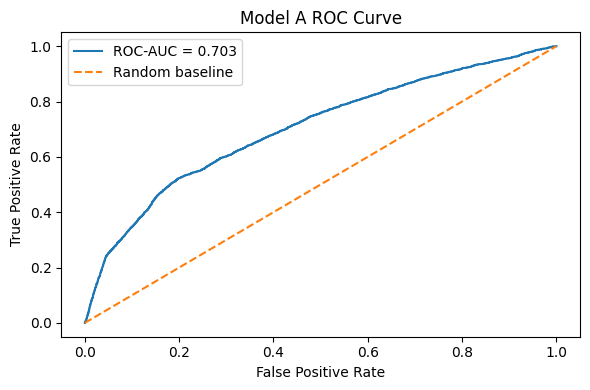

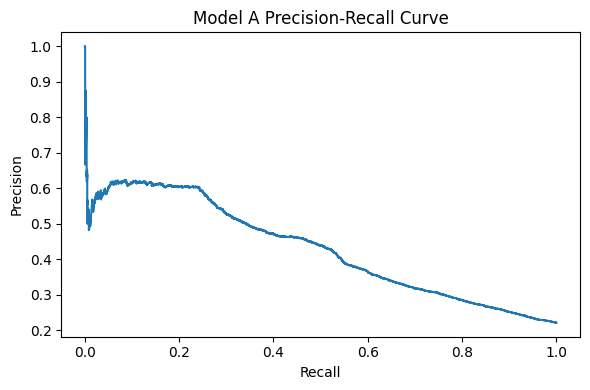

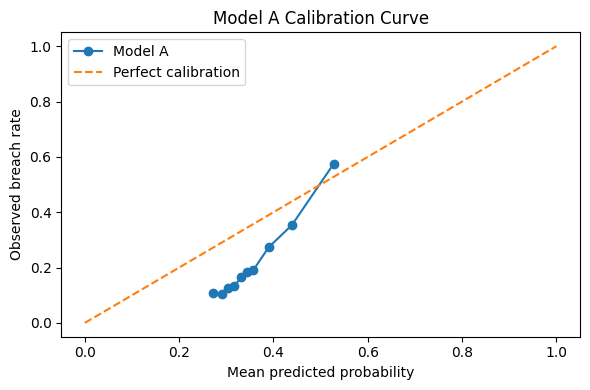

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc
from sklearn.calibration import calibration_curve
pred = pd.read_csv('/content/drive/MyDrive/School/WSB tesis database/O DB/layer4.0/model_a_prevention/modelA_test_predictions.csv')
prob_col = 'predicted_probability_calibrated'
if prob_col not in pred.columns:
 prob_col = 'predicted_sla_breach_probability_calibrated'
y = pred['y_true'].astype(int)
p = pred[prob_col].astype(float)
# ROC curve
fpr, tpr, _ = roc_curve(y, p)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC-AUC = {auc(fpr,tpr):.3f}')
plt.plot([0,1],[0,1],'--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model A ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('modelA_roc_curve.png', dpi=180)
# Precision-recall curve
precision, recall, _ = precision_recall_curve(y, p)
plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Model A Precision-Recall Curve')
plt.tight_layout()
plt.savefig('modelA_precision_recall_curve.png', dpi=180)
# Calibration curve
frac_pos, mean_pred = calibration_curve(y, p, n_bins=10, strategy='quantile')
plt.figure(figsize=(6,4))
plt.plot(mean_pred, frac_pos, marker='o', label='Model A')
plt.plot([0,1],[0,1],'--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed breach rate')
plt.title('Model A Calibration Curve')
plt.legend()
plt.tight_layout()
plt.savefig('modelA_calibration_curve.png', dpi=180)

#layer 5

In [ ]:
# ============================================================
# 1. CONFIGURATION

@dataclass(frozen=True)
class Layer5Config:

    layer2_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/output_layer2"
    layer3_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/layer3"
    layer4_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/layer4.0"
    output_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/layer 5.1"

    # Corrected EV assumptions. These are normalized business assumptions, not facts.
    # Positive class = SLA breach risk.
    ev_true_positive_benefit: float = 2.0
    ev_false_positive_cost: float = -1.0
    ev_false_negative_cost: float = -4.0
    ev_true_negative_value: float = 0.0

    # Sensitivity grid for thesis robustness.
    sensitivity_tp_values: Tuple[float, ...] = (1.0, 2.0, 4.0)
    sensitivity_fp_values: Tuple[float, ...] = (-0.5, -1.0, -2.0)
    sensitivity_fn_values: Tuple[float, ...] = (-2.0, -4.0, -8.0)
    sensitivity_tn_values: Tuple[float, ...] = (0.0,)

    threshold_start: float = 0.01
    threshold_end: float = 0.99
    threshold_step: float = 0.01

    # Capacity-aware policies improve precision by limiting interventions.
    capacity_percentages: Tuple[float, ...] = (0.05, 0.10, 0.20, 0.30)
    default_capacity_for_nba: float = 0.10

    # Precision-oriented thresholds for analysis.
    precision_targets: Tuple[float, ...] = (0.35, 0.45, 0.55)
    recall_targets: Tuple[float, ...] = (0.60, 0.75, 0.85)

    # Layer 4 operational threshold policy.
    # This is NOT the EV threshold. It is the default operational action threshold.
    default_operational_policy_name: str = "recall_target_then_precision"

    # Fallbacks if the exact policy name is not found in Layer 4 output.
    operational_policy_fallbacks: Tuple[str, ...] = (
        "recall_at_least_0.75",
        "best_f1",
        "precision_at_least_0.45",
    )

    # NBA behavior.
    use_layer4_operational_threshold_for_nba: bool = True

    # If True, prevention escalation requires both the Layer 4 threshold and high survival risk.
    # If False, the Layer 4 threshold alone can trigger prevention review.
    require_survival_high_risk_for_prevention: bool = False

    # SHAP settings. Keep sample modest for Colab stability.
    auto_install_shap: bool = True
    shap_sample_size: int = 300
    shap_dense_max_cells: int = 1_000_000
    force_feature_importance_fallback: bool = False
    random_state: int = 42

    # NBA rule settings.
    survival_high_risk_threshold: float = 0.90
    high_confidence_quantile: float = 0.90
    medium_confidence_quantile: float = 0.75
    top_pareto_n_topics: int = 10


# ============================================================
# 2. DATA LOADING

class Layer5DataLoader:
    """Loads Layer 2, Layer 3, and Layer 4 artifacts."""

    def __init__(self, cfg: Layer5Config):
        self.cfg = cfg
        self.layer2_dir = Path(cfg.layer2_dir)
        self.layer3_dir = Path(cfg.layer3_dir)
        self.layer4_dir = Path(cfg.layer4_dir)

    def load_model_a_validation_predictions(self) -> pd.DataFrame:
        return pd.read_csv(self.layer4_dir / "model_a_prevention" / "modelA_validation_predictions.csv")

    def load_model_a_test_predictions(self) -> pd.DataFrame:
        return pd.read_csv(self.layer4_dir / "model_a_prevention" / "modelA_test_predictions.csv")

    def load_model_a_open_predictions(self) -> pd.DataFrame:
        return pd.read_csv(self.layer4_dir / "model_a_prevention" / "modelA_open_predictions.csv")

    def load_model_a_thresholds(self) -> pd.DataFrame:
        """
        Loads Layer 4 Model A threshold policies.

        Preferred:
            modelA_selected_thresholds.csv

        Supported fallback:
            modelA_threshold_policy_table.csv
        """
        candidates = [
            self.layer4_dir / "model_a_prevention" / "modelA_selected_thresholds.csv",
            self.layer4_dir / "model_a_prevention" / "modelA_threshold_policy_table.csv",
        ]

        for path in candidates:
            if path.exists():
                return pd.read_csv(path)

        raise FileNotFoundError(
            "No Model A threshold policy file found in Layer 4. "
            "Expected modelA_selected_thresholds.csv or modelA_threshold_policy_table.csv."
        )

    def load_model_a_pipeline(self) -> Any:
        return self._safe_joblib_load(
            self.layer4_dir / "model_a_prevention" / "modelA_best_uncalibrated_pipeline.joblib"
        )

    def load_model_b_pipeline(self) -> Any:
        return self._safe_joblib_load(
            self.layer4_dir / "model_b_explanation" / "modelB_best_uncalibrated_pipeline.joblib"
        )

    def load_model_a_feature_importance(self) -> pd.DataFrame:
        return pd.read_csv(self.layer4_dir / "model_a_prevention" / "modelA_feature_importance.csv")

    def load_model_b_feature_importance(self) -> pd.DataFrame:
        return pd.read_csv(self.layer4_dir / "model_b_explanation" / "modelB_feature_importance.csv")

    def load_survival_open_risk(self) -> pd.DataFrame:
        path = self.layer4_dir / "survival_time_to_resolution" / "survival_open_risk_scores.csv"
        if path.exists():
            return pd.read_csv(path)
        return pd.DataFrame()

    def load_layer2_issue_summary(self) -> pd.DataFrame:
        preferred = self.layer2_dir / "vaco_L2_issue_topic_business_summary.csv"
        fallback = self.layer2_dir / "vaco_L2_topic_business_summary.csv"

        if preferred.exists():
            return pd.read_csv(preferred)

        if fallback.exists():
            return pd.read_csv(fallback)

        return pd.DataFrame()

    def load_model_a_shap_matrix(self) -> pd.DataFrame:
        path = self.layer3_dir / "model_a_prevention" / "modelA_X_test_clean.csv"
        return pd.read_csv(path) if path.exists() else pd.DataFrame()

    def load_model_b_shap_matrix(self) -> pd.DataFrame:
        path = self.layer3_dir / "model_b_explanation" / "modelB_X_test_clean.csv"
        return pd.read_csv(path) if path.exists() else pd.DataFrame()

    def load_layer4_summary(self) -> Dict[str, Any]:
        path = self.layer4_dir / "L4_layer_summary.json"
        if path.exists():
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
        return {}

    @staticmethod
    def _safe_joblib_load(path: Path) -> Any:
        # Compatibility shim for sklearn joblib objects trained under older versions.
        try:
            import sklearn.compose._column_transformer as ct

            if not hasattr(ct, "_RemainderColsList"):
                class _RemainderColsList(list):
                    pass

                ct._RemainderColsList = _RemainderColsList
        except Exception:
            pass

        try:
            obj = joblib.load(path)
            Layer5DataLoader._patch_simple_imputers(obj)
            return obj
        except Exception as error:
            print(f"WARNING: Could not load model artifact {path}: {type(error).__name__}: {error}")
            print("Real SHAP will be skipped for this model; fallback feature importance will be used.")
            return None

    @staticmethod
    def _patch_simple_imputers(obj: Any) -> None:
        # sklearn 1.8 can require _fill_dtype for imputers saved in older versions.
        try:
            from sklearn.impute import SimpleImputer
        except Exception:
            return

        stack = [obj]
        while stack:
            current = stack.pop()

            if isinstance(current, SimpleImputer) and not hasattr(current, "_fill_dtype"):
                current._fill_dtype = getattr(current, "_fit_dtype", None)

            if hasattr(current, "steps"):
                stack.extend([step for _, step in current.steps])

            if hasattr(current, "transformers_"):
                for transformer in current.transformers_:
                    if len(transformer) >= 2:
                        stack.append(transformer[1])


# ============================================================
# 3. COMMON METRIC HELPERS

class BinaryMetricCalculator:
    """Computes confusion-matrix based metrics from y/probability/threshold."""

    @staticmethod
    def metrics_from_probability(y_true: np.ndarray, proba: np.ndarray, threshold: float) -> Dict[str, Any]:
        pred = (proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

        return {
            "threshold": float(threshold),
            "tp": int(tp),
            "fp": int(fp),
            "fn": int(fn),
            "tn": int(tn),
            "precision": float(precision_score(y_true, pred, zero_division=0)),
            "recall": float(recall_score(y_true, pred, zero_division=0)),
            "f1": float(f1_score(y_true, pred, zero_division=0)),
            "f2": float(fbeta_score(y_true, pred, beta=2, zero_division=0)),
            "accuracy": float(accuracy_score(y_true, pred)),
            "predicted_positive_rate": float(np.mean(pred)),
            "false_positive_rate": float(fp / max(fp + tn, 1)),
            "false_negative_rate": float(fn / max(fn + tp, 1)),
            "roc_auc": float(roc_auc_score(y_true, proba)) if len(np.unique(y_true)) > 1 else np.nan,
            "pr_auc": float(average_precision_score(y_true, proba)) if len(np.unique(y_true)) > 1 else np.nan,
            "brier_score": float(brier_score_loss(y_true, proba)),
        }

    @staticmethod
    def expected_value(metrics: Dict[str, Any], tp_value: float, fp_cost: float, fn_cost: float, tn_value: float) -> float:
        return (
            metrics["tp"] * tp_value
            + metrics["fp"] * fp_cost
            + metrics["fn"] * fn_cost
            + metrics["tn"] * tn_value
        )


# ============================================================
# 4. EXPECTED VALUE + CAPACITY POLICY

class ExpectedValueAnalyzer:
    """Corrected EV framework for Model A. Positive class = SLA breach risk."""

    def __init__(self, cfg: Layer5Config):
        self.cfg = cfg
        self.metrics = BinaryMetricCalculator()

    @staticmethod
    def probability_column(df: pd.DataFrame) -> str:
        candidates = [
            "predicted_probability_calibrated",
            "predicted_sla_breach_probability_calibrated",
            "predicted_probability",
            "predicted_sla_breach_probability",
        ]

        for col in candidates:
            if col in df.columns:
                return col

        raise ValueError(f"No predicted probability column found. Available columns: {list(df.columns)}")

    def build_threshold_curve(self, predictions: pd.DataFrame) -> pd.DataFrame:
        y = predictions["y_true"].astype(int).to_numpy()
        proba = predictions[self.probability_column(predictions)].astype(float).to_numpy()

        thresholds = np.round(
            np.arange(
                self.cfg.threshold_start,
                self.cfg.threshold_end + self.cfg.threshold_step,
                self.cfg.threshold_step,
            ),
            4,
        )

        rows = []

        for threshold in thresholds:
            m = self.metrics.metrics_from_probability(y, proba, threshold)

            total_ev = self.metrics.expected_value(
                m,
                self.cfg.ev_true_positive_benefit,
                self.cfg.ev_false_positive_cost,
                self.cfg.ev_false_negative_cost,
                self.cfg.ev_true_negative_value,
            )

            m["total_expected_value"] = float(total_ev)
            m["expected_value_per_ticket"] = float(total_ev / max(len(y), 1))
            rows.append(m)

        return pd.DataFrame(rows)

    def select_optimal_threshold(self, ev_curve: pd.DataFrame) -> pd.DataFrame:
        return (
            ev_curve.sort_values(
                ["expected_value_per_ticket", "precision"],
                ascending=[False, False],
            )
            .head(1)
            .reset_index(drop=True)
        )

    def build_sensitivity_grid(self, predictions: pd.DataFrame) -> pd.DataFrame:
        """Fast cost sensitivity. Reuses threshold confusion counts instead of recalculating metrics."""
        base_curve = self.build_threshold_curve(predictions).copy()
        rows = []

        for tp_value in self.cfg.sensitivity_tp_values:
            for fp_cost in self.cfg.sensitivity_fp_values:
                for fn_cost in self.cfg.sensitivity_fn_values:
                    for tn_value in self.cfg.sensitivity_tn_values:
                        temp = base_curve.copy()

                        temp["tp_value"] = tp_value
                        temp["fp_cost"] = fp_cost
                        temp["fn_cost"] = fn_cost
                        temp["tn_value"] = tn_value

                        temp["total_expected_value"] = (
                            temp["tp"] * tp_value
                            + temp["fp"] * fp_cost
                            + temp["fn"] * fn_cost
                            + temp["tn"] * tn_value
                        )

                        temp["expected_value_per_ticket"] = (
                            temp["total_expected_value"] / max(len(predictions), 1)
                        )

                        best = (
                            temp.sort_values(
                                ["expected_value_per_ticket", "precision"],
                                ascending=[False, False],
                            )
                            .iloc[0]
                            .to_dict()
                        )

                        rows.append(best)

        return pd.DataFrame(rows)

    def build_precision_recall_policy_table(self, predictions: pd.DataFrame) -> pd.DataFrame:
        curve = self.build_threshold_curve(predictions)
        rows = []

        for target in self.cfg.precision_targets:
            subset = curve[curve["precision"] >= target]
            if not subset.empty:
                row = subset.sort_values(["recall", "f1"], ascending=False).iloc[0].to_dict()
                row["policy"] = f"precision_at_least_{target:.2f}"
                rows.append(row)

        for target in self.cfg.recall_targets:
            subset = curve[curve["recall"] >= target]
            if not subset.empty:
                row = subset.sort_values(["precision", "f1"], ascending=False).iloc[0].to_dict()
                row["policy"] = f"recall_at_least_{target:.2f}"
                rows.append(row)

        if not curve.empty:
            row = curve.sort_values(["f1", "precision"], ascending=False).iloc[0].to_dict()
            row["policy"] = "best_f1"
            rows.append(row)

            row = curve.sort_values(["f2", "recall"], ascending=False).iloc[0].to_dict()
            row["policy"] = "best_f2_recall_weighted"
            rows.append(row)

        return pd.DataFrame(rows)

    def build_capacity_policy(self, predictions: pd.DataFrame) -> pd.DataFrame:
        """Top-N capacity policies: improve operational precision by limiting escalations."""
        y = predictions["y_true"].astype(int).to_numpy()
        proba_col = self.probability_column(predictions)
        proba = predictions[proba_col].astype(float).to_numpy()

        order = np.argsort(-proba)
        rows = []
        n = len(predictions)

        for cap in self.cfg.capacity_percentages:
            k = max(1, int(np.ceil(n * cap)))

            pred = np.zeros(n, dtype=int)
            pred[order[:k]] = 1

            threshold = float(np.min(proba[order[:k]]))
            tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()

            m = {
                "capacity_percent": cap,
                "tickets_escalated": int(k),
                "threshold_implied_by_capacity": threshold,
                "tp": int(tp),
                "fp": int(fp),
                "fn": int(fn),
                "tn": int(tn),
                "precision_at_capacity": float(precision_score(y, pred, zero_division=0)),
                "recall_at_capacity": float(recall_score(y, pred, zero_division=0)),
                "f1_at_capacity": float(f1_score(y, pred, zero_division=0)),
            }

            ev = self.metrics.expected_value(
                m,
                self.cfg.ev_true_positive_benefit,
                self.cfg.ev_false_positive_cost,
                self.cfg.ev_false_negative_cost,
                self.cfg.ev_true_negative_value,
            )

            m["total_expected_value"] = float(ev)
            m["expected_value_per_ticket"] = float(ev / max(n, 1))
            rows.append(m)

        return pd.DataFrame(rows)

    def apply_open_capacity_flags(self, open_predictions: pd.DataFrame) -> pd.DataFrame:
        out = open_predictions.copy()
        proba_col = self.probability_column(out)
        n = len(out)

        order = out[proba_col].astype(float).sort_values(ascending=False).index

        out["risk_rank"] = out[proba_col].rank(method="first", ascending=False).astype(int)
        out["risk_percentile"] = 1.0 - ((out["risk_rank"] - 1) / max(n - 1, 1))

        for cap in self.cfg.capacity_percentages:
            k = max(1, int(np.ceil(n * cap)))
            col = f"flag_top_{int(cap * 100)}pct_capacity"
            out[col] = 0
            out.loc[order[:k], col] = 1

        return out


# ============================================================
# 4B. LAYER 4 OPERATIONAL THRESHOLD SELECTOR

class Layer4OperationalThresholdSelector:
    """
    Selects the default operational threshold from Layer 4 Model A policies.

    Important:
    - This is not the EV-optimal threshold.
    - This is the validated operational threshold from Layer 4.
    - Default target policy: recall_target_then_precision.
    """

    def __init__(self, cfg: Layer5Config):
        self.cfg = cfg
        self.metrics = BinaryMetricCalculator()

    def select(self, threshold_table: pd.DataFrame) -> pd.DataFrame:
        """
        Returns a one-row dataframe with the selected operational threshold.
        """

        if threshold_table.empty:
            raise ValueError("Layer 4 threshold table is empty.")

        table = threshold_table.copy()

        policy_col = self._find_column(
            table,
            ["policy", "selected_policy", "policy_name", "threshold_policy"],
            required=True,
        )

        threshold_col = self._find_column(
            table,
            ["threshold", "selected_threshold", "decision_threshold", "operational_threshold"],
            required=True,
        )

        table[policy_col] = table[policy_col].astype(str)

        # First try exact preferred policy.
        preferred = table[
            table[policy_col].str.lower() == self.cfg.default_operational_policy_name.lower()
        ]

        if not preferred.empty:
            selected = preferred.iloc[[0]].copy()
            selected["selection_reason"] = "preferred_layer4_policy"
        else:
            selected = pd.DataFrame()

            # Try fallbacks.
            for fallback in self.cfg.operational_policy_fallbacks:
                candidate = table[table[policy_col].str.lower() == fallback.lower()]
                if not candidate.empty:
                    selected = candidate.iloc[[0]].copy()
                    selected["selection_reason"] = f"fallback_policy_used:{fallback}"
                    break

            # Last fallback: best F1 if present.
            if selected.empty and "f1" in table.columns:
                selected = table.sort_values("f1", ascending=False).iloc[[0]].copy()
                selected["selection_reason"] = "fallback_best_f1_available"

            # Final fallback: first row.
            if selected.empty:
                selected = table.iloc[[0]].copy()
                selected["selection_reason"] = "fallback_first_row"

        selected = selected.rename(
            columns={
                policy_col: "selected_policy",
                threshold_col: "operational_threshold",
            }
        )

        selected["threshold_source"] = "Layer4_ModelA_threshold_policy"
        selected["requested_policy"] = self.cfg.default_operational_policy_name
        selected["operational_threshold"] = selected["operational_threshold"].astype(float)

        keep_cols = [
            "threshold_source",
            "requested_policy",
            "selected_policy",
            "operational_threshold",
            "selection_reason",
        ]

        extra_cols = [
            c for c in selected.columns
            if c not in keep_cols
            and c.lower()
            in [
                "validation_precision",
                "validation_recall",
                "validation_f1",
                "precision",
                "recall",
                "f1",
                "f2",
                "rationale",
            ]
        ]

        return selected[keep_cols + extra_cols].reset_index(drop=True)

    def evaluate_on_predictions(
        self,
        predictions: pd.DataFrame,
        selected_threshold: pd.DataFrame,
        dataset_name: str,
    ) -> pd.DataFrame:
        """
        Evaluates the selected Layer 4 operational threshold on validation/test predictions.
        """

        if selected_threshold.empty:
            raise ValueError("Selected threshold dataframe is empty.")

        threshold = float(selected_threshold["operational_threshold"].iloc[0])

        proba_col = ExpectedValueAnalyzer.probability_column(predictions)
        y_true = predictions["y_true"].astype(int).to_numpy()
        proba = predictions[proba_col].astype(float).to_numpy()

        metrics = self.metrics.metrics_from_probability(y_true, proba, threshold)

        metrics["dataset"] = dataset_name
        metrics["threshold_source"] = selected_threshold["threshold_source"].iloc[0]
        metrics["selected_policy"] = selected_threshold["selected_policy"].iloc[0]
        metrics["operational_threshold"] = threshold

        return pd.DataFrame([metrics])

    def apply_to_open_predictions(
        self,
        open_predictions: pd.DataFrame,
        selected_threshold: pd.DataFrame,
    ) -> pd.DataFrame:
        """
        Adds the Layer 4 operational threshold flag to open-ticket predictions.
        """

        if selected_threshold.empty:
            raise ValueError("Selected threshold dataframe is empty.")

        out = open_predictions.copy()

        threshold = float(selected_threshold["operational_threshold"].iloc[0])
        policy = str(selected_threshold["selected_policy"].iloc[0])

        proba_col = ExpectedValueAnalyzer.probability_column(out)

        out["layer4_operational_threshold"] = threshold
        out["layer4_operational_policy"] = policy
        out["layer4_threshold_source"] = "Layer4_ModelA_threshold_policy"
        out["flag_layer4_operational_threshold"] = (
            out[proba_col].astype(float) >= threshold
        ).astype(int)

        return out

    @staticmethod
    def _find_column(df: pd.DataFrame, candidates: List[str], required: bool = True) -> Optional[str]:
        for col in candidates:
            if col in df.columns:
                return col

        if required:
            raise ValueError(
                f"Required column not found. Tried {candidates}. "
                f"Available columns: {list(df.columns)}"
            )

        return None


# ============================================================
# 5. SHAP / EXPLAINABILITY

class ShapProvider:
    """Imports SHAP and optionally installs it in Colab."""

    def __init__(self, cfg: Layer5Config):
        self.cfg = cfg

    def get(self):
        try:
            return importlib.import_module("shap")
        except Exception as first_error:
            if not self.cfg.auto_install_shap:
                raise ImportError("SHAP is required for real explainability.") from first_error

            print("shap not found. Installing shap in this runtime...")

            try:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "shap"])
                return importlib.import_module("shap")
            except Exception as second_error:
                raise ImportError("Could not install/import shap. Run: !pip install shap") from second_error



class ModelExplainer:
    """Computes real SHAP if possible; otherwise writes honest fallback files."""

    def __init__(self, cfg: Layer5Config):
        self.cfg = cfg
        self.provider = ShapProvider(cfg)

    def explain(
        self,
        pipeline: Any,
        X_raw: pd.DataFrame,
        fallback_importance: pd.DataFrame,
        model_prefix: str,
    ) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, Any]]:

        if self.cfg.force_feature_importance_fallback:
            summary = self._fallback(fallback_importance, model_prefix)
            return summary, pd.DataFrame(), {
                "model": model_prefix,
                "status": "fallback_feature_importance",
                "reason": "forced_by_config",
            }

        if pipeline is None or X_raw.empty:
            summary = self._fallback(fallback_importance, model_prefix)
            return summary, pd.DataFrame(), {
                "model": model_prefix,
                "status": "fallback_feature_importance",
                "reason": "pipeline_or_X_missing",
            }

        try:
            shap = self.provider.get()

            preprocessor = pipeline.named_steps.get("preprocessor")
            classifier = pipeline.named_steps.get("classifier")

            if preprocessor is None or classifier is None:
                raise ValueError("Pipeline missing preprocessor or classifier step.")

            X_sample = X_raw.sample(
                min(len(X_raw), self.cfg.shap_sample_size),
                random_state=self.cfg.random_state,
            )

            X_transformed = preprocessor.transform(X_sample)
            feature_names = list(preprocessor.get_feature_names_out())

            # SHAP can be unstable with sparse matrices depending on model/version.
            if hasattr(X_transformed, "toarray"):
                cells = X_transformed.shape[0] * X_transformed.shape[1]
                X_for_shap = X_transformed.toarray() if cells <= self.cfg.shap_dense_max_cells else X_transformed
            else:
                X_for_shap = X_transformed

            explainer = shap.TreeExplainer(classifier)
            shap_values = explainer.shap_values(X_for_shap)
            shap_array = self._normalize_shap_values(shap_values)

            n_features = min(shap_array.shape[1], len(feature_names))
            shap_array = shap_array[:, :n_features]
            feature_names = feature_names[:n_features]

            summary = pd.DataFrame(
                {
                    "feature": feature_names,
                    "mean_abs_shap": np.mean(np.abs(shap_array), axis=0),
                    "mean_shap": np.mean(shap_array, axis=0),
                    "explanation_source": "real_shap",
                    "model_prefix": model_prefix,
                }
            ).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

            sample_values = pd.DataFrame(shap_array, columns=feature_names)
            sample_values.insert(0, "sample_id", range(len(sample_values)))

            return summary, sample_values, {
                "model": model_prefix,
                "status": "real_shap",
                "sample_size": len(X_sample),
                "features": n_features,
            }

        except Exception as error:
            summary = self._fallback(fallback_importance, model_prefix)
            return summary, pd.DataFrame(), {
                "model": model_prefix,
                "status": "fallback_feature_importance",
                "reason": f"{type(error).__name__}: {error}",
            }

    @staticmethod
    def _normalize_shap_values(shap_values: Any) -> np.ndarray:
        if isinstance(shap_values, list):
            arr = np.asarray(shap_values[-1])
        else:
            arr = np.asarray(shap_values)

        if arr.ndim == 3:
            # Common shape: samples x features x classes. Use class 1.
            arr = arr[:, :, -1]

        if arr.ndim != 2:
            raise ValueError(f"Unexpected SHAP shape: {arr.shape}")

        return arr

    @staticmethod
    def _fallback(fallback_importance: pd.DataFrame, model_prefix: str) -> pd.DataFrame:
        if fallback_importance is None or fallback_importance.empty:
            return pd.DataFrame(columns=["feature", "importance", "explanation_source", "model_prefix"])

        out = fallback_importance.copy()

        if "importance" not in out.columns:
            possible = [c for c in out.columns if c != "feature"]
            out["importance"] = out[possible[0]] if possible else 0

        out["explanation_source"] = "feature_importance_fallback"
        out["model_prefix"] = model_prefix

        return out


# ============================================================
# 6. ISHIKAWA AGGREGATION

class IshikawaMapper:
    """Aggregates SHAP/fallback feature importance into operational branches."""

    BRANCH_RULES = {
        "Machine": ["product", "operating_system"],
        "Method": ["channel", "priority", "expected_sla_hours", "sla"],
        "Manpower": ["agent_id", "language"],
        "Measurement": [
            "created_",
            "ticket_age",
            "current_age",
            "issue_topic_was_outlier",
            "resolution_action_was_outlier",
            "resolution_time",
            "nps",
            "satisfaction",
            "csat",
        ],
        "Material": ["issue_topic_cluster", "resolution_action_cluster", "category"],
        "Environment": ["region", "weekend", "dayofweek", "hour", "month", "weekofyear"],
    }

    def assign_branch(self, feature: str) -> str:
        f = str(feature).lower()

        for branch, tokens in self.BRANCH_RULES.items():
            if any(token in f for token in tokens):
                return branch

        return "Other"

    def aggregate(self, explanation_summary: pd.DataFrame, model_prefix: str) -> pd.DataFrame:
        if explanation_summary.empty:
            return pd.DataFrame(
                columns=[
                    "ishikawa_branch",
                    "total_importance",
                    "feature_count",
                    "share_of_total",
                    "model_prefix",
                    "explanation_source",
                ]
            )

        data = explanation_summary.copy()
        metric_col = "mean_abs_shap" if "mean_abs_shap" in data.columns else "importance"

        source = (
            data["explanation_source"].iloc[0]
            if "explanation_source" in data.columns and not data.empty
            else "unknown"
        )

        data["ishikawa_branch"] = data["feature"].apply(self.assign_branch)

        grouped = (
            data.groupby("ishikawa_branch")
            .agg(
                total_importance=(metric_col, "sum"),
                feature_count=("feature", "count"),
            )
            .reset_index()
        )

        total = grouped["total_importance"].sum()
        grouped["share_of_total"] = grouped["total_importance"] / max(total, 1e-12)
        grouped["model_prefix"] = model_prefix
        grouped["explanation_source"] = source

        return grouped.sort_values("total_importance", ascending=False).reset_index(drop=True)


# ============================================================
# 7. WEIGHTED PARETO

class WeightedParetoBuilder:
    """Builds topic-level weighted risk ranking. Topic -1 is triage, not semantic root cause."""

    def build(
        self,
        model_a_open: pd.DataFrame,
        survival_open: pd.DataFrame,
        issue_summary: pd.DataFrame,
    ) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

        prob_col = ExpectedValueAnalyzer.probability_column(model_a_open)
        merged = model_a_open.copy()

        if not survival_open.empty and "ticket_id" in survival_open.columns:
            merged = merged.merge(survival_open, on="ticket_id", how="left", suffixes=("", "_survival"))

        if "risk_unresolved_beyond_sla" in merged.columns and "survival_risk_unresolved_beyond_sla" not in merged.columns:
            merged["survival_risk_unresolved_beyond_sla"] = merged["risk_unresolved_beyond_sla"]

        if "survival_risk_unresolved_beyond_sla" not in merged.columns:
            merged["survival_risk_unresolved_beyond_sla"] = 1.0

        merged["survival_risk_unresolved_beyond_sla"] = (
            merged["survival_risk_unresolved_beyond_sla"]
            .fillna(1.0)
            .astype(float)
        )

        if "already_past_sla" not in merged.columns:
            merged["already_past_sla"] = False

        merged["already_past_sla"] = merged["already_past_sla"].fillna(False).astype(bool)

        merged["ticket_risk_score"] = (
            merged[prob_col].astype(float)
            * merged["survival_risk_unresolved_beyond_sla"].astype(float)
        )

        grouped = (
            merged.groupby("issue_topic_cluster", dropna=False)
            .agg(
                open_volume=("ticket_id", "count"),
                mean_model_a_probability=(prob_col, "mean"),
                mean_survival_risk=("survival_risk_unresolved_beyond_sla", "mean"),
                mean_ticket_risk_score=("ticket_risk_score", "mean"),
                already_past_sla_rate=("already_past_sla", "mean"),
                issue_topic_outlier_rate=(
                    "issue_topic_was_outlier",
                    "mean",
                )
                if "issue_topic_was_outlier" in merged.columns
                else (prob_col, "mean"),
            )
            .reset_index()
        )

        grouped["weighted_pareto_risk_score"] = (
            grouped["open_volume"] * grouped["mean_ticket_risk_score"]
        )

        grouped = grouped.sort_values("weighted_pareto_risk_score", ascending=False).reset_index(drop=True)
        grouped["cumulative_risk_score"] = grouped["weighted_pareto_risk_score"].cumsum()
        grouped["cumulative_risk_share"] = grouped["cumulative_risk_score"] / max(
            grouped["weighted_pareto_risk_score"].sum(),
            1e-12,
        )

        if not issue_summary.empty:
            issue_summary_clean = issue_summary.copy()

            if "topic_cluster" in issue_summary_clean.columns and "issue_topic_cluster" not in issue_summary_clean.columns:
                issue_summary_clean = issue_summary_clean.rename(columns={"topic_cluster": "issue_topic_cluster"})

            keep = [
                c
                for c in [
                    "issue_topic_cluster",
                    "issue_topic_label",
                    "volume",
                    "sla_breach_rate",
                    "low_csat_rate",
                    "service_failure_or_rate",
                    "service_failure_and_rate",
                ]
                if c in issue_summary_clean.columns
            ]

            if "issue_topic_cluster" in keep:
                grouped = grouped.merge(
                    issue_summary_clean[keep].drop_duplicates("issue_topic_cluster"),
                    on="issue_topic_cluster",
                    how="left",
                )

        topic_minus1 = grouped[grouped["issue_topic_cluster"].astype(str) == "-1"].copy()
        semantic_only = grouped[grouped["issue_topic_cluster"].astype(str) != "-1"].copy()

        return grouped, semantic_only, topic_minus1


# ============================================================
# 8. NEXT BEST ACTION ENGINE

class NextBestActionEngine:
    """Creates precise, capacity-aware operational queues."""

    def __init__(self, cfg: Layer5Config):
        self.cfg = cfg

    def build(
        self,
        model_a_open_with_capacity: pd.DataFrame,
        survival_open: pd.DataFrame,
        pareto: pd.DataFrame,
    ) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
        """
        New hierarchy:

        1. already_past_sla=True -> recovery_queue
        2. topic -1 and not past SLA -> topic_minus1_triage_queue
        3. Layer 4 operational threshold flag -> prevention_queue
        4. capacity flag / high confidence -> high_confidence_queue
        5. top semantic Pareto topic -> monitoring_queue
        6. otherwise -> standard monitoring
        """

        out = model_a_open_with_capacity.copy()
        prob_col = ExpectedValueAnalyzer.probability_column(out)

        if not survival_open.empty and "ticket_id" in survival_open.columns:
            out = out.merge(survival_open, on="ticket_id", how="left", suffixes=("", "_survival"))

        if "risk_unresolved_beyond_sla" in out.columns and "survival_risk_unresolved_beyond_sla" not in out.columns:
            out["survival_risk_unresolved_beyond_sla"] = out["risk_unresolved_beyond_sla"]

        if "survival_risk_unresolved_beyond_sla" not in out.columns:
            out["survival_risk_unresolved_beyond_sla"] = 1.0

        out["survival_risk_unresolved_beyond_sla"] = (
            out["survival_risk_unresolved_beyond_sla"]
            .fillna(1.0)
            .astype(float)
        )

        if "already_past_sla" not in out.columns:
            out["already_past_sla"] = False

        out["already_past_sla"] = out["already_past_sla"].fillna(False).astype(bool)

        if "flag_layer4_operational_threshold" not in out.columns:
            out["flag_layer4_operational_threshold"] = 0

        top_semantic_topics = set(
            pareto[pareto["issue_topic_cluster"].astype(str) != "-1"]
            .head(self.cfg.top_pareto_n_topics)["issue_topic_cluster"]
            .astype(str)
            .tolist()
        )

        out["is_topic_minus1"] = out["issue_topic_cluster"].astype(str).eq("-1")
        out["is_top_semantic_pareto_topic"] = out["issue_topic_cluster"].astype(str).isin(top_semantic_topics)

        out["high_confidence_flag"] = (
            out["risk_percentile"] >= self.cfg.high_confidence_quantile
            if "risk_percentile" in out.columns
            else False
        )

        out["medium_confidence_flag"] = (
            out["risk_percentile"] >= self.cfg.medium_confidence_quantile
            if "risk_percentile" in out.columns
            else False
        )

        default_cap_col = f"flag_top_{int(self.cfg.default_capacity_for_nba * 100)}pct_capacity"

        if default_cap_col not in out.columns:
            out[default_cap_col] = 0

        priorities = []
        queues = []
        actions = []
        reasons = []

        for _, row in out.iterrows():
            past_sla = bool(row.get("already_past_sla", False))
            topic_minus1 = bool(row.get("is_topic_minus1", False))
            operational_flag = int(row.get("flag_layer4_operational_threshold", 0)) == 1
            top_capacity = int(row.get(default_cap_col, 0)) == 1
            high_confidence = bool(row.get("high_confidence_flag", False))
            top_topic = bool(row.get("is_top_semantic_pareto_topic", False))
            survival_high = (
                float(row.get("survival_risk_unresolved_beyond_sla", 0.0))
                >= self.cfg.survival_high_risk_threshold
            )

            # 1. Recovery overrides everything.
            if past_sla:
                priorities.append("P0")
                queues.append("recovery_queue")
                actions.append("urgent_sla_recovery_review")
                reasons.append("Ticket is already past SLA; recovery action overrides prevention.")

            # 2. Topic -1 is triage, not semantic root cause.
            elif topic_minus1:
                priorities.append("P1")
                queues.append("topic_minus1_triage_queue")
                actions.append("triage_and_reclassify_unmapped_topic")
                reasons.append("Topic -1 means the issue is unclassified/outlier; triage before root-cause claim.")

            # 3. Main prevention rule from Layer 4 operational threshold.
            elif operational_flag and (
                survival_high or not self.cfg.require_survival_high_risk_for_prevention
            ):
                priorities.append("P1")
                queues.append("prevention_queue")
                actions.append("escalate_before_sla_deadline")
                reasons.append("Ticket exceeded the Layer 4 recall_target_then_precision operational threshold.")

            # 4. High-confidence but not primary prevention.
            elif high_confidence or top_capacity:
                priorities.append("P2")
                queues.append("high_confidence_queue")
                actions.append("senior_agent_review")
                reasons.append("Ticket is high-confidence or inside the selected top-capacity risk group.")

            # 5. Pareto monitoring.
            elif top_topic:
                priorities.append("P3")
                queues.append("monitoring_queue")
                actions.append("monitor_due_to_high_pareto_topic")
                reasons.append("Ticket belongs to a high weighted-Pareto semantic topic.")

            # 6. Standard monitoring.
            else:
                priorities.append("P4")
                queues.append("monitoring_queue")
                actions.append("standard_queue_monitoring")
                reasons.append("No high-risk operational rule triggered.")

        out["nba_priority"] = priorities
        out["nba_queue"] = queues
        out["nba_action"] = actions
        out["nba_reason"] = reasons

        out = out.sort_values(["nba_priority", prob_col], ascending=[True, False]).reset_index(drop=True)

        queues_dict = {
            "recovery_queue": out[out["nba_queue"] == "recovery_queue"].copy(),
            "prevention_queue": out[out["nba_queue"] == "prevention_queue"].copy(),
            "monitoring_queue": out[out["nba_queue"] == "monitoring_queue"].copy(),
            "topic_minus1_triage_queue": out[out["is_topic_minus1"]].copy(),
            "high_confidence_queue": out[out["nba_queue"] == "high_confidence_queue"].copy(),
        }

        return out, queues_dict


# ============================================================
# 9. OUTPUT WRITER

class Layer5OutputWriter:
    """Writes Layer 5 artifacts."""

    def __init__(self, cfg: Layer5Config):
        self.cfg = cfg
        self.output_dir = Path(cfg.output_dir)

        for folder in [
            "ev_framework",
            "explainability_shap",
            "dynamic_ishikawa",
            "weighted_pareto",
            "nba_rules",
        ]:
            (self.output_dir / folder).mkdir(parents=True, exist_ok=True)

    def write_csv(self, relative_path: str, df: pd.DataFrame) -> None:
        path = self.output_dir / relative_path
        path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(path, index=False)

    def write_json(self, relative_path: str, payload: Dict[str, Any]) -> None:
        path = self.output_dir / relative_path
        path.parent.mkdir(parents=True, exist_ok=True)

        with open(path, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2, default=str)


# ============================================================
# 10. PIPELINE ORCHESTRATOR

class Layer5Pipeline:
    """Thin orchestrator for Layer 5. Does not train models."""

    def __init__(self, cfg: Layer5Config):
        self.cfg = cfg
        self.loader = Layer5DataLoader(cfg)
        self.ev = ExpectedValueAnalyzer(cfg)
        self.operational_threshold_selector = Layer4OperationalThresholdSelector(cfg)
        self.explainer = ModelExplainer(cfg)
        self.ishikawa = IshikawaMapper()
        self.pareto = WeightedParetoBuilder()
        self.nba = NextBestActionEngine(cfg)
        self.writer = Layer5OutputWriter(cfg)

    def run(self) -> None:
        print("Layer 5 improved run started. No model training.")

        # -----------------------
        # EV framework
        # -----------------------
        print("Building corrected EV framework and capacity policies...")

        model_a_valid = self.loader.load_model_a_validation_predictions()
        ev_curve = self.ev.build_threshold_curve(model_a_valid)
        ev_best = self.ev.select_optimal_threshold(ev_curve)
        ev_sensitivity = self.ev.build_sensitivity_grid(model_a_valid)
        ev_capacity = self.ev.build_capacity_policy(model_a_valid)
        ev_policy = self.ev.build_precision_recall_policy_table(model_a_valid)

        self.writer.write_csv("ev_framework/modelA_ev_threshold_curve_corrected.csv", ev_curve)
        self.writer.write_csv("ev_framework/modelA_ev_optimal_threshold_corrected.csv", ev_best)
        self.writer.write_csv("ev_framework/modelA_ev_sensitivity_grid.csv", ev_sensitivity)
        self.writer.write_csv("ev_framework/modelA_ev_capacity_policy.csv", ev_capacity)
        self.writer.write_csv("ev_framework/modelA_precision_recall_policy_table.csv", ev_policy)

        # -----------------------
        # Automatic Layer 4 operational threshold
        # -----------------------
        print("Loading Layer 4 Model A operational threshold policy...")

        model_a_thresholds = self.loader.load_model_a_thresholds()
        selected_operational_threshold = self.operational_threshold_selector.select(model_a_thresholds)

        self.writer.write_csv(
            "ev_framework/modelA_layer4_operational_threshold.csv",
            selected_operational_threshold,
        )

        model_a_test = self.loader.load_model_a_test_predictions()

        operational_threshold_metrics = pd.concat(
            [
                self.operational_threshold_selector.evaluate_on_predictions(
                    model_a_valid,
                    selected_operational_threshold,
                    dataset_name="validation",
                ),
                self.operational_threshold_selector.evaluate_on_predictions(
                    model_a_test,
                    selected_operational_threshold,
                    dataset_name="test",
                ),
            ],
            ignore_index=True,
        )

        self.writer.write_csv(
            "ev_framework/modelA_layer4_operational_threshold_metrics.csv",
            operational_threshold_metrics,
        )

        # Apply Layer 4 operational threshold to open tickets, then add capacity flags.
        model_a_open = self.loader.load_model_a_open_predictions()

        model_a_open_operational = self.operational_threshold_selector.apply_to_open_predictions(
            model_a_open,
            selected_operational_threshold,
        )

        model_a_open_capacity = self.ev.apply_open_capacity_flags(model_a_open_operational)

        self.writer.write_csv(
            "ev_framework/modelA_open_capacity_flags.csv",
            model_a_open_capacity,
        )

        # -----------------------
        # SHAP / fallback explanations
        # -----------------------
        print("Building real SHAP if possible; otherwise honest fallback...")

        model_a_summary, model_a_shap_values, model_a_status = self.explainer.explain(
            self.loader.load_model_a_pipeline(),
            self.loader.load_model_a_shap_matrix(),
            self.loader.load_model_a_feature_importance(),
            "modelA",
        )

        model_b_summary, model_b_shap_values, model_b_status = self.explainer.explain(
            self.loader.load_model_b_pipeline(),
            self.loader.load_model_b_shap_matrix(),
            self.loader.load_model_b_feature_importance(),
            "modelB",
        )

        self.writer.write_csv("explainability_shap/modelA_explanation_feature_summary.csv", model_a_summary)
        self.writer.write_csv("explainability_shap/modelB_explanation_feature_summary.csv", model_b_summary)
        self.writer.write_csv("explainability_shap/modelA_real_shap_sample_values.csv", model_a_shap_values)
        self.writer.write_csv("explainability_shap/modelB_real_shap_sample_values.csv", model_b_shap_values)
        self.writer.write_json("explainability_shap/modelA_shap_status.json", model_a_status)
        self.writer.write_json("explainability_shap/modelB_shap_status.json", model_b_status)

        # -----------------------
        # Dynamic Ishikawa
        # -----------------------
        print("Building dynamic Ishikawa aggregations...")

        model_a_ishikawa = self.ishikawa.aggregate(model_a_summary, "modelA")
        model_b_ishikawa = self.ishikawa.aggregate(model_b_summary, "modelB")
        combined_ishikawa = pd.concat([model_a_ishikawa, model_b_ishikawa], ignore_index=True)

        self.writer.write_csv("dynamic_ishikawa/modelA_ishikawa_branches.csv", model_a_ishikawa)
        self.writer.write_csv("dynamic_ishikawa/modelB_ishikawa_branches.csv", model_b_ishikawa)
        self.writer.write_csv("dynamic_ishikawa/combined_ishikawa_branches.csv", combined_ishikawa)

        self.writer.write_json(
            "dynamic_ishikawa/dynamic_ishikawa_export.json",
            {
                "modelA": model_a_ishikawa.to_dict(orient="records"),
                "modelB": model_b_ishikawa.to_dict(orient="records"),
                "warning": "This is model-importance Ishikawa, not causal proof.",
                "modelA_explanation_status": model_a_status,
                "modelB_explanation_status": model_b_status,
            },
        )

        # -----------------------
        # Weighted Pareto
        # -----------------------
        print("Building weighted Pareto and topic -1 triage summary...")

        survival_open = self.loader.load_survival_open_risk()
        issue_summary = self.loader.load_layer2_issue_summary()

        pareto_all, pareto_semantic, topic_minus1 = self.pareto.build(
            model_a_open_capacity,
            survival_open,
            issue_summary,
        )

        self.writer.write_csv("weighted_pareto/weighted_pareto_topic_risk.csv", pareto_all)
        self.writer.write_csv("weighted_pareto/weighted_pareto_semantic_topics_only.csv", pareto_semantic)
        self.writer.write_csv("weighted_pareto/topic_minus1_triage_summary.csv", topic_minus1)

        # -----------------------
        # NBA queues
        # -----------------------
        print("Building capacity-aware NBA queues...")

        nba_all, queues = self.nba.build(
            model_a_open_capacity,
            survival_open,
            pareto_all,
        )

        self.writer.write_csv("nba_rules/nba_open_ticket_recommendations.csv", nba_all)
        self.writer.write_csv("nba_rules/layer6_dashboard_input.csv", nba_all)

        for name, df in queues.items():
            self.writer.write_csv(f"nba_rules/{name}.csv", df)

        # -----------------------
        # Summary
        # -----------------------
        summary = {
            "layer": "Layer 5 - operational precision and decision support",
            "no_smote_used": True,
            "model_training_performed": False,
            "ev_default_matrix": {
                "true_positive_benefit": self.cfg.ev_true_positive_benefit,
                "false_positive_cost": self.cfg.ev_false_positive_cost,
                "false_negative_cost": self.cfg.ev_false_negative_cost,
                "true_negative_value": self.cfg.ev_true_negative_value,
                "interpretation": "Positive class is SLA breach risk. TP positive, FP negative, FN strongly negative, TN neutral.",
            },
            "threshold_logic": {
                "ev_threshold_role": "analysis_and_sensitivity_only",
                "layer4_operational_threshold_role": "default_NBA_action_threshold",
                "capacity_threshold_role": "precision_control_when_intervention_capacity_is_limited",
                "warning": "The Layer 4 operational threshold is not the EV-optimal threshold. It is the validated recall-target policy selected in Layer 4.",
            },
            "ev_best_threshold": ev_best.to_dict(orient="records"),
            "layer4_operational_threshold": selected_operational_threshold.to_dict(orient="records"),
            "layer4_operational_threshold_metrics": operational_threshold_metrics.to_dict(orient="records"),
            "capacity_policies": ev_capacity.to_dict(orient="records"),
            "explainability_status": {
                "modelA": model_a_status,
                "modelB": model_b_status,
            },
            "pareto_top_10": pareto_all.head(10).to_dict(orient="records"),
            "nba_action_counts": nba_all["nba_action"].value_counts().to_dict() if "nba_action" in nba_all.columns else {},
            "nba_queue_counts": nba_all["nba_queue"].value_counts().to_dict() if "nba_queue" in nba_all.columns else {},
            "blind_spots": [
                "EV depends on assumed cost values and should be reviewed with business stakeholders.",
                "The Layer 4 operational threshold is validation-derived and should be recalibrated with new data.",
                "Real SHAP only exists if shap_status is real_shap; fallback feature importance is not SHAP.",
                "Topic -1 is treated as triage/unclassified, not a semantic root cause.",
                "NBA actions are recommendations; Layer 6 must simulate or evaluate operational impact.",
            ],
        }

        self.writer.write_json("L5_layer_summary.json", summary)

        print("Layer 5 improved run complete.")
        print(f"Outputs saved to: {self.cfg.output_dir}")

        print("\nEV best threshold:")
        print(ev_best.to_string(index=False))

        print("\nLayer 4 operational threshold:")
        print(selected_operational_threshold.to_string(index=False))

        print("\nLayer 4 operational threshold metrics:")
        print(operational_threshold_metrics.to_string(index=False))

        print("\nCapacity policy:")
        print(ev_capacity.to_string(index=False))

        print("\nNBA queue counts:")
        print(nba_all["nba_queue"].value_counts().to_string())




In [ ]:
# ============================================================
# 11. RUN LAYER 5

if __name__ == "__main__":
    cfg = Layer5Config(
        layer2_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/output_layer2",
        layer3_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/layer3",
        layer4_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/layer4.0",
        output_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/layer 5.1",
    )

    pipeline = Layer5Pipeline(cfg)
    pipeline.run()

Layer 5 improved run started. No model training.
Building corrected EV framework and capacity policies...
Loading Layer 4 Model A operational threshold policy...
Building real SHAP if possible; otherwise honest fallback...
Building dynamic Ishikawa aggregations...
Building weighted Pareto and topic -1 triage summary...
Building capacity-aware NBA queues...
Layer 5 improved run complete.
Outputs saved to: /content/drive/MyDrive/School/WSB tesis database/O DB/layer 5.1

EV best threshold:
 threshold   tp   fp  fn  tn  precision  recall       f1       f2  accuracy  predicted_positive_rate  false_positive_rate  false_negative_rate  roc_auc   pr_auc  brier_score  total_expected_value  expected_value_per_ticket
      0.01 4728 9571   0   0   0.330652     1.0 0.496978 0.711812  0.330652                      1.0                  1.0                  0.0 0.635063 0.480839     0.210249                -115.0                  -0.008043

Layer 4 operational threshold:
              threshold_source

# layer 6

In [ ]:
# ============================================================
# 1. CONFIGURATION

@dataclass(frozen=True)
class Layer6Config:
    """
    Layer 6 = operational data mart builder.

    This layer does NOT train models.
    This layer does NOT calculate SHAP.
    This layer does NOT replace Layer 5.

    It consumes Layer 5.1 outputs and creates:
        - BigQuery-ready CSV tables
        - Layer 7 monitoring inputs
        - Metadata / data dictionary
        - Optional thesis charts
        - Optional BigQuery upload
    """

    layer5_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/layer 5.1"
    output_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/Layer 6"

    # Main architecture flags
    create_data_studio_exports: bool = True
    create_bigquery_exports: bool = True
    create_layer7_inputs: bool = True
    create_static_charts: bool = True

    # Optional direct BigQuery upload
    export_to_bigquery: bool = False
    gcp_project_id: str = ""
    bigquery_dataset: str = "support_decision_support"
    bigquery_table_prefix: str = "l6_"
    bigquery_write_mode: str = "replace"  # replace or append

    # Dashboard / monitoring metadata
    dashboard_version: str = "layer6_v1"
    generated_by: str = "layer6_operational_data_mart_pipeline"

    # Simulation capacities
    simulation_capacity_percentages: Tuple[float, ...] = (0.05, 0.10, 0.20, 0.30)

    # Deterministic random baseline
    random_state: int = 42


# ============================================================
# 2. LOADER

class Layer6DataLoader:
    """Loads Layer 5.1 outputs."""

    def __init__(self, cfg: Layer6Config):
        self.cfg = cfg
        self.layer5_dir = Path(cfg.layer5_dir)

    def read_csv(self, relative_path: str, required: bool = True) -> pd.DataFrame:
        path = self.layer5_dir / relative_path

        if path.exists():
            return pd.read_csv(path)

        if required:
            raise FileNotFoundError(f"Required Layer 5 file not found: {path}")

        return pd.DataFrame()

    def read_json(self, relative_path: str, required: bool = False) -> Dict[str, Any]:
        path = self.layer5_dir / relative_path

        if path.exists():
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)

        if required:
            raise FileNotFoundError(f"Required Layer 5 JSON not found: {path}")

        return {}

    # -----------------------
    # NBA / queue files
    # -----------------------

    def load_nba_dashboard_input(self) -> pd.DataFrame:
        return self.read_csv("nba_rules/layer6_dashboard_input.csv")

    def load_nba_all(self) -> pd.DataFrame:
        return self.read_csv("nba_rules/nba_open_ticket_recommendations.csv", required=False)

    def load_queue(self, filename: str) -> pd.DataFrame:
        return self.read_csv(f"nba_rules/{filename}", required=False)

    # -----------------------
    # Pareto files
    # -----------------------

    def load_weighted_pareto_all(self) -> pd.DataFrame:
        return self.read_csv("weighted_pareto/weighted_pareto_topic_risk.csv")

    def load_weighted_pareto_semantic(self) -> pd.DataFrame:
        return self.read_csv("weighted_pareto/weighted_pareto_semantic_topics_only.csv", required=False)

    def load_topic_minus1_summary(self) -> pd.DataFrame:
        return self.read_csv("weighted_pareto/topic_minus1_triage_summary.csv", required=False)

    # -----------------------
    # Ishikawa files
    # -----------------------

    def load_model_a_ishikawa(self) -> pd.DataFrame:
        return self.read_csv("dynamic_ishikawa/modelA_ishikawa_branches.csv", required=False)

    def load_model_b_ishikawa(self) -> pd.DataFrame:
        return self.read_csv("dynamic_ishikawa/modelB_ishikawa_branches.csv", required=False)

    def load_combined_ishikawa(self) -> pd.DataFrame:
        return self.read_csv("dynamic_ishikawa/combined_ishikawa_branches.csv", required=False)

    def load_ishikawa_json(self) -> Dict[str, Any]:
        return self.read_json("dynamic_ishikawa/dynamic_ishikawa_export.json", required=False)

    # -----------------------
    # EV / threshold files
    # -----------------------

    def load_ev_capacity_policy(self) -> pd.DataFrame:
        return self.read_csv("ev_framework/modelA_ev_capacity_policy.csv", required=False)

    def load_operational_threshold(self) -> pd.DataFrame:
        return self.read_csv("ev_framework/modelA_layer4_operational_threshold.csv", required=False)

    def load_operational_threshold_metrics(self) -> pd.DataFrame:
        return self.read_csv("ev_framework/modelA_layer4_operational_threshold_metrics.csv", required=False)

    def load_ev_threshold_curve(self) -> pd.DataFrame:
        return self.read_csv("ev_framework/modelA_ev_threshold_curve_corrected.csv", required=False)

    def load_ev_optimal_threshold(self) -> pd.DataFrame:
        return self.read_csv("ev_framework/modelA_ev_optimal_threshold_corrected.csv", required=False)

    def load_ev_sensitivity_grid(self) -> pd.DataFrame:
        return self.read_csv("ev_framework/modelA_ev_sensitivity_grid.csv", required=False)

    # -----------------------
    # Explainability files
    # -----------------------

    def load_model_a_explainability(self) -> pd.DataFrame:
        return self.read_csv("explainability_shap/modelA_explanation_feature_summary.csv", required=False)

    def load_model_b_explainability(self) -> pd.DataFrame:
        return self.read_csv("explainability_shap/modelB_explanation_feature_summary.csv", required=False)

    def load_model_a_shap_status(self) -> Dict[str, Any]:
        return self.read_json("explainability_shap/modelA_shap_status.json", required=False)

    def load_model_b_shap_status(self) -> Dict[str, Any]:
        return self.read_json("explainability_shap/modelB_shap_status.json", required=False)

    # -----------------------
    # Layer 5 summary
    # -----------------------

    def load_layer5_summary(self) -> Dict[str, Any]:
        return self.read_json("L5_layer_summary.json", required=False)


# ============================================================
# 3. OUTPUT WRITER

class Layer6OutputWriter:
    """Writes Layer 6 artifacts."""

    def __init__(self, cfg: Layer6Config):
        self.cfg = cfg
        self.output_dir = Path(cfg.output_dir)

        for folder in [
            "data_studio_exports",
            "bigquery_exports",
            "layer7_inputs",
            "metadata",
            "queues",
            "charts",
            "simulation",
            "audit",
        ]:
            (self.output_dir / folder).mkdir(parents=True, exist_ok=True)

    def write_csv(self, relative_path: str, df: pd.DataFrame) -> None:
        path = self.output_dir / relative_path
        path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(path, index=False)

    def write_json(self, relative_path: str, payload: Dict[str, Any]) -> None:
        path = self.output_dir / relative_path
        path.parent.mkdir(parents=True, exist_ok=True)

        with open(path, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2, default=str)


# ============================================================
# 4. COLUMN HELPERS

class Layer6ColumnResolver:
    """Standardizes column names coming from Layer 5 variations."""

    @staticmethod
    def first_existing(df: pd.DataFrame, candidates: List[str], required: bool = False) -> Optional[str]:
        for col in candidates:
            if col in df.columns:
                return col

        if required:
            raise ValueError(f"None of these columns were found: {candidates}. Available: {list(df.columns)}")

        return None

    @staticmethod
    def probability_col(df: pd.DataFrame) -> Optional[str]:
        return Layer6ColumnResolver.first_existing(
            df,
            [
                "predicted_sla_breach_probability_calibrated",
                "predicted_probability_calibrated",
                "predicted_sla_breach_probability",
                "predicted_probability",
                "modelA_sla_breach_probability",
            ],
            required=False,
        )

    @staticmethod
    def queue_col(df: pd.DataFrame) -> Optional[str]:
        return Layer6ColumnResolver.first_existing(
            df,
            ["nba_queue", "operational_queue", "queue_type", "recommended_queue"],
            required=False,
        )

    @staticmethod
    def action_col(df: pd.DataFrame) -> Optional[str]:
        return Layer6ColumnResolver.first_existing(
            df,
            ["nba_action", "recommended_action", "action"],
            required=False,
        )

    @staticmethod
    def priority_col(df: pd.DataFrame) -> Optional[str]:
        return Layer6ColumnResolver.first_existing(
            df,
            ["nba_priority", "priority_bucket", "priority_rank"],
            required=False,
        )

    @staticmethod
    def topic_col(df: pd.DataFrame) -> Optional[str]:
        return Layer6ColumnResolver.first_existing(
            df,
            ["issue_topic_cluster", "topic_cluster", "topic_cluster_str"],
            required=False,
        )


# ============================================================
# 5. DATA MART BUILDER

class Layer6DataMartBuilder:
    """
    Builds dashboard-ready fact and summary tables.

    These tables are designed for:
        - Google Data Studio / Looker Studio
        - BigQuery
        - Layer 7 monitoring
        - optional Streamlit visualization
    """

    def __init__(self, cfg: Layer6Config):
        self.cfg = cfg
        self.resolver = Layer6ColumnResolver()

    def build_fact_tickets(self, nba_dashboard: pd.DataFrame) -> pd.DataFrame:
        df = nba_dashboard.copy()

        prob_col = self.resolver.probability_col(df)
        queue_col = self.resolver.queue_col(df)
        action_col = self.resolver.action_col(df)
        priority_col = self.resolver.priority_col(df)
        topic_col = self.resolver.topic_col(df)

        if prob_col and prob_col != "modelA_sla_breach_probability":
            df["modelA_sla_breach_probability"] = df[prob_col]
        elif "modelA_sla_breach_probability" not in df.columns:
            df["modelA_sla_breach_probability"] = np.nan

        if queue_col and queue_col != "operational_queue":
            df["operational_queue"] = df[queue_col]
        elif "operational_queue" not in df.columns:
            df["operational_queue"] = "unknown_queue"

        if action_col and action_col != "recommended_action":
            df["recommended_action"] = df[action_col]
        elif "recommended_action" not in df.columns:
            df["recommended_action"] = "unknown_action"

        if priority_col and priority_col != "priority_bucket":
            df["priority_bucket"] = df[priority_col]
        elif "priority_bucket" not in df.columns:
            df["priority_bucket"] = "P99"

        if topic_col and topic_col != "topic_cluster_str":
            df["topic_cluster_str"] = df[topic_col].astype(str)
        elif "topic_cluster_str" not in df.columns:
            df["topic_cluster_str"] = "unknown_topic"

        if "ticket_id" not in df.columns:
            df["ticket_id"] = np.arange(len(df)).astype(str)

        if "status" not in df.columns:
            df["status"] = "unknown_status"

        if "already_past_sla" not in df.columns:
            df["already_past_sla"] = False

        if "is_topic_minus1" not in df.columns:
            if "issue_topic_cluster" in df.columns:
                df["is_topic_minus1"] = df["issue_topic_cluster"].astype(str).eq("-1")
            else:
                df["is_topic_minus1"] = False

        if "survival_risk_unresolved_beyond_sla" not in df.columns:
            if "risk_unresolved_beyond_sla" in df.columns:
                df["survival_risk_unresolved_beyond_sla"] = df["risk_unresolved_beyond_sla"]
            else:
                df["survival_risk_unresolved_beyond_sla"] = np.nan

        if "layer4_operational_threshold" not in df.columns:
            df["layer4_operational_threshold"] = np.nan

        if "flag_layer4_operational_threshold" not in df.columns:
            df["flag_layer4_operational_threshold"] = 0

        if "risk_rank" not in df.columns:
            df["risk_rank"] = df["modelA_sla_breach_probability"].rank(
                ascending=False,
                method="first",
            ).astype(int)

        if "risk_percentile" not in df.columns:
            n = len(df)
            df["risk_percentile"] = 1.0 - ((df["risk_rank"] - 1) / max(n - 1, 1))

        priority_sort = {
            "P0": 1,
            "P1": 2,
            "P2": 3,
            "P3": 4,
            "P4": 5,
        }

        df["priority_sort_order"] = df["priority_bucket"].map(priority_sort).fillna(99).astype(int)

        df["dashboard_version"] = self.cfg.dashboard_version
        df["record_type"] = "ticket_recommendation"
        df["generated_by"] = self.cfg.generated_by

        # Useful flags for Layer 7 monitoring
        df["is_recovery_case"] = df["operational_queue"].astype(str).eq("recovery_queue")
        df["is_prevention_case"] = df["operational_queue"].astype(str).eq("prevention_queue")
        df["is_monitoring_case"] = df["operational_queue"].astype(str).eq("monitoring_queue")
        df["is_triage_case"] = df["operational_queue"].astype(str).eq("topic_minus1_triage_queue")

        # Proxy target for simulation. This is not a true future outcome.
        # It identifies operationally high-priority cases already recognized by Layer 5.
        df["operational_priority_proxy_target"] = (
            df["already_past_sla"].astype(bool)
            | df["flag_layer4_operational_threshold"].astype(int).eq(1)
            | df["is_recovery_case"].astype(bool)
            | df["is_prevention_case"].astype(bool)
        ).astype(int)

        optional_cols = [
            "ticket_created_date",
            "ticket_resolved_date",
            "created_date",
            "resolved_date",
            "current_ticket_age_hours",
            "expected_sla_hours",
            "resolution_time_hours",
            "product",
            "category",
            "priority",
            "channel",
            "region",
            "language",
            "operating_system",
            "issue_topic_cluster",
            "issue_topic_label",
            "nba_reason",
            "recommendation_reason",
            "high_confidence_flag",
            "medium_confidence_flag",
            "is_top_semantic_pareto_topic",
            "flag_top_5pct_capacity",
            "flag_top_10pct_capacity",
            "flag_top_20pct_capacity",
            "flag_top_30pct_capacity",
        ]

        base_cols = [
            "dashboard_version",
            "record_type",
            "generated_by",
            "ticket_id",
            "status",
            "topic_cluster_str",
            "operational_queue",
            "recommended_action",
            "priority_bucket",
            "priority_sort_order",
            "modelA_sla_breach_probability",
            "survival_risk_unresolved_beyond_sla",
            "layer4_operational_threshold",
            "flag_layer4_operational_threshold",
            "already_past_sla",
            "is_topic_minus1",
            "is_recovery_case",
            "is_prevention_case",
            "is_monitoring_case",
            "is_triage_case",
            "risk_rank",
            "risk_percentile",
            "operational_priority_proxy_target",
        ]

        keep_cols = base_cols + [c for c in optional_cols if c in df.columns]
        keep_cols = [c for c in keep_cols if c in df.columns]

        return df[keep_cols].copy()

    def build_queue_summary(self, fact_tickets: pd.DataFrame) -> pd.DataFrame:
        prob_col = "modelA_sla_breach_probability"

        grouped = (
            fact_tickets.groupby("operational_queue", dropna=False)
            .agg(
                ticket_count=("ticket_id", "count"),
                mean_modelA_probability=(prob_col, "mean"),
                max_modelA_probability=(prob_col, "max"),
                mean_survival_risk=("survival_risk_unresolved_beyond_sla", "mean"),
                already_past_sla_rate=("already_past_sla", "mean"),
                topic_minus1_rate=("is_topic_minus1", "mean"),
                prevention_case_rate=("is_prevention_case", "mean"),
                recovery_case_rate=("is_recovery_case", "mean"),
            )
            .reset_index()
        )

        total = grouped["ticket_count"].sum()
        grouped["ticket_share"] = grouped["ticket_count"] / max(total, 1)
        grouped["dashboard_version"] = self.cfg.dashboard_version

        return grouped.sort_values("ticket_count", ascending=False).reset_index(drop=True)

    def build_topic_summary(self, fact_tickets: pd.DataFrame) -> pd.DataFrame:
        prob_col = "modelA_sla_breach_probability"

        grouped = (
            fact_tickets.groupby("topic_cluster_str", dropna=False)
            .agg(
                ticket_count=("ticket_id", "count"),
                mean_modelA_probability=(prob_col, "mean"),
                max_modelA_probability=(prob_col, "max"),
                mean_survival_risk=("survival_risk_unresolved_beyond_sla", "mean"),
                already_past_sla_rate=("already_past_sla", "mean"),
                topic_minus1_rate=("is_topic_minus1", "mean"),
                prevention_case_rate=("is_prevention_case", "mean"),
                recovery_case_rate=("is_recovery_case", "mean"),
            )
            .reset_index()
        )

        grouped["dashboard_version"] = self.cfg.dashboard_version

        return grouped.sort_values("ticket_count", ascending=False).reset_index(drop=True)

    def build_fact_pareto_topics(self, pareto_semantic: pd.DataFrame, pareto_all: pd.DataFrame) -> pd.DataFrame:
        frames = []

        if not pareto_all.empty:
            all_topics = pareto_all.copy()
            all_topics["pareto_scope"] = "all_topics_including_minus1"
            frames.append(all_topics)

        if not pareto_semantic.empty:
            semantic = pareto_semantic.copy()
            semantic["pareto_scope"] = "semantic_topics_only"
            frames.append(semantic)

        if not frames:
            return pd.DataFrame()

        out = pd.concat(frames, ignore_index=True)

        if "issue_topic_cluster" in out.columns:
            out["issue_topic_cluster"] = out["issue_topic_cluster"].astype(str)

        out["dashboard_version"] = self.cfg.dashboard_version

        return out

    def build_fact_ishikawa(self, model_a_ish: pd.DataFrame, model_b_ish: pd.DataFrame) -> pd.DataFrame:
        frames = []

        if not model_a_ish.empty:
            a = model_a_ish.copy()
            a["model"] = "Model A - prevention"
            frames.append(a)

        if not model_b_ish.empty:
            b = model_b_ish.copy()
            b["model"] = "Model B - retrospective"
            frames.append(b)

        if not frames:
            return pd.DataFrame()

        out = pd.concat(frames, ignore_index=True)
        out["dashboard_version"] = self.cfg.dashboard_version

        return out

    def build_fact_explainability(self, model_a_summary: pd.DataFrame, model_b_summary: pd.DataFrame) -> pd.DataFrame:
        frames = []

        if not model_a_summary.empty:
            a = model_a_summary.copy()
            a["model"] = "Model A - prevention"
            frames.append(a)

        if not model_b_summary.empty:
            b = model_b_summary.copy()
            b["model"] = "Model B - retrospective"
            frames.append(b)

        if not frames:
            return pd.DataFrame()

        out = pd.concat(frames, ignore_index=True)
        out["dashboard_version"] = self.cfg.dashboard_version

        return out

    def build_ev_tables(
        self,
        ev_capacity: pd.DataFrame,
        operational_threshold: pd.DataFrame,
        threshold_metrics: pd.DataFrame,
        ev_optimal: pd.DataFrame,
        ev_sensitivity: pd.DataFrame,
    ) -> Dict[str, pd.DataFrame]:

        tables: Dict[str, pd.DataFrame] = {}

        tables["fact_ev_capacity_policy"] = ev_capacity.copy()
        tables["fact_operational_threshold"] = operational_threshold.copy()
        tables["fact_operational_threshold_metrics"] = threshold_metrics.copy()
        tables["fact_ev_optimal_threshold"] = ev_optimal.copy()
        tables["fact_ev_sensitivity_grid"] = ev_sensitivity.copy()

        for name, df in tables.items():
            if not df.empty:
                df["dashboard_version"] = self.cfg.dashboard_version

        return tables


# ============================================================
# 6. BASELINE VS NBA SIMULATOR

class Layer6BaselineSimulator:
    """
    Simulates prioritization policies.

    Important:
    This is not a true production A/B test.
    It compares ranking strategies using the operational proxy target available in Layer 6.
    """

    def __init__(self, cfg: Layer6Config):
        self.cfg = cfg

    def run(self, fact_tickets: pd.DataFrame) -> pd.DataFrame:
        if fact_tickets.empty:
            return pd.DataFrame()

        df = fact_tickets.copy()

        if "operational_priority_proxy_target" not in df.columns:
            df["operational_priority_proxy_target"] = df["already_past_sla"].astype(int)

        y = df["operational_priority_proxy_target"].astype(int).to_numpy()
        total_positive = int(y.sum())
        total_rows = len(df)

        if total_rows == 0:
            return pd.DataFrame()

        ranking_frames = {
            "nba_priority": self._rank_by_nba(df),
            "modelA_probability": self._rank_by_probability(df),
            "fifo_oldest_first": self._rank_by_fifo(df),
            "random_baseline": self._rank_random(df),
        }

        rows = []

        for strategy_name, ranked_df in ranking_frames.items():
            ranked_target = ranked_df["operational_priority_proxy_target"].astype(int).to_numpy()

            for cap in self.cfg.simulation_capacity_percentages:
                k = max(1, int(np.ceil(len(ranked_df) * cap)))
                selected = ranked_df.head(k)
                selected_target = selected["operational_priority_proxy_target"].astype(int)

                selected_positive = int(selected_target.sum())
                precision_at_capacity = selected_positive / max(k, 1)
                recall_at_capacity = selected_positive / max(total_positive, 1)

                rows.append(
                    {
                        "dashboard_version": self.cfg.dashboard_version,
                        "strategy": strategy_name,
                        "capacity_percent": cap,
                        "tickets_selected": int(k),
                        "total_tickets": int(total_rows),
                        "total_proxy_positives": int(total_positive),
                        "proxy_positives_selected": selected_positive,
                        "precision_at_capacity": float(precision_at_capacity),
                        "recall_at_capacity": float(recall_at_capacity),
                        "already_past_sla_rate_selected": float(selected["already_past_sla"].mean())
                        if "already_past_sla" in selected.columns
                        else np.nan,
                        "topic_minus1_rate_selected": float(selected["is_topic_minus1"].mean())
                        if "is_topic_minus1" in selected.columns
                        else np.nan,
                        "mean_modelA_probability_selected": float(selected["modelA_sla_breach_probability"].mean())
                        if "modelA_sla_breach_probability" in selected.columns
                        else np.nan,
                    }
                )

        return pd.DataFrame(rows)

    @staticmethod
    def _rank_by_nba(df: pd.DataFrame) -> pd.DataFrame:
        return df.sort_values(
            ["priority_sort_order", "modelA_sla_breach_probability"],
            ascending=[True, False],
        ).reset_index(drop=True)

    @staticmethod
    def _rank_by_probability(df: pd.DataFrame) -> pd.DataFrame:
        return df.sort_values(
            "modelA_sla_breach_probability",
            ascending=False,
        ).reset_index(drop=True)

    @staticmethod
    def _rank_by_fifo(df: pd.DataFrame) -> pd.DataFrame:
        if "current_ticket_age_hours" in df.columns:
            return df.sort_values("current_ticket_age_hours", ascending=False).reset_index(drop=True)

        if "ticket_created_date" in df.columns:
            temp = df.copy()
            temp["ticket_created_date_parsed"] = pd.to_datetime(temp["ticket_created_date"], errors="coerce")
            return temp.sort_values("ticket_created_date_parsed", ascending=True).drop(
                columns=["ticket_created_date_parsed"]
            ).reset_index(drop=True)

        return df.sort_values("risk_rank", ascending=True).reset_index(drop=True)

    def _rank_random(self, df: pd.DataFrame) -> pd.DataFrame:
        return df.sample(frac=1.0, random_state=self.cfg.random_state).reset_index(drop=True)


# ============================================================
# 7. CHART BUILDER


class Layer6ChartBuilder:
    """Creates optional static charts for thesis figures."""

    def __init__(self, cfg: Layer6Config):
        self.cfg = cfg

    def create_all(
        self,
        output_dir: Path,
        queue_summary: pd.DataFrame,
        fact_pareto: pd.DataFrame,
        fact_ishikawa: pd.DataFrame,
        ev_capacity: pd.DataFrame,
        simulation: pd.DataFrame,
    ) -> None:
        output_dir.mkdir(parents=True, exist_ok=True)

        try:
            import matplotlib.pyplot as plt
        except Exception:
            print("matplotlib not available. Skipping charts.")
            return

        self._queue_volume_chart(output_dir, queue_summary, plt)
        self._pareto_chart(output_dir, fact_pareto, plt)
        self._ishikawa_chart(output_dir, fact_ishikawa, plt, model_name="Model A - prevention")
        self._ishikawa_chart(output_dir, fact_ishikawa, plt, model_name="Model B - retrospective")
        self._capacity_chart(output_dir, ev_capacity, plt)
        self._simulation_chart(output_dir, simulation, plt)

    @staticmethod
    def _queue_volume_chart(output_dir: Path, queue_summary: pd.DataFrame, plt) -> None:
        if queue_summary.empty or "operational_queue" not in queue_summary.columns:
            return

        df = queue_summary.sort_values("ticket_count", ascending=False)

        fig = plt.figure(figsize=(10, 5))
        plt.bar(df["operational_queue"].astype(str), df["ticket_count"])
        plt.title("Layer 6 Queue Volume")
        plt.xlabel("Operational Queue")
        plt.ylabel("Ticket Count")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        fig.savefig(output_dir / "queue_volume.png", dpi=160)
        plt.close(fig)

    @staticmethod
    def _pareto_chart(output_dir: Path, fact_pareto: pd.DataFrame, plt) -> None:
        if fact_pareto.empty or "weighted_pareto_risk_score" not in fact_pareto.columns:
            return

        df = fact_pareto[fact_pareto["pareto_scope"] == "semantic_topics_only"].copy()

        if df.empty:
            df = fact_pareto.copy()

        if "issue_topic_cluster" not in df.columns:
            return

        df = df.sort_values("weighted_pareto_risk_score", ascending=False).head(15)

        fig = plt.figure(figsize=(11, 5))
        plt.bar(df["issue_topic_cluster"].astype(str), df["weighted_pareto_risk_score"])
        plt.title("Weighted Pareto Topic Risk")
        plt.xlabel("Topic Cluster")
        plt.ylabel("Weighted Risk Score")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        fig.savefig(output_dir / "weighted_pareto_topic_risk.png", dpi=160)
        plt.close(fig)

    @staticmethod
    def _ishikawa_chart(output_dir: Path, fact_ishikawa: pd.DataFrame, plt, model_name: str) -> None:
        if fact_ishikawa.empty or "model" not in fact_ishikawa.columns:
            return

        df = fact_ishikawa[fact_ishikawa["model"] == model_name].copy()

        if df.empty:
            return

        branch_col = "ishikawa_branch" if "ishikawa_branch" in df.columns else "branch"
        importance_col = "share_of_total" if "share_of_total" in df.columns else "total_importance"

        if branch_col not in df.columns or importance_col not in df.columns:
            return

        df = df.sort_values(importance_col, ascending=False)

        fig = plt.figure(figsize=(9, 5))
        plt.bar(df[branch_col].astype(str), df[importance_col])
        plt.title(f"Ishikawa Branch Importance - {model_name}")
        plt.xlabel("Ishikawa Branch")
        plt.ylabel(importance_col)
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()

        safe_name = model_name.lower().replace(" ", "_").replace("-", "").replace("__", "_")
        fig.savefig(output_dir / f"ishikawa_{safe_name}.png", dpi=160)
        plt.close(fig)

    @staticmethod
    def _capacity_chart(output_dir: Path, ev_capacity: pd.DataFrame, plt) -> None:
        if ev_capacity.empty or "capacity_percent" not in ev_capacity.columns:
            return

        precision_col = "precision_at_capacity"
        recall_col = "recall_at_capacity"

        if precision_col not in ev_capacity.columns or recall_col not in ev_capacity.columns:
            return

        df = ev_capacity.sort_values("capacity_percent")

        fig = plt.figure(figsize=(9, 5))
        plt.plot(df["capacity_percent"], df[precision_col], marker="o", label="Precision")
        plt.plot(df["capacity_percent"], df[recall_col], marker="o", label="Recall")
        plt.title("Capacity Policy Precision / Recall")
        plt.xlabel("Capacity Percent")
        plt.ylabel("Metric")
        plt.legend()
        plt.tight_layout()
        fig.savefig(output_dir / "capacity_policy_precision_recall.png", dpi=160)
        plt.close(fig)

    @staticmethod
    def _simulation_chart(output_dir: Path, simulation: pd.DataFrame, plt) -> None:
        if simulation.empty or "strategy" not in simulation.columns:
            return

        fig = plt.figure(figsize=(10, 5))

        for strategy, group in simulation.groupby("strategy"):
            group = group.sort_values("capacity_percent")
            plt.plot(
                group["capacity_percent"],
                group["precision_at_capacity"],
                marker="o",
                label=strategy,
            )

        plt.title("Baseline vs NBA Precision at Capacity")
        plt.xlabel("Capacity Percent")
        plt.ylabel("Precision at Capacity")
        plt.legend()
        plt.tight_layout()
        fig.savefig(output_dir / "baseline_vs_nba_precision.png", dpi=160)
        plt.close(fig)


# ============================================================
# 8. METADATA BUILDER

class Layer6MetadataBuilder:
    """Creates data dictionary and lineage manifest."""

    def __init__(self, cfg: Layer6Config):
        self.cfg = cfg

    def build_data_dictionary(self, tables: Dict[str, pd.DataFrame]) -> pd.DataFrame:
        rows = []

        for table_name, df in tables.items():
            for col in df.columns:
                rows.append(
                    {
                        "table_name": table_name,
                        "column_name": col,
                        "dtype": str(df[col].dtype),
                        "non_null_count": int(df[col].notna().sum()),
                        "null_count": int(df[col].isna().sum()),
                        "description": self._describe_column(col),
                    }
                )

        return pd.DataFrame(rows)

    def build_manifest(
        self,
        tables: Dict[str, pd.DataFrame],
        source_files: Dict[str, str],
        bigquery_result: Dict[str, Any],
        layer5_summary: Dict[str, Any],
        shap_status: Dict[str, Any],
    ) -> Dict[str, Any]:
        return {
            "layer": "Layer 6 - operational data mart",
            "dashboard_version": self.cfg.dashboard_version,
            "generated_by": self.cfg.generated_by,
            "purpose": (
                "Create dashboard-ready CSV/BigQuery tables for Layer 8 "
                "and monitoring-ready inputs for Layer 7."
            ),
            "source_files": source_files,
            "output_tables": {
                name: {
                    "rows": int(len(df)),
                    "columns": list(df.columns),
                }
                for name, df in tables.items()
            },
            "bigquery_export": bigquery_result,
            "layer5_summary_snapshot": layer5_summary,
            "shap_status": shap_status,
            "layer7_inputs": [
                "fact_tickets",
                "fact_queue_summary",
                "fact_topic_summary",
                "fact_baseline_vs_nba_simulation",
                "fact_operational_threshold_metrics",
            ],
            "layer8_visualization_target": "Google Data Studio / Looker Studio plus optional Streamlit analyst app",
            "important_warning": (
                "Layer 6 prepares operational tables. It does not prove business impact. "
                "Layer 7 must monitor outcomes and drift over time."
            ),
        }

    @staticmethod
    def _describe_column(col: str) -> str:
        descriptions = {
            "ticket_id": "Unique ticket identifier.",
            "operational_queue": "Recommended operational queue.",
            "recommended_action": "Next-best action recommended by Layer 5.",
            "priority_bucket": "Operational priority bucket.",
            "modelA_sla_breach_probability": "Model A calibrated probability of SLA breach.",
            "survival_risk_unresolved_beyond_sla": "Survival-model risk that the ticket remains unresolved beyond SLA.",
            "layer4_operational_threshold": "Layer 4 imported operational threshold.",
            "flag_layer4_operational_threshold": "Whether Model A probability exceeds the imported Layer 4 threshold.",
            "already_past_sla": "Whether the ticket is already past SLA at snapshot time.",
            "is_topic_minus1": "Whether the ticket belongs to topic -1 / unclassified topic.",
            "risk_rank": "Rank by Model A probability.",
            "risk_percentile": "Percentile by Model A probability.",
            "operational_priority_proxy_target": "Proxy target used for baseline-vs-NBA simulation.",
            "weighted_pareto_risk_score": "Topic-level risk score based on volume and risk.",
            "capacity_percent": "Top-N capacity intervention percentage.",
            "precision_at_capacity": "Precision under the capacity policy.",
            "recall_at_capacity": "Recall under the capacity policy.",
        }

        return descriptions.get(col, "")


# ============================================================
# 9. OPTIONAL BIGQUERY EXPORTER

class BigQueryExporter:
    """Optional exporter to BigQuery."""

    def __init__(self, cfg: Layer6Config):
        self.cfg = cfg

    def export_tables(self, tables: Dict[str, pd.DataFrame]) -> Dict[str, Any]:
        if not self.cfg.export_to_bigquery:
            return {
                "bigquery_export_enabled": False,
                "message": "Skipped BigQuery export. CSV exports were created.",
            }

        if not self.cfg.gcp_project_id:
            raise ValueError("gcp_project_id must be set when export_to_bigquery=True.")

        try:
            from google.cloud import bigquery
        except Exception as error:
            raise ImportError(
                "google-cloud-bigquery is required. Install with: !pip install google-cloud-bigquery pyarrow"
            ) from error

        client = bigquery.Client(project=self.cfg.gcp_project_id)
        dataset_id = f"{self.cfg.gcp_project_id}.{self.cfg.bigquery_dataset}"

        dataset = bigquery.Dataset(dataset_id)
        dataset.location = "US"

        try:
            client.create_dataset(dataset, exists_ok=True)
        except TypeError:
            try:
                client.get_dataset(dataset_id)
            except Exception:
                client.create_dataset(dataset)

        results = {}

        for table_name, df in tables.items():
            full_table_id = f"{dataset_id}.{self.cfg.bigquery_table_prefix}{table_name}"

            job_config = bigquery.LoadJobConfig(
                write_disposition=(
                    bigquery.WriteDisposition.WRITE_TRUNCATE
                    if self.cfg.bigquery_write_mode == "replace"
                    else bigquery.WriteDisposition.WRITE_APPEND
                )
            )

            job = client.load_table_from_dataframe(df, full_table_id, job_config=job_config)
            job.result()

            results[table_name] = {
                "full_table_id": full_table_id,
                "rows": int(len(df)),
                "status": "uploaded",
            }

        return {
            "bigquery_export_enabled": True,
            "project_id": self.cfg.gcp_project_id,
            "dataset": self.cfg.bigquery_dataset,
            "tables": results,
        }


# ============================================================
# 10. PIPELINE

class Layer6Pipeline:
    """Main Layer 6 orchestration."""

    def __init__(self, cfg: Layer6Config):
        self.cfg = cfg
        self.loader = Layer6DataLoader(cfg)
        self.writer = Layer6OutputWriter(cfg)
        self.data_mart = Layer6DataMartBuilder(cfg)
        self.simulator = Layer6BaselineSimulator(cfg)
        self.chart_builder = Layer6ChartBuilder(cfg)
        self.metadata = Layer6MetadataBuilder(cfg)
        self.bigquery = BigQueryExporter(cfg)

    def run(self) -> None:
        print("Layer 6 started: building dashboard-ready data mart tables.")

        # -----------------------
        # Load Layer 5 outputs
        # -----------------------
        nba = self.loader.load_nba_dashboard_input()

        recovery = self.loader.load_queue("recovery_queue.csv")
        prevention = self.loader.load_queue("prevention_queue.csv")
        triage = self.loader.load_queue("topic_minus1_triage_queue.csv")
        monitoring = self.loader.load_queue("monitoring_queue.csv")
        high_confidence = self.loader.load_queue("high_confidence_queue.csv")

        pareto_all = self.loader.load_weighted_pareto_all()
        pareto_semantic = self.loader.load_weighted_pareto_semantic()
        topic_minus1 = self.loader.load_topic_minus1_summary()

        model_a_ish = self.loader.load_model_a_ishikawa()
        model_b_ish = self.loader.load_model_b_ishikawa()

        ev_capacity = self.loader.load_ev_capacity_policy()
        operational_threshold = self.loader.load_operational_threshold()
        threshold_metrics = self.loader.load_operational_threshold_metrics()
        ev_optimal = self.loader.load_ev_optimal_threshold()
        ev_sensitivity = self.loader.load_ev_sensitivity_grid()

        model_a_explainability = self.loader.load_model_a_explainability()
        model_b_explainability = self.loader.load_model_b_explainability()

        layer5_summary = self.loader.load_layer5_summary()
        model_a_shap_status = self.loader.load_model_a_shap_status()
        model_b_shap_status = self.loader.load_model_b_shap_status()

        # -----------------------
        # Build data mart tables
        # -----------------------
        fact_tickets = self.data_mart.build_fact_tickets(nba)
        fact_queue_summary = self.data_mart.build_queue_summary(fact_tickets)
        fact_topic_summary = self.data_mart.build_topic_summary(fact_tickets)
        fact_pareto_topics = self.data_mart.build_fact_pareto_topics(pareto_semantic, pareto_all)
        fact_ishikawa = self.data_mart.build_fact_ishikawa(model_a_ish, model_b_ish)
        fact_explainability = self.data_mart.build_fact_explainability(
            model_a_explainability,
            model_b_explainability,
        )

        ev_tables = self.data_mart.build_ev_tables(
            ev_capacity=ev_capacity,
            operational_threshold=operational_threshold,
            threshold_metrics=threshold_metrics,
            ev_optimal=ev_optimal,
            ev_sensitivity=ev_sensitivity,
        )

        fact_baseline_vs_nba_simulation = self.simulator.run(fact_tickets)

        tables: Dict[str, pd.DataFrame] = {
            "fact_tickets": fact_tickets,
            "fact_queue_summary": fact_queue_summary,
            "fact_topic_summary": fact_topic_summary,
            "fact_pareto_topics": fact_pareto_topics,
            "fact_ishikawa": fact_ishikawa,
            "fact_explainability": fact_explainability,
            "fact_baseline_vs_nba_simulation": fact_baseline_vs_nba_simulation,
            **ev_tables,
        }

        # -----------------------
        # Write Data Studio and BigQuery-ready CSV files
        # -----------------------
        for table_name, df in tables.items():
            if self.cfg.create_data_studio_exports:
                self.writer.write_csv(f"data_studio_exports/{table_name}.csv", df)

            if self.cfg.create_bigquery_exports:
                self.writer.write_csv(f"bigquery_exports/{table_name}.csv", df)

        # -----------------------
        # Write queue audit files
        # -----------------------
        self.writer.write_csv("queues/recovery_queue.csv", recovery)
        self.writer.write_csv("queues/prevention_queue.csv", prevention)
        self.writer.write_csv("queues/topic_minus1_triage_queue.csv", triage)
        self.writer.write_csv("queues/monitoring_queue.csv", monitoring)
        self.writer.write_csv("queues/high_confidence_queue.csv", high_confidence)

        # -----------------------
        # Write simulation files
        # -----------------------
        self.writer.write_csv("simulation/baseline_vs_nba_simulation.csv", fact_baseline_vs_nba_simulation)

        # -----------------------
        # Optional charts
        # -----------------------
        if self.cfg.create_static_charts:
            self.chart_builder.create_all(
                output_dir=self.writer.output_dir / "charts",
                queue_summary=fact_queue_summary,
                fact_pareto=fact_pareto_topics,
                fact_ishikawa=fact_ishikawa,
                ev_capacity=ev_capacity,
                simulation=fact_baseline_vs_nba_simulation,
            )

        # -----------------------
        # Optional BigQuery export
        # -----------------------
        bigquery_result = self.bigquery.export_tables(tables)

        # -----------------------
        # Metadata and data dictionary
        # -----------------------
        data_dictionary = self.metadata.build_data_dictionary(tables)
        self.writer.write_csv("metadata/data_dictionary.csv", data_dictionary)

        source_files = {
            "nba_dashboard_input": "layer5/nba_rules/layer6_dashboard_input.csv",
            "recovery_queue": "layer5/nba_rules/recovery_queue.csv",
            "prevention_queue": "layer5/nba_rules/prevention_queue.csv",
            "topic_minus1_triage_queue": "layer5/nba_rules/topic_minus1_triage_queue.csv",
            "monitoring_queue": "layer5/nba_rules/monitoring_queue.csv",
            "pareto_all": "layer5/weighted_pareto/weighted_pareto_topic_risk.csv",
            "pareto_semantic": "layer5/weighted_pareto/weighted_pareto_semantic_topics_only.csv",
            "topic_minus1": "layer5/weighted_pareto/topic_minus1_triage_summary.csv",
            "modelA_ishikawa": "layer5/dynamic_ishikawa/modelA_ishikawa_branches.csv",
            "modelB_ishikawa": "layer5/dynamic_ishikawa/modelB_ishikawa_branches.csv",
            "ev_capacity": "layer5/ev_framework/modelA_ev_capacity_policy.csv",
            "operational_threshold": "layer5/ev_framework/modelA_layer4_operational_threshold.csv",
            "threshold_metrics": "layer5/ev_framework/modelA_layer4_operational_threshold_metrics.csv",
            "modelA_explainability": "layer5/explainability_shap/modelA_explanation_feature_summary.csv",
            "modelB_explainability": "layer5/explainability_shap/modelB_explanation_feature_summary.csv",
        }

        manifest = self.metadata.build_manifest(
            tables=tables,
            source_files=source_files,
            bigquery_result=bigquery_result,
            layer5_summary=layer5_summary,
            shap_status={
                "modelA": model_a_shap_status,
                "modelB": model_b_shap_status,
            },
        )

        self.writer.write_json("metadata/layer6_data_mart_manifest.json", manifest)

        # -----------------------
        # Layer 7 monitoring inputs
        # -----------------------
        if self.cfg.create_layer7_inputs:
            self.writer.write_csv("layer7_inputs/fact_tickets.csv", fact_tickets)
            self.writer.write_csv("layer7_inputs/fact_queue_summary.csv", fact_queue_summary)
            self.writer.write_csv("layer7_inputs/fact_topic_summary.csv", fact_topic_summary)
            self.writer.write_csv("layer7_inputs/fact_baseline_vs_nba_simulation.csv", fact_baseline_vs_nba_simulation)
            self.writer.write_csv("layer7_inputs/fact_operational_threshold_metrics.csv", ev_tables["fact_operational_threshold_metrics"])
            self.writer.write_csv("layer7_inputs/fact_pareto_topics.csv", fact_pareto_topics)
            self.writer.write_csv("layer7_inputs/fact_ishikawa.csv", fact_ishikawa)
            self.writer.write_json("layer7_inputs/layer7_input_manifest.json", manifest)

        # -----------------------
        # Executive markdown report
        # -----------------------
        report = self._build_executive_report(
            fact_tickets=fact_tickets,
            queue_summary=fact_queue_summary,
            simulation=fact_baseline_vs_nba_simulation,
            manifest=manifest,
        )

        report_path = self.writer.output_dir / "layer6_executive_report.md"
        with open(report_path, "w", encoding="utf-8") as f:
            f.write(report)

        # -----------------------
        # Console summary
        # -----------------------
        print("Layer 6 complete.")
        print(f"Outputs saved to: {self.cfg.output_dir}")
        print("\nData Studio exports created:")
        for table_name, df in tables.items():
            print(f"  - {table_name}: {df.shape[0]} rows, {df.shape[1]} columns")

        print("\nQueue summary:")
        if not fact_queue_summary.empty:
            print(fact_queue_summary.to_string(index=False))

        print("\nBigQuery export status:")
        print(json.dumps(bigquery_result, indent=2, default=str))

    def _build_executive_report(
        self,
        fact_tickets: pd.DataFrame,
        queue_summary: pd.DataFrame,
        simulation: pd.DataFrame,
        manifest: Dict[str, Any],
    ) -> str:
        total_tickets = len(fact_tickets)

        recovery_count = (
            int(fact_tickets["is_recovery_case"].sum())
            if "is_recovery_case" in fact_tickets.columns
            else 0
        )

        prevention_count = (
            int(fact_tickets["is_prevention_case"].sum())
            if "is_prevention_case" in fact_tickets.columns
            else 0
        )

        triage_count = (
            int(fact_tickets["is_topic_minus1"].sum())
            if "is_topic_minus1" in fact_tickets.columns
            else 0
        )

        already_past_rate = (
            float(fact_tickets["already_past_sla"].mean())
            if "already_past_sla" in fact_tickets.columns and total_tickets > 0
            else np.nan
        )

        report_lines = [
            "# Layer 6 Operational Data Mart Report",
            "",
            "## Purpose",
            "",
            "Layer 6 converts Layer 5 decision outputs into dashboard-ready and monitoring-ready tables.",
            "",
            "It creates:",
            "",
            "- Data Studio / Looker Studio CSV exports",
            "- BigQuery-ready CSV exports",
            "- Layer 7 monitoring inputs",
            "- Queue audit files",
            "- Baseline-vs-NBA simulation",
            "- Metadata and data dictionary",
            "",
            "## Executive summary",
            "",
            "| Metric | Value |",
            "|---|---:|",
            f"| Total tickets | {total_tickets} |",
            f"| Recovery cases | {recovery_count} |",
            f"| Prevention cases | {prevention_count} |",
            f"| Topic -1 triage cases | {triage_count} |",
            f"| Already past SLA rate | {already_past_rate:.4f} |",
            "",
            "## Main outputs",
            "",
            "The primary tables are in:",
            "",
            "- data_studio_exports/",
            "- bigquery_exports/",
            "- layer7_inputs/",
            "- metadata/",
            "",
            "## Layer 8 usage",
            "",
            "Layer 8 should connect Google Data Studio / Looker Studio to the tables in data_studio_exports/ or to the equivalent BigQuery tables if BigQuery upload is enabled.",
            "",
            "## Layer 7 usage",
            "",
            "Layer 7 should consume:",
            "",
            "- layer7_inputs/fact_tickets.csv",
            "- layer7_inputs/fact_queue_summary.csv",
            "- layer7_inputs/fact_topic_summary.csv",
            "- layer7_inputs/fact_baseline_vs_nba_simulation.csv",
            "- layer7_inputs/fact_operational_threshold_metrics.csv",
            "",
            "## Important limitation",
            "",
            "Layer 6 prepares decision-support tables. It does not prove operational improvement. Layer 7 must monitor outcomes, drift, and threshold stability over time.",
            "",
        ]

        return "\n".join(report_lines)


In [ ]:
# ============================================================
# 11. RUN LAYER 6
if __name__ == "__main__":
    cfg = Layer6Config(
        layer5_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/layer 5.1",
        output_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/Layer 6",

        # Main outputs
        create_data_studio_exports=True,
        create_bigquery_exports=True,
        create_layer7_inputs=True,
        create_static_charts=True,

        # Optional direct BigQuery upload.
        # Keep False unless you have authenticated Google Cloud in Colab.
        export_to_bigquery=False,

        # If export_to_bigquery=True, set this:
        gcp_project_id="",
        bigquery_dataset="support_decision_support",
        bigquery_table_prefix="l6_",
        bigquery_write_mode="replace",

        dashboard_version="layer6_v1",
        generated_by="layer6_operational_data_mart_pipeline",
    )

    pipeline = Layer6Pipeline(cfg)
    pipeline.run()

Layer 6 started: building dashboard-ready data mart tables.
Layer 6 complete.
Outputs saved to: /content/drive/MyDrive/School/WSB tesis database/O DB/Layer 6

Data Studio exports created:
  - fact_tickets: 4674 rows, 34 columns
  - fact_queue_summary: 4 rows, 11 columns
  - fact_topic_summary: 84 rows, 10 columns
  - fact_pareto_topics: 167 rows, 18 columns
  - fact_ishikawa: 13 rows, 8 columns
  - fact_explainability: 402 rows, 7 columns
  - fact_baseline_vs_nba_simulation: 16 rows, 12 columns
  - fact_ev_capacity_policy: 4 rows, 13 columns
  - fact_operational_threshold: 1 rows, 10 columns
  - fact_operational_threshold_metrics: 2 rows, 21 columns
  - fact_ev_optimal_threshold: 1 rows, 19 columns
  - fact_ev_sensitivity_grid: 27 rows, 23 columns

Queue summary:
        operational_queue  ticket_count  mean_modelA_probability  max_modelA_probability  mean_survival_risk  already_past_sla_rate  topic_minus1_rate  prevention_case_rate  recovery_case_rate  ticket_share dashboard_version
 

#layer 7

In [ ]:
# ============================================================
# 1. CONFIGURATION


@dataclass(frozen=True)
class Layer7Config:

    layer6_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/Layer 6"
    output_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/layer7"

    # Optional previous Layer 7 output directory. Leave empty for first monitoring run.
    previous_layer7_dir: str = ""

    # Monitoring batch metadata.
    monitoring_batch_id: str = "layer7_batch_001"
    monitoring_period_label: str = "current_snapshot"
    generated_by: str = "layer7_monitoring_pipeline"

    # Capacity levels for strict simulation.
    capacity_percentages: Tuple[float, ...] = (0.05, 0.10, 0.20, 0.30)
    fixed_top_n_values: Tuple[int, ...] = (50, 100, 250, 500, 1000)
    random_state: int = 42

    # Trigger thresholds. These are governance defaults, not business facts.
    topic_minus1_warning_rate: float = 0.25
    recovery_queue_warning_rate: float = 0.75
    prevention_queue_minimum_rate: float = 0.01
    modelA_min_precision_warning: float = 0.30
    modelA_min_recall_warning: float = 0.70
    topic_distribution_psi_warning: float = 0.20
    probability_mean_shift_warning: float = 0.10
    ishikawa_branch_shift_warning: float = 0.15

    # Output flags.
    create_layer8_exports: bool = True
    create_baseline_snapshot: bool = True


# ============================================================
# 2. DATA LOADING

class Layer7DataLoader:
    """Loads Layer 6 monitoring inputs."""

    def __init__(self, cfg: Layer7Config):
        self.cfg = cfg
        self.layer6_dir = Path(cfg.layer6_dir)
        self.previous_layer7_dir = Path(cfg.previous_layer7_dir) if cfg.previous_layer7_dir else None

    def read_csv(self, relative_paths: Iterable[str], required: bool = True) -> pd.DataFrame:
        for rel in relative_paths:
            path = self.layer6_dir / rel
            if path.exists():
                return pd.read_csv(path)
        if required:
            raise FileNotFoundError("None of the required Layer 6 input files exists: " + ", ".join(relative_paths))
        return pd.DataFrame()

    def read_json(self, relative_paths: Iterable[str], required: bool = False) -> Dict[str, Any]:
        for rel in relative_paths:
            path = self.layer6_dir / rel
            if path.exists():
                with open(path, "r", encoding="utf-8") as f:
                    return json.load(f)
        if required:
            raise FileNotFoundError("None of the required JSON files exists: " + ", ".join(relative_paths))
        return {}

    def load_fact_tickets(self) -> pd.DataFrame:
        return self.read_csv([
            "layer7_inputs/fact_tickets.csv",
            "data_studio_exports/fact_tickets.csv",
            "bigquery_exports/fact_tickets.csv",
        ])

    def load_fact_queue_summary(self) -> pd.DataFrame:
        return self.read_csv([
            "layer7_inputs/fact_queue_summary.csv",
            "data_studio_exports/fact_queue_summary.csv",
            "bigquery_exports/fact_queue_summary.csv",
        ], required=False)

    def load_fact_topic_summary(self) -> pd.DataFrame:
        return self.read_csv([
            "layer7_inputs/fact_topic_summary.csv",
            "data_studio_exports/fact_topic_summary.csv",
            "bigquery_exports/fact_topic_summary.csv",
        ], required=False)

    def load_fact_simulation(self) -> pd.DataFrame:
        return self.read_csv([
            "layer7_inputs/fact_baseline_vs_nba_simulation.csv",
            "data_studio_exports/fact_baseline_vs_nba_simulation.csv",
            "bigquery_exports/fact_baseline_vs_nba_simulation.csv",
        ], required=False)

    def load_fact_threshold_metrics(self) -> pd.DataFrame:
        return self.read_csv([
            "layer7_inputs/fact_operational_threshold_metrics.csv",
            "data_studio_exports/fact_operational_threshold_metrics.csv",
            "bigquery_exports/fact_operational_threshold_metrics.csv",
        ], required=False)

    def load_fact_pareto(self) -> pd.DataFrame:
        return self.read_csv([
            "layer7_inputs/fact_pareto_topics.csv",
            "data_studio_exports/fact_pareto_topics.csv",
            "bigquery_exports/fact_pareto_topics.csv",
        ], required=False)

    def load_fact_ishikawa(self) -> pd.DataFrame:
        return self.read_csv([
            "layer7_inputs/fact_ishikawa.csv",
            "data_studio_exports/fact_ishikawa.csv",
            "bigquery_exports/fact_ishikawa.csv",
        ], required=False)

    def load_manifest(self) -> Dict[str, Any]:
        return self.read_json([
            "layer7_inputs/layer7_input_manifest.json",
            "metadata/layer6_data_mart_manifest.json",
        ], required=False)

    def load_previous_baseline(self) -> Dict[str, Any]:
        if not self.previous_layer7_dir:
            return {}
        path = self.previous_layer7_dir / "baseline_snapshot" / "layer7_baseline_snapshot.json"
        if path.exists():
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f)
        return {}


# ============================================================
# 3. OUTPUT WRITER

class Layer7OutputWriter:
    """Writes Layer 7 artifacts."""

    def __init__(self, cfg: Layer7Config):
        self.cfg = cfg
        self.output_dir = Path(cfg.output_dir)
        for folder in [
            "monitoring_reports",
            "strict_simulation",
            "layer8_monitoring_exports",
            "baseline_snapshot",
            "metadata",
            "audit",
        ]:
            (self.output_dir / folder).mkdir(parents=True, exist_ok=True)

    def write_csv(self, relative_path: str, df: pd.DataFrame) -> None:
        path = self.output_dir / relative_path
        path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(path, index=False)

    def write_json(self, relative_path: str, payload: Dict[str, Any]) -> None:
        path = self.output_dir / relative_path
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2, default=str)


# ============================================================
# 4. UTILITY FUNCTIONS

class MonitoringMath:
    """Small statistical utilities for monitoring."""

    @staticmethod
    def safe_mean(series: pd.Series) -> float:
        if series is None or len(series) == 0:
            return float("nan")
        return float(pd.to_numeric(series, errors="coerce").mean())

    @staticmethod
    def safe_rate(series: pd.Series) -> float:
        if series is None or len(series) == 0:
            return 0.0
        return float(pd.to_numeric(series, errors="coerce").fillna(0).mean())

    @staticmethod
    def distribution(series: pd.Series) -> Dict[str, float]:
        counts = series.astype(str).value_counts(dropna=False)
        total = counts.sum()
        if total == 0:
            return {}
        return {str(k): float(v / total) for k, v in counts.to_dict().items()}

    @staticmethod
    def psi(current_dist: Dict[str, float], previous_dist: Dict[str, float], eps: float = 1e-6) -> float:
        """Population Stability Index for categorical distributions."""
        keys = set(current_dist.keys()) | set(previous_dist.keys())
        value = 0.0
        for key in keys:
            c = max(float(current_dist.get(key, 0.0)), eps)
            p = max(float(previous_dist.get(key, 0.0)), eps)
            value += (c - p) * math.log(c / p)
        return float(value)

    @staticmethod
    def relative_shift(current: float, previous: float, eps: float = 1e-9) -> float:
        if pd.isna(current) or pd.isna(previous):
            return float("nan")
        return float(abs(current - previous) / max(abs(previous), eps))


# ============================================================
# 5. QUEUE HEALTH MONITOR

class QueueHealthMonitor:
    """Monitors recovery, prevention, triage, and monitoring queue health."""

    def __init__(self, cfg: Layer7Config):
        self.cfg = cfg

    def build(self, fact_tickets: pd.DataFrame) -> pd.DataFrame:
        total = len(fact_tickets)
        if total == 0:
            return pd.DataFrame()

        queue_col = "operational_queue" if "operational_queue" in fact_tickets.columns else None
        if queue_col is None:
            fact_tickets = fact_tickets.copy()
            fact_tickets["operational_queue"] = "unknown_queue"
            queue_col = "operational_queue"

        grouped = fact_tickets.groupby(queue_col, dropna=False).agg(
            ticket_count=("ticket_id", "count") if "ticket_id" in fact_tickets.columns else (queue_col, "count"),
            mean_modelA_probability=("modelA_sla_breach_probability", "mean") if "modelA_sla_breach_probability" in fact_tickets.columns else (queue_col, "count"),
            already_past_sla_rate=("already_past_sla", "mean") if "already_past_sla" in fact_tickets.columns else (queue_col, "count"),
            topic_minus1_rate=("is_topic_minus1", "mean") if "is_topic_minus1" in fact_tickets.columns else (queue_col, "count"),
        ).reset_index().rename(columns={queue_col: "operational_queue"})

        grouped["ticket_share"] = grouped["ticket_count"] / max(total, 1)
        grouped["monitoring_batch_id"] = self.cfg.monitoring_batch_id
        grouped["monitoring_period_label"] = self.cfg.monitoring_period_label

        recovery_rate = float(fact_tickets.get("is_recovery_case", pd.Series(False, index=fact_tickets.index)).mean())
        prevention_rate = float(fact_tickets.get("is_prevention_case", pd.Series(False, index=fact_tickets.index)).mean())
        topic_minus1_rate = float(fact_tickets.get("is_topic_minus1", pd.Series(False, index=fact_tickets.index)).mean())

        grouped["global_recovery_queue_rate"] = recovery_rate
        grouped["global_prevention_queue_rate"] = prevention_rate
        grouped["global_topic_minus1_rate"] = topic_minus1_rate
        grouped["recovery_rate_warning"] = recovery_rate > self.cfg.recovery_queue_warning_rate
        grouped["prevention_rate_warning"] = prevention_rate < self.cfg.prevention_queue_minimum_rate
        grouped["topic_minus1_warning"] = topic_minus1_rate > self.cfg.topic_minus1_warning_rate

        return grouped.sort_values("ticket_count", ascending=False).reset_index(drop=True)


# ============================================================
# 6. MODEL A POLICY MONITOR


class ModelAPolicyMonitor:
    """Monitors Model A probability distribution and operational threshold metrics."""

    def __init__(self, cfg: Layer7Config):
        self.cfg = cfg

    def build(self, fact_tickets: pd.DataFrame, threshold_metrics: pd.DataFrame, previous_baseline: Dict[str, Any]) -> Tuple[pd.DataFrame, pd.DataFrame]:
        prob_col = "modelA_sla_breach_probability"
        if prob_col not in fact_tickets.columns:
            prob_series = pd.Series([], dtype=float)
        else:
            prob_series = pd.to_numeric(fact_tickets[prob_col], errors="coerce")

        current_mean = float(prob_series.mean()) if len(prob_series) else np.nan
        previous_mean = previous_baseline.get("modelA_probability_mean", np.nan)
        probability_shift = MonitoringMath.relative_shift(current_mean, previous_mean)

        distribution_row = {
            "monitoring_batch_id": self.cfg.monitoring_batch_id,
            "monitoring_period_label": self.cfg.monitoring_period_label,
            "ticket_count": int(len(fact_tickets)),
            "modelA_probability_mean": current_mean,
            "modelA_probability_median": float(prob_series.median()) if len(prob_series) else np.nan,
            "modelA_probability_p90": float(prob_series.quantile(0.90)) if len(prob_series) else np.nan,
            "modelA_probability_p95": float(prob_series.quantile(0.95)) if len(prob_series) else np.nan,
            "modelA_probability_max": float(prob_series.max()) if len(prob_series) else np.nan,
            "previous_modelA_probability_mean": previous_mean,
            "modelA_probability_mean_relative_shift": probability_shift,
            "probability_shift_warning": bool(probability_shift > self.cfg.probability_mean_shift_warning) if not pd.isna(probability_shift) else False,
        }

        distribution_report = pd.DataFrame([distribution_row])

        if threshold_metrics.empty:
            threshold_report = pd.DataFrame()
        else:
            threshold_report = threshold_metrics.copy()
            threshold_report["monitoring_batch_id"] = self.cfg.monitoring_batch_id
            threshold_report["monitoring_period_label"] = self.cfg.monitoring_period_label
            if "precision" in threshold_report.columns:
                threshold_report["precision_warning"] = threshold_report["precision"] < self.cfg.modelA_min_precision_warning
            if "recall" in threshold_report.columns:
                threshold_report["recall_warning"] = threshold_report["recall"] < self.cfg.modelA_min_recall_warning

        return distribution_report, threshold_report


# ============================================================
# 7. TOPIC DRIFT MONITOR

class TopicDriftMonitor:
    """Monitors topic distribution, topic -1 share, and optional drift vs previous baseline."""

    def __init__(self, cfg: Layer7Config):
        self.cfg = cfg

    def build(self, fact_tickets: pd.DataFrame, fact_topic_summary: pd.DataFrame, previous_baseline: Dict[str, Any]) -> Tuple[pd.DataFrame, pd.DataFrame]:
        if "topic_cluster_str" in fact_tickets.columns:
            topic_series = fact_tickets["topic_cluster_str"].astype(str)
        elif "issue_topic_cluster" in fact_tickets.columns:
            topic_series = fact_tickets["issue_topic_cluster"].astype(str)
        else:
            topic_series = pd.Series(["unknown_topic"] * len(fact_tickets))

        current_dist = MonitoringMath.distribution(topic_series)
        previous_dist = previous_baseline.get("topic_distribution", {})
        psi_value = MonitoringMath.psi(current_dist, previous_dist) if previous_dist else np.nan

        distribution_rows = []
        for topic, share in current_dist.items():
            distribution_rows.append({
                "monitoring_batch_id": self.cfg.monitoring_batch_id,
                "monitoring_period_label": self.cfg.monitoring_period_label,
                "topic_cluster": topic,
                "current_share": share,
                "previous_share": previous_dist.get(topic, np.nan) if previous_dist else np.nan,
                "share_change": share - previous_dist.get(topic, 0.0) if previous_dist else np.nan,
                "ticket_count": int((topic_series == topic).sum()),
            })
        topic_distribution = pd.DataFrame(distribution_rows).sort_values("current_share", ascending=False).reset_index(drop=True)

        topic_minus1_rate = float((topic_series == "-1").mean()) if len(topic_series) else 0.0
        top10_share = float(topic_distribution.head(10)["current_share"].sum()) if not topic_distribution.empty else 0.0

        drift_report = pd.DataFrame([{
            "monitoring_batch_id": self.cfg.monitoring_batch_id,
            "monitoring_period_label": self.cfg.monitoring_period_label,
            "topic_count": int(topic_series.nunique()),
            "topic_minus1_rate": topic_minus1_rate,
            "topic_minus1_warning": topic_minus1_rate > self.cfg.topic_minus1_warning_rate,
            "top10_topic_share": top10_share,
            "topic_distribution_psi": psi_value,
            "topic_distribution_psi_warning": bool(psi_value > self.cfg.topic_distribution_psi_warning) if not pd.isna(psi_value) else False,
            "baseline_available": bool(previous_dist),
            "status": "compared_to_previous_baseline" if previous_dist else "baseline_created_this_run",
        }])

        return topic_distribution, drift_report


# ============================================================
# 8. ISHIKAWA STABILITY MONITOR

class IshikawaStabilityMonitor:
    """Monitors Ishikawa branch share stability for Model A and Model B."""

    def __init__(self, cfg: Layer7Config):
        self.cfg = cfg

    def build(self, fact_ishikawa: pd.DataFrame, previous_baseline: Dict[str, Any]) -> pd.DataFrame:
        if fact_ishikawa.empty:
            return pd.DataFrame()

        model_col = "model" if "model" in fact_ishikawa.columns else "model_prefix"
        branch_col = "ishikawa_branch" if "ishikawa_branch" in fact_ishikawa.columns else "branch"
        share_col = "share_of_total" if "share_of_total" in fact_ishikawa.columns else None

        if share_col is None:
            importance_col = "total_importance" if "total_importance" in fact_ishikawa.columns else None
            if importance_col is None:
                return pd.DataFrame()
            df = fact_ishikawa.copy()
            df[share_col] = df.groupby(model_col)[importance_col].transform(lambda s: s / max(s.sum(), 1e-12))
        else:
            df = fact_ishikawa.copy()

        previous = previous_baseline.get("ishikawa_branch_shares", {})
        rows = []
        for _, row in df.iterrows():
            model = str(row.get(model_col, "unknown_model"))
            branch = str(row.get(branch_col, "unknown_branch"))
            current_share = float(row.get(share_col, 0.0))
            key = f"{model}::{branch}"
            previous_share = previous.get(key, np.nan) if previous else np.nan
            absolute_change = abs(current_share - previous_share) if not pd.isna(previous_share) else np.nan
            rows.append({
                "monitoring_batch_id": self.cfg.monitoring_batch_id,
                "monitoring_period_label": self.cfg.monitoring_period_label,
                "model": model,
                "ishikawa_branch": branch,
                "current_share": current_share,
                "previous_share": previous_share,
                "absolute_share_change": absolute_change,
                "branch_shift_warning": bool(absolute_change > self.cfg.ishikawa_branch_shift_warning) if not pd.isna(absolute_change) else False,
                "baseline_available": bool(previous),
            })
        return pd.DataFrame(rows).sort_values(["model", "current_share"], ascending=[True, False]).reset_index(drop=True)


# ============================================================
# 9. STRICT SIMULATION MONITOR

class StrictSimulationMonitor:
    """Runs stricter baseline-vs-NBA simulations than Layer 6 proxy simulation."""

    def __init__(self, cfg: Layer7Config):
        self.cfg = cfg

    def build(self, fact_tickets: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
        if fact_tickets.empty:
            return pd.DataFrame(), pd.DataFrame()

        targets = self._build_targets(fact_tickets)
        strategies = self._build_ranked_strategies(fact_tickets)
        rows = []

        for target_name, target in targets.items():
            total_positive = int(target.sum())
            for strategy_name, ranked_idx in strategies.items():
                ranked_target = target.iloc[ranked_idx].reset_index(drop=True)
                for cap in self.cfg.capacity_percentages:
                    k = max(1, int(np.ceil(len(ranked_target) * cap)))
                    selected = ranked_target.head(k)
                    selected_positive = int(selected.sum())
                    rows.append({
                        "monitoring_batch_id": self.cfg.monitoring_batch_id,
                        "monitoring_period_label": self.cfg.monitoring_period_label,
                        "target_definition": target_name,
                        "strategy": strategy_name,
                        "capacity_percent": cap,
                        "tickets_selected": int(k),
                        "total_positive": total_positive,
                        "positive_selected": selected_positive,
                        "precision_at_capacity": float(selected_positive / max(k, 1)),
                        "recall_at_capacity": float(selected_positive / max(total_positive, 1)),
                    })

        result = pd.DataFrame(rows)

        if result.empty:
            return result, pd.DataFrame()

        summary = (
            result.sort_values(["target_definition", "capacity_percent", "precision_at_capacity"], ascending=[True, True, False])
            .groupby(["target_definition", "capacity_percent"])
            .head(1)
            .reset_index(drop=True)
            .rename(columns={"strategy": "best_strategy_by_precision"})
        )
        return result, summary

    def _build_targets(self, df: pd.DataFrame) -> Dict[str, pd.Series]:
        targets: Dict[str, pd.Series] = {}
        targets["already_past_sla_only"] = df.get("already_past_sla", pd.Series(False, index=df.index)).astype(bool).astype(int)
        targets["prevention_case_only"] = df.get("is_prevention_case", pd.Series(False, index=df.index)).astype(bool).astype(int)
        targets["topic_minus1_only"] = df.get("is_topic_minus1", pd.Series(False, index=df.index)).astype(bool).astype(int)
        targets["layer4_threshold_flag_only"] = df.get("flag_layer4_operational_threshold", pd.Series(0, index=df.index)).astype(int)
        if "modelA_sla_breach_probability" in df.columns:
            threshold = df["modelA_sla_breach_probability"].quantile(0.90)
            targets["top10pct_modelA_probability"] = (df["modelA_sla_breach_probability"] >= threshold).astype(int)
        return targets

    def _build_ranked_strategies(self, df: pd.DataFrame) -> Dict[str, pd.Index]:
        strategies: Dict[str, pd.Index] = {}
        if "priority_sort_order" in df.columns and "modelA_sla_breach_probability" in df.columns:
            strategies["nba_priority"] = df.sort_values(["priority_sort_order", "modelA_sla_breach_probability"], ascending=[True, False]).index
        if "modelA_sla_breach_probability" in df.columns:
            strategies["modelA_probability"] = df.sort_values("modelA_sla_breach_probability", ascending=False).index
        if "current_ticket_age_hours" in df.columns:
            strategies["fifo_oldest_first"] = df.sort_values("current_ticket_age_hours", ascending=False).index
        elif "risk_rank" in df.columns:
            strategies["fifo_oldest_first"] = df.sort_values("risk_rank", ascending=True).index
        strategies["random_baseline"] = df.sample(frac=1.0, random_state=self.cfg.random_state).index
        return strategies


# ============================================================
# 10. RETRAINING TRIGGER EVALUATOR


class RetrainingTriggerEvaluator:
    """Combines monitoring outputs into retraining/governance triggers."""

    def __init__(self, cfg: Layer7Config):
        self.cfg = cfg

    def build(
        self,
        queue_health: pd.DataFrame,
        modelA_threshold_report: pd.DataFrame,
        topic_drift_report: pd.DataFrame,
        ishikawa_report: pd.DataFrame,
    ) -> Tuple[pd.DataFrame, Dict[str, Any]]:
        rows = []

        def add(trigger_name: str, triggered: bool, severity: str, explanation: str) -> None:
            rows.append({
                "monitoring_batch_id": self.cfg.monitoring_batch_id,
                "trigger_name": trigger_name,
                "triggered": bool(triggered),
                "severity": severity,
                "explanation": explanation,
            })

        if not queue_health.empty:
            recovery_warning = bool(queue_health.get("recovery_rate_warning", pd.Series(False)).any())
            prevention_warning = bool(queue_health.get("prevention_rate_warning", pd.Series(False)).any())
            topic_warning = bool(queue_health.get("topic_minus1_warning", pd.Series(False)).any())
            add("recovery_queue_rate_high", recovery_warning, "medium", "Recovery queue share exceeds configured warning threshold.")
            add("prevention_queue_rate_low", prevention_warning, "medium", "Prevention queue share is lower than expected.")
            add("topic_minus1_rate_high", topic_warning, "high", "Topic -1 share is too high; topic model or triage flow should be reviewed.")

        if not modelA_threshold_report.empty:
            precision_warning = bool(modelA_threshold_report.get("precision_warning", pd.Series(False)).any())
            recall_warning = bool(modelA_threshold_report.get("recall_warning", pd.Series(False)).any())
            add("modelA_precision_low", precision_warning, "medium", "Model A operational threshold precision below warning level.")
            add("modelA_recall_low", recall_warning, "high", "Model A operational threshold recall below warning level.")

        if not topic_drift_report.empty:
            psi_warning = bool(topic_drift_report.get("topic_distribution_psi_warning", pd.Series(False)).any())
            add("topic_distribution_drift", psi_warning, "medium", "Topic distribution PSI exceeds warning threshold.")

        if not ishikawa_report.empty:
            ish_warning = bool(ishikawa_report.get("branch_shift_warning", pd.Series(False)).any())
            add("ishikawa_branch_shift", ish_warning, "low", "Ishikawa branch contribution shifted compared with previous baseline.")

        table = pd.DataFrame(rows)
        report = {
            "monitoring_batch_id": self.cfg.monitoring_batch_id,
            "trigger_count": int(table["triggered"].sum()) if not table.empty else 0,
            "high_severity_trigger_count": int(((table["triggered"] == True) & (table["severity"] == "high")).sum()) if not table.empty else 0,
            "triggers": table.to_dict(orient="records") if not table.empty else [],
            "recommended_action": self._recommended_action(table),
        }
        return table, report

    @staticmethod
    def _recommended_action(trigger_table: pd.DataFrame) -> str:
        if trigger_table.empty or not trigger_table["triggered"].any():
            return "No retraining required from this snapshot. Continue monitoring."
        if ((trigger_table["triggered"] == True) & (trigger_table["severity"] == "high")).any():
            return "High-severity trigger found. Review topic model, threshold, and Model A performance before next deployment cycle."
        return "Non-critical monitoring triggers found. Review during next operational governance cycle."


# ============================================================
# 11. BASELINE SNAPSHOT BUILDER

class BaselineSnapshotBuilder:
    """Builds a compact baseline snapshot for future Layer 7 drift comparisons."""

    def __init__(self, cfg: Layer7Config):
        self.cfg = cfg

    def build(self, fact_tickets: pd.DataFrame, fact_ishikawa: pd.DataFrame) -> Dict[str, Any]:
        topic_series = fact_tickets["topic_cluster_str"].astype(str) if "topic_cluster_str" in fact_tickets.columns else pd.Series([], dtype=str)
        probability_series = pd.to_numeric(fact_tickets.get("modelA_sla_breach_probability", pd.Series([], dtype=float)), errors="coerce")
        ishikawa_shares: Dict[str, float] = {}

        if not fact_ishikawa.empty:
            model_col = "model" if "model" in fact_ishikawa.columns else "model_prefix"
            branch_col = "ishikawa_branch" if "ishikawa_branch" in fact_ishikawa.columns else "branch"
            share_col = "share_of_total" if "share_of_total" in fact_ishikawa.columns else None
            if share_col:
                for _, row in fact_ishikawa.iterrows():
                    key = f"{row.get(model_col, 'unknown_model')}::{row.get(branch_col, 'unknown_branch')}"
                    ishikawa_shares[key] = float(row.get(share_col, 0.0))

        return {
            "monitoring_batch_id": self.cfg.monitoring_batch_id,
            "monitoring_period_label": self.cfg.monitoring_period_label,
            "ticket_count": int(len(fact_tickets)),
            "topic_distribution": MonitoringMath.distribution(topic_series) if len(topic_series) else {},
            "modelA_probability_mean": float(probability_series.mean()) if len(probability_series) else np.nan,
            "modelA_probability_median": float(probability_series.median()) if len(probability_series) else np.nan,
            "queue_distribution": MonitoringMath.distribution(fact_tickets["operational_queue"]) if "operational_queue" in fact_tickets.columns else {},
            "ishikawa_branch_shares": ishikawa_shares,
        }


# ============================================================
# 12. LAYER 8 EXPORT BUILDER

class Layer8MonitoringExportBuilder:
    """Prepares Layer 7 outputs for Data Studio / Streamlit monitoring pages."""

    def build_tables(
        self,
        queue_health: pd.DataFrame,
        modelA_distribution: pd.DataFrame,
        threshold_report: pd.DataFrame,
        topic_distribution: pd.DataFrame,
        topic_drift: pd.DataFrame,
        ishikawa_stability: pd.DataFrame,
        strict_simulation: pd.DataFrame,
        trigger_table: pd.DataFrame,
    ) -> Dict[str, pd.DataFrame]:
        return {
            "monitoring_queue_health": queue_health,
            "monitoring_modelA_probability_distribution": modelA_distribution,
            "monitoring_modelA_threshold_performance": threshold_report,
            "monitoring_topic_distribution": topic_distribution,
            "monitoring_topic_drift": topic_drift,
            "monitoring_ishikawa_stability": ishikawa_stability,
            "monitoring_strict_simulation": strict_simulation,
            "monitoring_retraining_triggers": trigger_table,
        }


# ============================================================
# 13. PIPELINE ORCHESTRATOR

class Layer7Pipeline:
    """Main Layer 7 monitoring orchestration."""

    def __init__(self, cfg: Layer7Config):
        self.cfg = cfg
        self.loader = Layer7DataLoader(cfg)
        self.writer = Layer7OutputWriter(cfg)
        self.queue_monitor = QueueHealthMonitor(cfg)
        self.modelA_monitor = ModelAPolicyMonitor(cfg)
        self.topic_monitor = TopicDriftMonitor(cfg)
        self.ishikawa_monitor = IshikawaStabilityMonitor(cfg)
        self.strict_sim = StrictSimulationMonitor(cfg)
        self.trigger_eval = RetrainingTriggerEvaluator(cfg)
        self.baseline_builder = BaselineSnapshotBuilder(cfg)
        self.layer8_export_builder = Layer8MonitoringExportBuilder()

    def run(self) -> None:
        print("Layer 7 started: monitoring, drift, and governance reports.")

        # -----------------------
        # Load Layer 6 inputs
        # -----------------------
        fact_tickets = self.loader.load_fact_tickets()
        fact_queue_summary = self.loader.load_fact_queue_summary()
        fact_topic_summary = self.loader.load_fact_topic_summary()
        fact_simulation = self.loader.load_fact_simulation()
        threshold_metrics = self.loader.load_fact_threshold_metrics()
        fact_pareto = self.loader.load_fact_pareto()
        fact_ishikawa = self.loader.load_fact_ishikawa()
        manifest = self.loader.load_manifest()
        previous_baseline = self.loader.load_previous_baseline()

        # -----------------------
        # Build monitoring reports
        # -----------------------
        queue_health = self.queue_monitor.build(fact_tickets)
        modelA_distribution, threshold_report = self.modelA_monitor.build(fact_tickets, threshold_metrics, previous_baseline)
        topic_distribution, topic_drift = self.topic_monitor.build(fact_tickets, fact_topic_summary, previous_baseline)
        ishikawa_stability = self.ishikawa_monitor.build(fact_ishikawa, previous_baseline)
        strict_simulation, strict_simulation_summary = self.strict_sim.build(fact_tickets)
        trigger_table, trigger_report = self.trigger_eval.build(queue_health, threshold_report, topic_drift, ishikawa_stability)
        baseline_snapshot = self.baseline_builder.build(fact_tickets, fact_ishikawa)

        # -----------------------
        # Write monitoring reports
        # -----------------------
        self.writer.write_csv("monitoring_reports/queue_health_report.csv", queue_health)
        self.writer.write_csv("monitoring_reports/modelA_probability_distribution.csv", modelA_distribution)
        self.writer.write_csv("monitoring_reports/modelA_policy_monitoring.csv", threshold_report)
        self.writer.write_csv("monitoring_reports/topic_distribution_current.csv", topic_distribution)
        self.writer.write_csv("monitoring_reports/topic_drift_report.csv", topic_drift)
        self.writer.write_csv("monitoring_reports/ishikawa_stability_report.csv", ishikawa_stability)
        self.writer.write_csv("monitoring_reports/retraining_trigger_table.csv", trigger_table)

        self.writer.write_csv("strict_simulation/strict_simulation_results.csv", strict_simulation)
        self.writer.write_csv("strict_simulation/strict_simulation_summary.csv", strict_simulation_summary)

        self.writer.write_json("retraining_trigger_report.json", trigger_report)

        if self.cfg.create_baseline_snapshot:
            self.writer.write_json("baseline_snapshot/layer7_baseline_snapshot.json", baseline_snapshot)

        # -----------------------
        # Layer 8 monitoring exports
        # -----------------------
        if self.cfg.create_layer8_exports:
            layer8_tables = self.layer8_export_builder.build_tables(
                queue_health=queue_health,
                modelA_distribution=modelA_distribution,
                threshold_report=threshold_report,
                topic_distribution=topic_distribution,
                topic_drift=topic_drift,
                ishikawa_stability=ishikawa_stability,
                strict_simulation=strict_simulation,
                trigger_table=trigger_table,
            )
            for name, df in layer8_tables.items():
                self.writer.write_csv(f"layer8_monitoring_exports/{name}.csv", df)

        # -----------------------
        # Metadata and summary
        # -----------------------
        summary = {
            "layer": "Layer 7 - monitoring, drift, and governance",
            "monitoring_batch_id": self.cfg.monitoring_batch_id,
            "monitoring_period_label": self.cfg.monitoring_period_label,
            "input_layer": "Layer 6",
            "total_tickets": int(len(fact_tickets)),
            "reports": {
                "queue_health": "monitoring_reports/queue_health_report.csv",
                "modelA_probability_distribution": "monitoring_reports/modelA_probability_distribution.csv",
                "modelA_policy_monitoring": "monitoring_reports/modelA_policy_monitoring.csv",
                "topic_distribution_current": "monitoring_reports/topic_distribution_current.csv",
                "topic_drift_report": "monitoring_reports/topic_drift_report.csv",
                "ishikawa_stability_report": "monitoring_reports/ishikawa_stability_report.csv",
                "strict_simulation_results": "strict_simulation/strict_simulation_results.csv",
                "retraining_triggers": "monitoring_reports/retraining_trigger_table.csv",
            },
            "baseline_available": bool(previous_baseline),
            "trigger_report": trigger_report,
            "source_layer6_manifest": manifest,
            "important_warning": "With a single synthetic snapshot, drift monitoring creates a baseline. Real drift conclusions require repeated future batches.",
        }
        self.writer.write_json("layer7_monitoring_summary.json", summary)

        print("Layer 7 complete.")
        print(f"Outputs saved to: {self.cfg.output_dir}")
        print("\nQueue health:")
        print(queue_health.to_string(index=False) if not queue_health.empty else "No queue health report.")
        print("\nTrigger report:")
        print(json.dumps(trigger_report, indent=2, default=str))

In [ ]:
# ============================================================
# 14. RUN LAYER 7
if __name__ == "__main__":
    cfg = Layer7Config(
        layer6_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/Layer 6",
        output_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/layer7",
        previous_layer7_dir="",  # set this to a previous layer7 folder for real drift comparison
        monitoring_batch_id="layer7_batch_001",
        monitoring_period_label="current_snapshot",
        create_layer8_exports=True,
        create_baseline_snapshot=True,
    )
    Layer7Pipeline(cfg).run()

Layer 7 started: monitoring, drift, and governance reports.
Layer 7 complete.
Outputs saved to: /content/drive/MyDrive/School/WSB tesis database/O DB/layer7

Queue health:
        operational_queue  ticket_count  mean_modelA_probability  already_past_sla_rate  topic_minus1_rate  ticket_share monitoring_batch_id monitoring_period_label  global_recovery_queue_rate  global_prevention_queue_rate  global_topic_minus1_rate  recovery_rate_warning  prevention_rate_warning  topic_minus1_warning
           recovery_queue          4277                 0.363293                    1.0           0.240823      0.915062    layer7_batch_001        current_snapshot                    0.915062                      0.018614                  0.244116                   True                    False                 False
         monitoring_queue           199                 0.289175                    0.0           0.000000      0.042576    layer7_batch_001        current_snapshot                    0.9150

#layer8

In [ ]:
# ============================================================
# 1. CONFIGURATION

@dataclass(frozen=True)
class Layer8Config:
    """Layer 8 visualization packaging configuration."""

    layer6_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/Layer 6"
    layer7_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/layer7"
    output_dir: str = "/content/drive/MyDrive/School/WSB tesis database/O DB/Layer 8.0"

    dashboard_version: str = "layer8_v1"
    generated_by: str = "layer8_bigquery_streamlit_visualization_pipeline"

    # Output modes
    create_bigquery_exports: bool = True
    create_streamlit_app: bool = True
    create_setup_guides: bool = True

    # Optional direct BigQuery upload. Leave False unless authenticated in Colab.
    export_to_bigquery: bool = False
    gcp_project_id: str = ""
    bigquery_dataset: str = "support_decision_support"
    bigquery_table_prefix: str = "l8_"
    bigquery_write_mode: str = "replace"  # replace or append

    # Streamlit display defaults
    top_n_rows_streamlit: int = 1000
    top_n_pareto: int = 20


# ============================================================
# 2. LOADERS

class Layer8DataLoader:
    """Loads Layer 6 and Layer 7 outputs."""

    def __init__(self, cfg: Layer8Config):
        self.cfg = cfg
        self.layer6_dir = Path(cfg.layer6_dir)
        self.layer7_dir = Path(cfg.layer7_dir)

    def read_csv_first(self, candidates: Iterable[Path], required: bool = False) -> pd.DataFrame:
        for path in candidates:
            if path.exists():
                return pd.read_csv(path)
        if required:
            raise FileNotFoundError("None of the expected files exist: " + ", ".join(str(p) for p in candidates))
        return pd.DataFrame()

    def read_json_first(self, candidates: Iterable[Path], required: bool = False) -> Dict[str, Any]:
        for path in candidates:
            if path.exists():
                with open(path, "r", encoding="utf-8") as f:
                    return json.load(f)
        if required:
            raise FileNotFoundError("None of the expected JSON files exist: " + ", ".join(str(p) for p in candidates))
        return {}

    # -----------------------
    # Layer 6 operational data mart
    # -----------------------

    def fact_tickets(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer6_dir / "data_studio_exports" / "fact_tickets.csv",
            self.layer6_dir / "bigquery_exports" / "fact_tickets.csv",
            self.layer6_dir / "layer7_inputs" / "fact_tickets.csv",
        ], required=True)

    def fact_queue_summary(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer6_dir / "data_studio_exports" / "fact_queue_summary.csv",
            self.layer6_dir / "bigquery_exports" / "fact_queue_summary.csv",
            self.layer6_dir / "layer7_inputs" / "fact_queue_summary.csv",
        ])

    def fact_topic_summary(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer6_dir / "data_studio_exports" / "fact_topic_summary.csv",
            self.layer6_dir / "bigquery_exports" / "fact_topic_summary.csv",
            self.layer6_dir / "layer7_inputs" / "fact_topic_summary.csv",
        ])

    def fact_pareto_topics(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer6_dir / "data_studio_exports" / "fact_pareto_topics.csv",
            self.layer6_dir / "bigquery_exports" / "fact_pareto_topics.csv",
            self.layer6_dir / "layer7_inputs" / "fact_pareto_topics.csv",
        ])

    def fact_ishikawa(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer6_dir / "data_studio_exports" / "fact_ishikawa.csv",
            self.layer6_dir / "bigquery_exports" / "fact_ishikawa.csv",
            self.layer6_dir / "layer7_inputs" / "fact_ishikawa.csv",
        ])

    def fact_explainability(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer6_dir / "data_studio_exports" / "fact_explainability.csv",
            self.layer6_dir / "bigquery_exports" / "fact_explainability.csv",
        ])

    def fact_ev_capacity_policy(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer6_dir / "data_studio_exports" / "fact_ev_capacity_policy.csv",
            self.layer6_dir / "bigquery_exports" / "fact_ev_capacity_policy.csv",
        ])

    def fact_operational_threshold(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer6_dir / "data_studio_exports" / "fact_operational_threshold.csv",
            self.layer6_dir / "bigquery_exports" / "fact_operational_threshold.csv",
        ])

    def fact_operational_threshold_metrics(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer6_dir / "data_studio_exports" / "fact_operational_threshold_metrics.csv",
            self.layer6_dir / "bigquery_exports" / "fact_operational_threshold_metrics.csv",
            self.layer6_dir / "layer7_inputs" / "fact_operational_threshold_metrics.csv",
        ])

    def fact_baseline_vs_nba_simulation(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer6_dir / "data_studio_exports" / "fact_baseline_vs_nba_simulation.csv",
            self.layer6_dir / "bigquery_exports" / "fact_baseline_vs_nba_simulation.csv",
            self.layer6_dir / "layer7_inputs" / "fact_baseline_vs_nba_simulation.csv",
        ])

    # -----------------------
    # Layer 7 monitoring reports
    # -----------------------

    def monitoring_overview(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer7_dir / "layer8_exports" / "l7_monitoring_overview.csv",
            self.layer7_dir / "layer8_monitoring_exports" / "monitoring_overview.csv",
            self.layer7_dir / "monitoring_reports" / "retraining_trigger_table.csv",
        ])

    def monitoring_queue_health(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer7_dir / "layer8_exports" / "l7_queue_health.csv",
            self.layer7_dir / "layer8_monitoring_exports" / "monitoring_queue_health.csv",
            self.layer7_dir / "monitoring_reports" / "queue_health_report.csv",
        ])

    def monitoring_modela_probability(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer7_dir / "layer8_exports" / "l7_modelA_probability_distribution.csv",
            self.layer7_dir / "layer8_monitoring_exports" / "monitoring_modelA_probability_distribution.csv",
            self.layer7_dir / "monitoring_reports" / "modelA_probability_distribution.csv",
        ])

    def monitoring_modela_threshold(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer7_dir / "layer8_exports" / "l7_modelA_threshold_report.csv",
            self.layer7_dir / "layer8_monitoring_exports" / "monitoring_modelA_threshold_performance.csv",
            self.layer7_dir / "monitoring_reports" / "modelA_policy_monitoring.csv",
        ])

    def monitoring_topic_distribution(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer7_dir / "layer8_exports" / "l7_topic_distribution.csv",
            self.layer7_dir / "layer8_monitoring_exports" / "monitoring_topic_distribution.csv",
            self.layer7_dir / "monitoring_reports" / "topic_distribution_current.csv",
        ])

    def monitoring_topic_drift(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer7_dir / "layer8_exports" / "l7_topic_drift_report.csv",
            self.layer7_dir / "layer8_monitoring_exports" / "monitoring_topic_drift.csv",
            self.layer7_dir / "monitoring_reports" / "topic_drift_report.csv",
        ])

    def monitoring_ishikawa_stability(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer7_dir / "layer8_exports" / "l7_ishikawa_stability_report.csv",
            self.layer7_dir / "layer8_monitoring_exports" / "monitoring_ishikawa_stability.csv",
            self.layer7_dir / "monitoring_reports" / "ishikawa_stability_report.csv",
        ])

    def monitoring_strict_simulation(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer7_dir / "layer8_exports" / "l7_strict_target_simulation.csv",
            self.layer7_dir / "layer8_monitoring_exports" / "monitoring_strict_simulation.csv",
            self.layer7_dir / "strict_simulation" / "strict_simulation_results.csv",
        ])

    def monitoring_retraining_triggers(self) -> pd.DataFrame:
        return self.read_csv_first([
            self.layer7_dir / "layer8_exports" / "l7_retraining_triggers.csv",
            self.layer7_dir / "layer8_monitoring_exports" / "monitoring_retraining_triggers.csv",
            self.layer7_dir / "monitoring_reports" / "retraining_trigger_table.csv",
        ])

    def layer6_manifest(self) -> Dict[str, Any]:
        return self.read_json_first([
            self.layer6_dir / "metadata" / "layer6_data_mart_manifest.json",
            self.layer6_dir / "L6_operational_summary.json",
        ])

    def layer7_summary(self) -> Dict[str, Any]:
        return self.read_json_first([
            self.layer7_dir / "layer7_monitoring_summary.json",
            self.layer7_dir / "L7_monitoring_summary.json",
        ])


# ============================================================
# 3. MODEL SEPARATION BUILDER

class ModelSeparationBuilder:
    """Creates model-specific tables so Model A and Model B are never mixed in dashboards."""

    @staticmethod
    def normalize_model_column(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        if out.empty:
            return out

        if "model" not in out.columns:
            if "model_prefix" in out.columns:
                out["model"] = out["model_prefix"].map({
                    "modelA": "Model A - prevention",
                    "modelB": "Model B - retrospective",
                }).fillna(out["model_prefix"])
            elif "model_name" in out.columns:
                out["model"] = out["model_name"]
            else:
                out["model"] = "unknown_model"

        out["model"] = out["model"].astype(str)
        out["model_id"] = np.select(
            [out["model"].str.contains("Model A|modelA|prevention", case=False, regex=True),
             out["model"].str.contains("Model B|modelB|retrospective", case=False, regex=True)],
            ["model_a", "model_b"],
            default="unknown_model",
        )
        out["model_role"] = np.select(
            [out["model_id"].eq("model_a"), out["model_id"].eq("model_b")],
            ["prevention", "retrospective_explanation"],
            default="unknown",
        )
        out["uses_future_data"] = np.select(
            [out["model_id"].eq("model_a"), out["model_id"].eq("model_b")],
            [False, True],
            default=np.nan,
        )
        out["valid_use_case"] = np.select(
            [out["model_id"].eq("model_a"), out["model_id"].eq("model_b")],
            ["live_prevention_and_operational_prioritization", "post_case_review_only"],
            default="unknown",
        )
        return out

    def split_by_model(self, df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        out = self.normalize_model_column(df)
        if out.empty:
            return out, out.copy(), out.copy()
        model_a = out[out["model_id"].eq("model_a")].copy()
        model_b = out[out["model_id"].eq("model_b")].copy()
        return out, model_a, model_b


# ============================================================
# 4. LAYER 8 TABLE BUILDER

class Layer8TableBuilder:
    """Creates BigQuery and Streamlit-ready tables."""

    def __init__(self, cfg: Layer8Config):
        self.cfg = cfg
        self.separator = ModelSeparationBuilder()

    def build_all(self, data: Dict[str, pd.DataFrame]) -> Dict[str, pd.DataFrame]:
        tables: Dict[str, pd.DataFrame] = {}

        # Operational Model A tables
        fact_tickets = self._add_layer8_fields(data.get("fact_tickets", pd.DataFrame()))
        tables["l8_fact_tickets"] = fact_tickets
        tables["l8_recovery_queue"] = fact_tickets[fact_tickets.get("operational_queue", pd.Series(dtype=str)).astype(str).eq("recovery_queue")].copy() if not fact_tickets.empty else pd.DataFrame()
        tables["l8_prevention_queue"] = fact_tickets[fact_tickets.get("operational_queue", pd.Series(dtype=str)).astype(str).eq("prevention_queue")].copy() if not fact_tickets.empty else pd.DataFrame()
        tables["l8_topic_minus1_triage"] = fact_tickets[fact_tickets.get("is_topic_minus1", pd.Series(dtype=bool)).astype(bool)].copy() if not fact_tickets.empty else pd.DataFrame()

        # Summaries
        for key in [
            "fact_queue_summary", "fact_topic_summary", "fact_pareto_topics", "fact_ev_capacity_policy",
            "fact_operational_threshold", "fact_operational_threshold_metrics", "fact_baseline_vs_nba_simulation",
        ]:
            tables[f"l8_{key}"] = self._add_dashboard_version(data.get(key, pd.DataFrame()))

        # Model separation: Ishikawa and explainability
        ish_all, ish_a, ish_b = self.separator.split_by_model(data.get("fact_ishikawa", pd.DataFrame()))
        exp_all, exp_a, exp_b = self.separator.split_by_model(data.get("fact_explainability", pd.DataFrame()))
        tables["l8_fact_ishikawa_all_with_model_filter"] = self._add_dashboard_version(ish_all)
        tables["l8_modelA_ishikawa"] = self._add_dashboard_version(ish_a)
        tables["l8_modelB_ishikawa"] = self._add_dashboard_version(ish_b)
        tables["l8_fact_explainability_all_with_model_filter"] = self._add_dashboard_version(exp_all)
        tables["l8_modelA_explainability"] = self._add_dashboard_version(exp_a)
        tables["l8_modelB_explainability"] = self._add_dashboard_version(exp_b)

        # Layer 7 monitoring tables
        monitoring_keys = [
            "monitoring_overview", "monitoring_queue_health", "monitoring_modela_probability",
            "monitoring_modela_threshold", "monitoring_topic_distribution", "monitoring_topic_drift",
            "monitoring_ishikawa_stability", "monitoring_strict_simulation", "monitoring_retraining_triggers",
        ]
        for key in monitoring_keys:
            tables[f"l8_{key}"] = self._add_dashboard_version(data.get(key, pd.DataFrame()))

        # Build index/metadata table for dashboard pages
        tables["l8_dashboard_pages"] = self._dashboard_pages_table()
        return tables

    def _add_layer8_fields(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        if out.empty:
            return out
        out["layer8_dashboard_version"] = self.cfg.dashboard_version
        if "modelA_sla_breach_probability" in out.columns:
            out["risk_bucket"] = pd.cut(
                pd.to_numeric(out["modelA_sla_breach_probability"], errors="coerce"),
                bins=[-0.001, 0.30, 0.40, 0.50, 1.0],
                labels=["low", "medium", "high", "very_high"],
            ).astype(str)
        else:
            out["risk_bucket"] = "unknown"
        if "operational_queue" not in out.columns:
            out["operational_queue"] = "unknown_queue"
        if "recommended_action" not in out.columns:
            out["recommended_action"] = "unknown_action"
        return out

    def _add_dashboard_version(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        if not out.empty:
            out["layer8_dashboard_version"] = self.cfg.dashboard_version
        return out

    def _dashboard_pages_table(self) -> pd.DataFrame:
        pages = [
            ("Executive Overview", "business", "Model A / Layer 7", "Queue KPIs, triggers, SLA recovery and prevention split."),
            ("Recovery Queue", "business", "Model A + Survival", "Tickets already past SLA."),
            ("Prevention Queue", "business", "Model A", "Tickets not yet past SLA but above operational threshold."),
            ("Weighted Pareto", "business", "Model A + Topics", "Topic risk ranking and topic -1 warning."),
            ("Topic Triage", "business", "Layer 2 NLP", "Topic -1 / unclassified issue triage."),
            ("Model A Explanation", "business", "Model A", "Prevention SHAP and Ishikawa."),
            ("Retrospective Explanation", "business", "Model B", "Post-case SHAP and Ishikawa; not live prevention."),
            ("EV and Capacity", "business", "Model A", "Operational threshold and top-N capacity policy."),
            ("Monitoring", "business", "Layer 7", "Queue health, model threshold, topic drift, triggers."),
            ("Ticket Explorer", "technical", "Model A", "Streamlit drill-down and search."),
            ("Threshold Simulator", "technical", "Model A", "Streamlit what-if threshold/capacity exploration."),
            ("SHAP Explorer", "technical", "Model A + Model B", "Streamlit detailed feature explanations."),
        ]
        return pd.DataFrame(pages, columns=["page_name", "audience", "model_scope", "purpose"])


# ============================================================
# 5. STREAMLIT APP WRITER
# ============================================================

class StreamlitAppWriter:
    """Writes a dynamic Streamlit technical console for Layer 8."""

    def build_app(self) -> str:
        return r'''
from pathlib import Path
import json
import pandas as pd
import streamlit as st

st.set_page_config(
    page_title="Layer 8 SLA Technical Console",
    layout="wide",
    initial_sidebar_state="expanded",
)

BASE_DIR = Path(__file__).resolve().parent
CANDIDATE_DATA_DIRS = [
    BASE_DIR / "streamlit_tables",
    BASE_DIR.parent / "bigquery_exports",
    BASE_DIR / "bigquery_exports",
]
DATA_DIR = next((p for p in CANDIDATE_DATA_DIRS if p.exists()), CANDIDATE_DATA_DIRS[0])

TABLE_FILES = {
    "tickets": "l8_fact_tickets.csv",
    "recovery_queue": "l8_recovery_queue.csv",
    "prevention_queue": "l8_prevention_queue.csv",
    "topic_minus1_triage": "l8_topic_minus1_triage.csv",
    "queue_summary": "l8_fact_queue_summary.csv",
    "topic_summary": "l8_fact_topic_summary.csv",
    "pareto_topics": "l8_fact_pareto_topics.csv",
    "ev_capacity": "l8_fact_ev_capacity_policy.csv",
    "operational_threshold": "l8_fact_operational_threshold.csv",
    "threshold_metrics": "l8_fact_operational_threshold_metrics.csv",
    "baseline_vs_nba": "l8_fact_baseline_vs_nba_simulation.csv",
    "ishikawa_all": "l8_fact_ishikawa_all_with_model_filter.csv",
    "modelA_ishikawa": "l8_modelA_ishikawa.csv",
    "modelB_ishikawa": "l8_modelB_ishikawa.csv",
    "explainability_all": "l8_fact_explainability_all_with_model_filter.csv",
    "modelA_explainability": "l8_modelA_explainability.csv",
    "modelB_explainability": "l8_modelB_explainability.csv",
    "monitoring_overview": "l8_monitoring_overview.csv",
    "monitoring_queue_health": "l8_monitoring_queue_health.csv",
    "monitoring_modela_probability": "l8_monitoring_modela_probability.csv",
    "monitoring_modela_threshold": "l8_monitoring_modela_threshold.csv",
    "monitoring_topic_distribution": "l8_monitoring_topic_distribution.csv",
    "monitoring_topic_drift": "l8_monitoring_topic_drift.csv",
    "monitoring_ishikawa_stability": "l8_monitoring_ishikawa_stability.csv",
    "monitoring_strict_simulation": "l8_monitoring_strict_simulation.csv",
    "monitoring_retraining_triggers": "l8_monitoring_retraining_triggers.csv",
    "dashboard_pages": "l8_dashboard_pages.csv",
}

@st.cache_data(show_spinner=False)
def load_csv(file_name: str) -> pd.DataFrame:
    path = DATA_DIR / file_name
    if not path.exists():
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except Exception as exc:
        st.warning(f"Could not load {file_name}: {exc}")
        return pd.DataFrame()

@st.cache_data(show_spinner=False)
def load_manifest() -> dict:
    candidates = [
        BASE_DIR.parent / "metadata" / "layer8_manifest.json",
        BASE_DIR / "metadata" / "layer8_manifest.json",
        BASE_DIR.parent.parent / "metadata" / "layer8_manifest.json",
    ]
    for path in candidates:
        if path.exists():
            try:
                return json.loads(path.read_text(encoding="utf-8"))
            except Exception:
                return {}
    return {}

def find_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    if df.empty:
        return None
    lower_map = {str(c).lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

def numeric_series(df: pd.DataFrame, col: str | None) -> pd.Series:
    if df.empty or not col or col not in df.columns:
        return pd.Series([pd.NA] * len(df), index=df.index, dtype="float64")
    return pd.to_numeric(df[col], errors="coerce")

def bool_series(df: pd.DataFrame, col: str | None, default: bool = False) -> pd.Series:
    if df.empty:
        return pd.Series(dtype=bool)
    if not col or col not in df.columns:
        return pd.Series([default] * len(df), index=df.index)
    s = df[col]
    if s.dtype == bool:
        return s.fillna(default)
    return s.astype(str).str.strip().str.lower().isin(["true", "1", "yes", "y", "t", "triggered"])

def format_int(value) -> str:
    try:
        return f"{int(value):,}"
    except Exception:
        return "0"

def format_float(value, decimals: int = 3) -> str:
    try:
        if pd.isna(value):
            return "n/a"
        return f"{float(value):.{decimals}f}"
    except Exception:
        return "n/a"

def format_pct(value, decimals: int = 1) -> str:
    try:
        if pd.isna(value):
            return "n/a"
        return f"{float(value) * 100:.{decimals}f}%"
    except Exception:
        return "n/a"

def pct(part: int, whole: int) -> float:
    if whole == 0:
        return 0.0
    return float(part) / float(whole)

def existing_cols(df: pd.DataFrame, columns: list[str]) -> list[str]:
    return [c for c in columns if c in df.columns]

def safe_sort(df: pd.DataFrame, col: str | None, ascending: bool = False) -> pd.DataFrame:
    if df.empty or not col or col not in df.columns:
        return df
    out = df.copy()
    out["_sort_value"] = pd.to_numeric(out[col], errors="coerce")
    return out.sort_values("_sort_value", ascending=ascending).drop(columns=["_sort_value"])

def value_count_frame(df: pd.DataFrame, col: str | None, name: str = "tickets") -> pd.DataFrame:
    if df.empty or not col or col not in df.columns:
        return pd.DataFrame()
    vc = df[col].fillna("missing").astype(str).value_counts().reset_index()
    vc.columns = [col, name]
    return vc

def show_value_bar(df: pd.DataFrame, col: str | None, title: str, top_n: int = 20):
    vc = value_count_frame(df, col)
    if vc.empty:
        st.caption(f"{title}: missing field")
        return
    st.subheader(title)
    chart = vc.head(top_n).set_index(col)
    st.bar_chart(chart)

def filter_multiselect(df: pd.DataFrame, col: str | None, label: str, key: str, max_options: int = 250) -> pd.DataFrame:
    if df.empty or not col or col not in df.columns:
        return df
    values = sorted(df[col].dropna().astype(str).unique().tolist())
    if not values:
        return df
    if len(values) > max_options:
        text = st.text_input(f"{label} contains", key=f"{key}_contains")
        if text:
            return df[df[col].astype(str).str.contains(text, case=False, na=False)]
        return df
    selected = st.multiselect(label, values, default=values, key=key)
    if not selected:
        return df.iloc[0:0]
    return df[df[col].astype(str).isin(selected)]

def probability_column(df: pd.DataFrame) -> str | None:
    return find_col(df, [
        "modelA_sla_breach_probability",
        "model_a_sla_breach_probability",
        "modelA_probability",
        "model_a_probability",
        "sla_breach_probability",
        "predicted_probability",
        "probability",
    ])

def ticket_id_column(df: pd.DataFrame) -> str | None:
    return find_col(df, ["ticket_id", "case_id", "id", "request_id"])

def topic_column(df: pd.DataFrame) -> str | None:
    return find_col(df, ["issue_topic_cluster", "issue_topic_label", "topic", "topic_id", "cluster"])

def priority_column(df: pd.DataFrame) -> str | None:
    return find_col(df, ["priority_bucket", "priority", "priority_label"])

def action_column(df: pd.DataFrame) -> str | None:
    return find_col(df, ["recommended_action", "next_best_action", "nba_action", "action"])

def confidence_columns(df: pd.DataFrame) -> list[str]:
    return existing_cols(df, ["high_confidence_flag", "medium_confidence_flag", "low_confidence_flag"])

def risk_column(df: pd.DataFrame) -> str | None:
    return find_col(df, ["risk_bucket", "risk_level", "risk_segment"])

def queue_column(df: pd.DataFrame) -> str | None:
    return find_col(df, ["operational_queue", "queue"])

def age_column(df: pd.DataFrame) -> str | None:
    return find_col(df, ["current_ticket_age_hours", "ticket_age_hours", "age_hours", "current_age_hours"])

def sla_column(df: pd.DataFrame) -> str | None:
    return find_col(df, ["expected_sla_hours", "sla_hours", "target_sla_hours"])

def survival_column(df: pd.DataFrame) -> str | None:
    return find_col(df, ["survival_risk_unresolved_beyond_sla", "survival_risk", "unresolved_beyond_sla_risk"])

def nba_reason_column(df: pd.DataFrame) -> str | None:
    return find_col(df, ["nba_reason", "recommended_action_reason", "action_reason", "reason"])

def topic_minus1_column(df: pd.DataFrame) -> str | None:
    return find_col(df, ["is_topic_minus1", "topic_minus1_flag", "is_outlier_topic"])

def show_download(df: pd.DataFrame, file_name: str, label: str = "Download filtered CSV"):
    if df.empty:
        return
    st.download_button(
        label=label,
        data=df.to_csv(index=False).encode("utf-8"),
        file_name=file_name,
        mime="text/csv",
    )

def default_threshold(threshold_df: pd.DataFrame) -> float:
    if threshold_df.empty:
        return 0.50
    col = find_col(threshold_df, ["operational_threshold", "threshold", "selected_threshold"])
    if not col:
        return 0.50
    values = pd.to_numeric(threshold_df[col], errors="coerce").dropna()
    if values.empty:
        return 0.50
    value = float(values.iloc[0])
    if value < 0 or value > 1:
        return 0.50
    return value

def collect_warning_rows(table_map: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for table_name, df in table_map.items():
        if df.empty:
            continue
        flag_cols = [
            c for c in df.columns
            if any(token in str(c).lower() for token in ["triggered", "warning", "drift_detected", "fallback_needed"])
        ]
        for flag_col in flag_cols:
            flags = bool_series(df, flag_col)
            for idx in df.index[flags]:
                row = df.loc[idx]
                rows.append({
                    "table": table_name,
                    "row_index": idx,
                    "flag_column": flag_col,
                    "trigger_name": row.get("trigger_name", row.get("metric", row.get("check", ""))),
                    "severity": row.get("severity", row.get("status", "")),
                    "explanation": row.get("explanation", row.get("message", row.get("description", ""))),
                })
    return pd.DataFrame(rows)

def ticket_display_columns(df: pd.DataFrame) -> list[str]:
    candidates = [
        "ticket_id",
        "operational_queue",
        "recommended_action",
        "risk_bucket",
        "priority_bucket",
        "issue_topic_cluster",
        "issue_topic_label",
        "modelA_sla_breach_probability",
        "survival_risk_unresolved_beyond_sla",
        "current_ticket_age_hours",
        "expected_sla_hours",
        "high_confidence_flag",
        "medium_confidence_flag",
        "is_topic_minus1",
        "nba_reason",
        "status",
    ]
    cols = existing_cols(df, candidates)
    if cols:
        return cols
    return df.columns.tolist()[:20]

def apply_ticket_filters(df: pd.DataFrame, key_prefix: str) -> pd.DataFrame:
    if df.empty:
        return df

    out = df.copy()
    id_col = ticket_id_column(out)
    q_col = queue_column(out)
    r_col = risk_column(out)
    p_col = priority_column(out)
    t_col = topic_column(out)
    a_col = action_column(out)
    prob_col = probability_column(out)
    age_col = age_column(out)
    topic_m1_col = topic_minus1_column(out)

    with st.expander("Filters", expanded=True):
        c1, c2, c3 = st.columns(3)

        with c1:
            if id_col:
                ticket_query = st.text_input("Ticket search", key=f"{key_prefix}_ticket_search")
                if ticket_query:
                    out = out[out[id_col].astype(str).str.contains(ticket_query, case=False, na=False)]

            out = filter_multiselect(out, q_col, "Operational queue", f"{key_prefix}_queue")

            if topic_m1_col:
                topic_m1_choice = st.selectbox(
                    "Topic -1 / outlier filter",
                    ["all", "only topic -1", "exclude topic -1"],
                    key=f"{key_prefix}_topic_minus1",
                )
                flags = bool_series(out, topic_m1_col)
                if topic_m1_choice == "only topic -1":
                    out = out[flags]
                elif topic_m1_choice == "exclude topic -1":
                    out = out[~flags]

        with c2:
            out = filter_multiselect(out, r_col, "Risk bucket", f"{key_prefix}_risk")
            out = filter_multiselect(out, p_col, "Priority", f"{key_prefix}_priority")
            for conf_col in confidence_columns(out):
                choice = st.selectbox(
                    conf_col,
                    ["all", "true only", "false only"],
                    key=f"{key_prefix}_{conf_col}",
                )
                flags = bool_series(out, conf_col)
                if choice == "true only":
                    out = out[flags]
                elif choice == "false only":
                    out = out[~flags]

        with c3:
            out = filter_multiselect(out, a_col, "Recommended action", f"{key_prefix}_action")
            out = filter_multiselect(out, t_col, "Topic", f"{key_prefix}_topic", max_options=150)

            if prob_col:
                prob = numeric_series(out, prob_col)
                if prob.notna().any():
                    prob_range = st.slider(
                        "Model A probability range",
                        min_value=0.0,
                        max_value=1.0,
                        value=(0.0, 1.0),
                        step=0.01,
                        key=f"{key_prefix}_prob_range",
                    )
                    out = out[prob.between(prob_range[0], prob_range[1], inclusive="both")]

            if age_col:
                age = numeric_series(out, age_col).dropna()
                if not age.empty:
                    min_age = float(age.min())
                    max_age = float(age.max())
                    if max_age > min_age:
                        selected_age = st.slider(
                            "Ticket age hours",
                            min_value=min_age,
                            max_value=max_age,
                            value=(min_age, max_age),
                            step=max((max_age - min_age) / 100, 0.1),
                            key=f"{key_prefix}_age_range",
                        )
                        out = out[numeric_series(out, age_col).between(selected_age[0], selected_age[1], inclusive="both")]

    return out

def feature_col(df: pd.DataFrame) -> str | None:
    return find_col(df, ["feature", "feature_name", "variable", "column", "shap_feature"])

def importance_col(df: pd.DataFrame) -> str | None:
    return find_col(df, ["mean_abs_shap", "mean_absolute_shap", "abs_mean_shap", "importance", "total_importance", "shap_importance"])

def direction_col(df: pd.DataFrame) -> str | None:
    return find_col(df, ["mean_shap", "mean_signed_shap", "average_shap", "signed_importance"])

def branch_col(df: pd.DataFrame) -> str | None:
    return find_col(df, ["ishikawa_branch", "branch", "category", "cause_group"])

def branch_metric_col(df: pd.DataFrame) -> str | None:
    return find_col(df, ["share_of_total", "total_importance", "mean_abs_shap", "importance", "contribution"])

def feature_summary(df: pd.DataFrame, model_label: str) -> pd.DataFrame:
    f_col = feature_col(df)
    i_col = importance_col(df)
    d_col = direction_col(df)
    if df.empty or not f_col or not i_col:
        return pd.DataFrame()
    out = df.copy()
    out["feature"] = out[f_col].astype(str)
    out[f"{model_label}_importance"] = pd.to_numeric(out[i_col], errors="coerce")
    cols = ["feature", f"{model_label}_importance"]
    if d_col:
        out[f"{model_label}_direction"] = pd.to_numeric(out[d_col], errors="coerce")
        cols.append(f"{model_label}_direction")
    return out[cols].dropna(subset=[f"{model_label}_importance"]).sort_values(f"{model_label}_importance", ascending=False)

def branch_summary(df: pd.DataFrame, model_label: str) -> pd.DataFrame:
    b_col = branch_col(df)
    m_col = branch_metric_col(df)
    if df.empty or not b_col or not m_col:
        return pd.DataFrame()
    out = df.copy()
    out["branch"] = out[b_col].astype(str)
    out[f"{model_label}_branch_value"] = pd.to_numeric(out[m_col], errors="coerce")
    return out[["branch", f"{model_label}_branch_value"]].dropna().sort_values(f"{model_label}_branch_value", ascending=False)

dfs = {name: load_csv(file_name) for name, file_name in TABLE_FILES.items()}
manifest = load_manifest()

tickets = dfs["tickets"]
queue_summary = dfs["queue_summary"]
pareto_topics = dfs["pareto_topics"]
topic_summary = dfs["topic_summary"]
ev_capacity = dfs["ev_capacity"]
operational_threshold = dfs["operational_threshold"]
threshold_metrics = dfs["threshold_metrics"]
baseline_vs_nba = dfs["baseline_vs_nba"]
modelA_exp = dfs["modelA_explainability"]
modelB_exp = dfs["modelB_explainability"]
modelA_ish = dfs["modelA_ishikawa"]
modelB_ish = dfs["modelB_ishikawa"]
strict_sim = dfs["monitoring_strict_simulation"]

monitoring_tables = {
    k: v for k, v in dfs.items()
    if k.startswith("monitoring_")
}
warning_rows = collect_warning_rows(monitoring_tables)

st.title("Layer 8 SLA Technical Console")
st.caption("Technical drill-down for ticket search, threshold exploration, SHAP inspection, NBA debugging, risk filters, and Model A/B comparison.")

with st.sidebar:
    st.header("Navigation")
    page = st.radio(
        "Page",
        [
            "Technical Overview",
            "Ticket Search",
            "Threshold Explorer",
            "Risk Filter Console",
            "NBA Debugger",
            "SHAP Inspector",
            "Model A/B Comparison",
            "Strict Simulation Explorer",
            "Monitoring Diagnostics",
            "Raw Tables / Appendix",
        ],
    )
    st.divider()
    row_limit = int(st.number_input("Rows to display", min_value=100, max_value=50000, value=1000, step=100))
    st.caption(f"Data directory: {DATA_DIR}")

if page == "Technical Overview":
    st.header("Technical Overview")
    st.info("This console reads Layer 8 exported tables. It should inspect and filter outputs, not train models.")

    status_rows = []
    for name, file_name in TABLE_FILES.items():
        df = dfs[name]
        path = DATA_DIR / file_name
        status_rows.append({
            "table_key": name,
            "file_name": file_name,
            "loaded": not df.empty,
            "rows": len(df),
            "columns": len(df.columns),
            "path_exists": path.exists(),
        })
    status_df = pd.DataFrame(status_rows)

    c1, c2, c3, c4, c5 = st.columns(5)
    q_col = queue_column(tickets)
    topic_m1_col = topic_minus1_column(tickets)

    c1.metric("Tickets", format_int(len(tickets)))
    c2.metric("Loaded tables", format_int(status_df["loaded"].sum()))
    c3.metric("Missing / empty tables", format_int((~status_df["loaded"]).sum()))

    if q_col:
        recovery_count = int((tickets[q_col].astype(str) == "recovery_queue").sum())
        prevention_count = int((tickets[q_col].astype(str) == "prevention_queue").sum())
        c4.metric("Recovery tickets", format_int(recovery_count))
        c5.metric("Prevention tickets", format_int(prevention_count))
    else:
        c4.metric("Recovery tickets", "n/a")
        c5.metric("Prevention tickets", "n/a")

    c6, c7, c8 = st.columns(3)
    if topic_m1_col:
        c6.metric("Topic -1 tickets", format_int(bool_series(tickets, topic_m1_col).sum()))
    else:
        c6.metric("Topic -1 tickets", "n/a")
    c7.metric("Active monitoring warnings", format_int(len(warning_rows)))
    c8.metric("Dashboard version", str(manifest.get("dashboard_version", "unknown")))

    st.subheader("Loaded table audit")
    st.dataframe(status_df, use_container_width=True, hide_index=True)

    st.subheader("Queue summary")
    if not queue_summary.empty:
        st.dataframe(queue_summary, use_container_width=True, hide_index=True)
    elif q_col:
        st.dataframe(value_count_frame(tickets, q_col), use_container_width=True, hide_index=True)
    else:
        st.warning("No queue summary or operational queue column found.")

    st.subheader("Active warnings")
    if warning_rows.empty:
        st.success("No active warning rows detected from monitoring exports.")
    else:
        st.dataframe(warning_rows, use_container_width=True, hide_index=True)

elif page == "Ticket Search":
    st.header("Ticket Search")
    st.caption("Use this page to find individual tickets and inspect their queue, risk, action, SLA timing, and topic context.")

    filtered = apply_ticket_filters(tickets, "ticket_search")
    prob_col = probability_column(filtered)
    q_col = queue_column(filtered)

    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Filtered tickets", format_int(len(filtered)))
    c2.metric("Share of all tickets", format_pct(pct(len(filtered), len(tickets))))
    if prob_col and not filtered.empty:
        c3.metric("Mean Model A probability", format_float(numeric_series(filtered, prob_col).mean(), 4))
    else:
        c3.metric("Mean Model A probability", "n/a")
    if q_col and not filtered.empty:
        top_queue = filtered[q_col].fillna("missing").astype(str).value_counts().index[0]
        c4.metric("Top queue", top_queue)
    else:
        c4.metric("Top queue", "n/a")

    display_cols = ticket_display_columns(filtered)
    if prob_col:
        filtered = safe_sort(filtered, prob_col, ascending=False)
    st.dataframe(filtered[display_cols].head(row_limit), use_container_width=True, hide_index=True)
    show_download(filtered, "ticket_search_filtered.csv")

    id_col = ticket_id_column(filtered)
    if not filtered.empty:
        st.subheader("Single ticket detail")
        if id_col:
            choices = filtered[id_col].astype(str).head(row_limit).tolist()
            selected_id = st.selectbox("Select ticket", choices, key="ticket_search_detail_id")
            detail = filtered[filtered[id_col].astype(str) == selected_id].head(1)
        else:
            selected_idx = st.selectbox("Select row index", filtered.index.astype(str).head(row_limit).tolist(), key="ticket_search_detail_idx")
            detail = filtered.loc[[int(selected_idx)]]
        if not detail.empty:
            st.dataframe(detail.T.rename(columns={detail.index[0]: "value"}), use_container_width=True)

elif page == "Threshold Explorer":
    st.header("Threshold Explorer")
    st.info("This page applies a what-if cutoff to existing Model A probabilities. It does not retrain the model or recalculate core validation metrics.")

    prob_col = probability_column(tickets)
    if tickets.empty or not prob_col:
        st.error("No ticket table or Model A probability column found.")
    else:
        base_threshold = default_threshold(operational_threshold)
        threshold = st.slider(
            "Operational Model A probability threshold",
            min_value=0.0,
            max_value=1.0,
            value=float(base_threshold),
            step=0.01,
        )
        selected = tickets[numeric_series(tickets, prob_col) >= threshold].copy()

        q_col = queue_column(selected)
        r_col = risk_column(selected)
        a_col = action_column(selected)
        t_col = topic_column(selected)
        topic_m1_col = topic_minus1_column(selected)

        c1, c2, c3, c4, c5 = st.columns(5)
        c1.metric("Tickets above threshold", format_int(len(selected)))
        c2.metric("Capacity share", format_pct(pct(len(selected), len(tickets))))
        c3.metric("Mean selected probability", format_float(numeric_series(selected, prob_col).mean(), 4))
        if q_col:
            c4.metric("Prevention selected", format_int((selected[q_col].astype(str) == "prevention_queue").sum()))
            c5.metric("Recovery selected", format_int((selected[q_col].astype(str) == "recovery_queue").sum()))
        else:
            c4.metric("Prevention selected", "n/a")
            c5.metric("Recovery selected", "n/a")

        if topic_m1_col:
            st.metric("Topic -1 selected", format_int(bool_series(selected, topic_m1_col).sum()))

        chart_c1, chart_c2 = st.columns(2)
        with chart_c1:
            show_value_bar(selected, q_col, "Selected tickets by queue")
            show_value_bar(selected, r_col, "Selected tickets by risk bucket")
        with chart_c2:
            show_value_bar(selected, a_col, "Selected tickets by recommended action")
            show_value_bar(selected, t_col, "Selected tickets by topic", top_n=15)

        st.subheader("Official threshold tables")
        c_left, c_right = st.columns(2)
        with c_left:
            st.caption("Operational threshold export")
            st.dataframe(operational_threshold, use_container_width=True, hide_index=True)
        with c_right:
            st.caption("Threshold metrics export")
            st.dataframe(threshold_metrics, use_container_width=True, hide_index=True)

        st.subheader("Selected ticket list")
        display_cols = ticket_display_columns(selected)
        st.dataframe(safe_sort(selected, prob_col, ascending=False)[display_cols].head(row_limit), use_container_width=True, hide_index=True)
        show_download(selected, f"tickets_above_threshold_{threshold:.2f}.csv")

elif page == "Risk Filter Console":
    st.header("Risk Filter Console")
    st.caption("Use layered filters to understand risk concentration by queue, priority, topic, action, and confidence.")

    filtered = apply_ticket_filters(tickets, "risk_console")
    prob_col = probability_column(filtered)
    q_col = queue_column(filtered)
    r_col = risk_column(filtered)
    p_col = priority_column(filtered)
    t_col = topic_column(filtered)
    a_col = action_column(filtered)

    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Filtered tickets", format_int(len(filtered)))
    c2.metric("Share of all tickets", format_pct(pct(len(filtered), len(tickets))))
    if prob_col:
        c3.metric("Mean probability", format_float(numeric_series(filtered, prob_col).mean(), 4))
        c4.metric("Max probability", format_float(numeric_series(filtered, prob_col).max(), 4))
    else:
        c3.metric("Mean probability", "n/a")
        c4.metric("Max probability", "n/a")

    left, right = st.columns(2)
    with left:
        show_value_bar(filtered, q_col, "Queue distribution")
        show_value_bar(filtered, p_col, "Priority distribution")
        show_value_bar(filtered, a_col, "Recommended action distribution")
    with right:
        show_value_bar(filtered, r_col, "Risk bucket distribution")
        show_value_bar(filtered, t_col, "Topic distribution", top_n=20)

    st.subheader("Filtered ticket table")
    display_cols = ticket_display_columns(filtered)
    if prob_col:
        filtered = safe_sort(filtered, prob_col, ascending=False)
    st.dataframe(filtered[display_cols].head(row_limit), use_container_width=True, hide_index=True)
    show_download(filtered, "risk_console_filtered.csv")

elif page == "NBA Debugger":
    st.header("NBA Debugger")
    st.caption("Debug why a ticket received a recommended action. This is for logic inspection, not model retraining.")

    filtered = apply_ticket_filters(tickets, "nba_debugger")
    prob_col = probability_column(filtered)
    q_col = queue_column(filtered)
    r_col = risk_column(filtered)
    p_col = priority_column(filtered)
    t_col = topic_column(filtered)
    a_col = action_column(filtered)
    age_col = age_column(filtered)
    sla_col = sla_column(filtered)
    surv_col = survival_column(filtered)
    reason_col = nba_reason_column(filtered)
    topic_m1_col = topic_minus1_column(filtered)
    id_col = ticket_id_column(filtered)

    c1, c2, c3 = st.columns(3)
    c1.metric("Filtered tickets", format_int(len(filtered)))
    if a_col and not filtered.empty:
        c2.metric("Distinct actions", format_int(filtered[a_col].nunique()))
    else:
        c2.metric("Distinct actions", "n/a")
    if reason_col and not filtered.empty:
        missing_reason = int(filtered[reason_col].isna().sum() + (filtered[reason_col].astype(str).str.strip() == "").sum())
        c3.metric("Missing NBA reasons", format_int(missing_reason))
    else:
        c3.metric("Missing NBA reasons", "n/a")

    show_value_bar(filtered, a_col, "Recommended action distribution")

    if filtered.empty:
        st.warning("No tickets match the selected filters.")
    else:
        if prob_col:
            filtered = safe_sort(filtered, prob_col, ascending=False)

        st.subheader("Select ticket for decision trace")
        if id_col:
            ticket_options = filtered[id_col].astype(str).head(row_limit).tolist()
            selected_ticket = st.selectbox("Ticket", ticket_options, key="nba_ticket_select")
            row_df = filtered[filtered[id_col].astype(str) == selected_ticket].head(1)
        else:
            index_options = filtered.index.astype(str).head(row_limit).tolist()
            selected_index = st.selectbox("Row index", index_options, key="nba_index_select")
            row_df = filtered.loc[[int(selected_index)]]

        if not row_df.empty:
            row = row_df.iloc[0]
            trace_rows = [
                {"question": "Which queue was assigned?", "field": q_col or "missing", "value": row.get(q_col, "n/a") if q_col else "n/a"},
                {"question": "Which NBA action was assigned?", "field": a_col or "missing", "value": row.get(a_col, "n/a") if a_col else "n/a"},
                {"question": "What is the risk bucket?", "field": r_col or "missing", "value": row.get(r_col, "n/a") if r_col else "n/a"},
                {"question": "What is the priority?", "field": p_col or "missing", "value": row.get(p_col, "n/a") if p_col else "n/a"},
                {"question": "What is Model A probability?", "field": prob_col or "missing", "value": format_float(row.get(prob_col, pd.NA), 4) if prob_col else "n/a"},
                {"question": "What is survival risk?", "field": surv_col or "missing", "value": format_float(row.get(surv_col, pd.NA), 4) if surv_col else "n/a"},
                {"question": "Current ticket age hours", "field": age_col or "missing", "value": format_float(row.get(age_col, pd.NA), 2) if age_col else "n/a"},
                {"question": "Expected SLA hours", "field": sla_col or "missing", "value": format_float(row.get(sla_col, pd.NA), 2) if sla_col else "n/a"},
                {"question": "Topic / cluster", "field": t_col or "missing", "value": row.get(t_col, "n/a") if t_col else "n/a"},
            ]
            if topic_m1_col:
                trace_rows.append({
                    "question": "Is topic -1 / outlier?",
                    "field": topic_m1_col,
                    "value": bool(bool_series(row_df, topic_m1_col).iloc[0]),
                })

            st.dataframe(pd.DataFrame(trace_rows), use_container_width=True, hide_index=True)

            if reason_col:
                reason = str(row.get(reason_col, "")).strip()
                if reason:
                    st.info(reason)
                else:
                    st.warning("This ticket has no NBA reason text. That weakens interpretability.")
            else:
                st.warning("No NBA reason column found. Add nba_reason or recommended_action_reason if you want stronger debugging.")

            with st.expander("Full ticket row"):
                st.dataframe(row_df.T.rename(columns={row_df.index[0]: "value"}), use_container_width=True)

        st.subheader("Filtered NBA table")
        display_cols = ticket_display_columns(filtered)
        st.dataframe(filtered[display_cols].head(row_limit), use_container_width=True, hide_index=True)

elif page == "SHAP Inspector":
    st.header("SHAP Inspector")
    st.caption("Inspect feature explanations by model. Keep Model A and Model B separated by default.")

    model_choice = st.radio(
        "Model",
        ["Model A - live prevention", "Model B - retrospective explanation"],
        horizontal=True,
    )

    if model_choice.startswith("Model A"):
        exp_df = modelA_exp.copy()
        ish_df = modelA_ish.copy()
        st.success("Model A is valid for live prevention and operational prioritization.")
    else:
        exp_df = modelB_exp.copy()
        ish_df = modelB_ish.copy()
        st.warning("Model B is retrospective. Do not use it for live prevention decisions.")

    f_col = feature_col(exp_df)
    i_col = importance_col(exp_df)
    d_col = direction_col(exp_df)

    if exp_df.empty:
        st.error("Explainability table is empty.")
    elif not f_col or not i_col:
        st.warning("Could not identify feature and importance columns. Showing raw explainability table.")
        st.dataframe(exp_df.head(row_limit), use_container_width=True, hide_index=True)
    else:
        c1, c2, c3 = st.columns(3)
        top_n = c1.slider("Top N features", min_value=5, max_value=100, value=20, step=5)
        feature_search = c2.text_input("Feature contains")
        direction_filter = "all"
        if d_col:
            direction_filter = c3.selectbox("Direction", ["all", "positive", "negative", "zero"], key="shap_direction")

        view = exp_df.copy()
        if feature_search:
            view = view[view[f_col].astype(str).str.contains(feature_search, case=False, na=False)]
        if d_col:
            direction_values = numeric_series(view, d_col)
            if direction_filter == "positive":
                view = view[direction_values > 0]
            elif direction_filter == "negative":
                view = view[direction_values < 0]
            elif direction_filter == "zero":
                view = view[direction_values == 0]

        view["_importance"] = pd.to_numeric(view[i_col], errors="coerce")
        view = view.sort_values("_importance", ascending=False)
        chart = view.head(top_n)

        st.subheader("Top feature importance")
        if not chart.empty:
            st.bar_chart(chart.set_index(f_col)["_importance"])
        st.subheader("SHAP / explainability table")
        st.dataframe(view.drop(columns=["_importance"]).head(row_limit), use_container_width=True, hide_index=True)

    st.subheader("Ishikawa branch inspection")
    b_col = branch_col(ish_df)
    m_col = branch_metric_col(ish_df)
    if ish_df.empty:
        st.warning("Ishikawa table is empty.")
    elif b_col and m_col:
        branch_view = ish_df.copy()
        branch_view["_metric"] = pd.to_numeric(branch_view[m_col], errors="coerce")
        branch_view = branch_view.sort_values("_metric", ascending=False)
        st.bar_chart(branch_view.set_index(b_col)["_metric"])
        st.dataframe(branch_view.drop(columns=["_metric"]), use_container_width=True, hide_index=True)
    else:
        st.dataframe(ish_df, use_container_width=True, hide_index=True)

elif page == "Model A/B Comparison":
    st.header("Model A/B Comparison")
    st.warning("This page compares model explanations by purpose. It should not be used to aggregate Model A and Model B into one operational model.")

    purpose = pd.DataFrame([
        {"aspect": "Purpose", "Model A": "Live SLA breach prevention", "Model B": "Retrospective post-case explanation"},
        {"aspect": "Operational use", "Model A": "Prevention queue, risk filters, NBA prioritization", "Model B": "Root-cause learning and after-action review"},
        {"aspect": "Live queue valid?", "Model A": "Yes", "Model B": "No"},
        {"aspect": "Default dashboard handling", "Model A": "Show separately", "Model B": "Show separately"},
    ])
    st.dataframe(purpose, use_container_width=True, hide_index=True)

    fa = feature_summary(modelA_exp, "model_a")
    fb = feature_summary(modelB_exp, "model_b")

    c1, c2 = st.columns(2)
    with c1:
        st.subheader("Top Model A features")
        if fa.empty:
            st.warning("Model A explainability table missing or unrecognized.")
        else:
            st.bar_chart(fa.head(20).set_index("feature")["model_a_importance"])
            st.dataframe(fa.head(30), use_container_width=True, hide_index=True)
    with c2:
        st.subheader("Top Model B features")
        if fb.empty:
            st.warning("Model B explainability table missing or unrecognized.")
        else:
            st.bar_chart(fb.head(20).set_index("feature")["model_b_importance"])
            st.dataframe(fb.head(30), use_container_width=True, hide_index=True)

    st.subheader("Feature overlap and difference")
    if not fa.empty and not fb.empty:
        merged = pd.merge(fa, fb, on="feature", how="outer")
        merged["model_a_importance"] = merged["model_a_importance"].fillna(0)
        merged["model_b_importance"] = merged["model_b_importance"].fillna(0)
        merged["absolute_gap"] = (merged["model_a_importance"] - merged["model_b_importance"]).abs()
        merged = merged.sort_values("absolute_gap", ascending=False)
        st.dataframe(merged.head(row_limit), use_container_width=True, hide_index=True)
    else:
        st.info("Feature comparison requires both Model A and Model B explainability tables.")

    st.subheader("Ishikawa branch comparison")
    ba = branch_summary(modelA_ish, "model_a")
    bb = branch_summary(modelB_ish, "model_b")
    if not ba.empty and not bb.empty:
        bm = pd.merge(ba, bb, on="branch", how="outer").fillna(0)
        bm["absolute_gap"] = (bm["model_a_branch_value"] - bm["model_b_branch_value"]).abs()
        bm = bm.sort_values("absolute_gap", ascending=False)
        st.dataframe(bm, use_container_width=True, hide_index=True)
    else:
        c1, c2 = st.columns(2)
        with c1:
            st.dataframe(ba, use_container_width=True, hide_index=True)
        with c2:
            st.dataframe(bb, use_container_width=True, hide_index=True)

elif page == "Strict Simulation Explorer":
    st.header("Strict Simulation Explorer")
    st.caption("Filter scenario-level results by target definition, strategy, and capacity. Do not read this table as ticket-level duplicates.")

    if strict_sim.empty:
        st.error("Strict simulation table is empty.")
    else:
        target_col = find_col(strict_sim, ["target_definition", "target", "target_name"])
        strategy_col = find_col(strict_sim, ["strategy", "ranking_strategy", "policy"])
        capacity_col = find_col(strict_sim, ["capacity_percent", "capacity", "capacity_pct"])
        tickets_col = find_col(strict_sim, ["tickets_selected", "selected_tickets", "n_selected"])
        positives_col = find_col(strict_sim, ["positive_selected", "positives_selected", "n_positive_selected"])
        precision_col = find_col(strict_sim, ["precision_at_capacity", "precision"])
        recall_col = find_col(strict_sim, ["recall_at_capacity", "recall"])

        if not target_col or not strategy_col or not capacity_col:
            st.warning("Could not identify target, strategy, and capacity columns. Showing raw strict simulation table.")
            st.dataframe(strict_sim.head(row_limit), use_container_width=True, hide_index=True)
        else:
            targets = sorted(strict_sim[target_col].dropna().astype(str).unique().tolist())
            default_target = targets.index("prevention_case_only") if "prevention_case_only" in targets else 0
            selected_target = st.selectbox("Target definition", targets, index=default_target)

            subset = strict_sim[strict_sim[target_col].astype(str) == selected_target].copy()
            strategies = sorted(subset[strategy_col].dropna().astype(str).unique().tolist())
            selected_strategies = st.multiselect("Strategies", strategies, default=strategies)

            subset = subset[subset[strategy_col].astype(str).isin(selected_strategies)]
            capacities = sorted(pd.to_numeric(subset[capacity_col], errors="coerce").dropna().unique().tolist())
            if capacities:
                selected_capacity = st.selectbox("Capacity percent", capacities)
                scenario = subset[pd.to_numeric(subset[capacity_col], errors="coerce") == selected_capacity]
            else:
                selected_capacity = None
                scenario = subset

            c1, c2, c3, c4 = st.columns(4)
            c1.metric("Scenario rows", format_int(len(scenario)))
            if tickets_col and not scenario.empty:
                c2.metric("Tickets selected", format_int(pd.to_numeric(scenario[tickets_col], errors="coerce").max()))
            else:
                c2.metric("Tickets selected", "n/a")
            if positives_col and not scenario.empty:
                c3.metric("Max positives selected", format_int(pd.to_numeric(scenario[positives_col], errors="coerce").max()))
            else:
                c3.metric("Max positives selected", "n/a")
            if precision_col and not scenario.empty:
                c4.metric("Best precision", format_float(pd.to_numeric(scenario[precision_col], errors="coerce").max(), 4))
            else:
                c4.metric("Best precision", "n/a")

            st.subheader("Strategy comparison at selected capacity")
            st.dataframe(scenario, use_container_width=True, hide_index=True)

            chart_left, chart_right = st.columns(2)
            with chart_left:
                if precision_col:
                    pivot_precision = subset.pivot_table(
                        index=capacity_col,
                        columns=strategy_col,
                        values=precision_col,
                        aggfunc="mean",
                    ).sort_index()
                    st.subheader("Precision by capacity")
                    st.line_chart(pivot_precision)
            with chart_right:
                if recall_col:
                    pivot_recall = subset.pivot_table(
                        index=capacity_col,
                        columns=strategy_col,
                        values=recall_col,
                        aggfunc="mean",
                    ).sort_index()
                    st.subheader("Recall by capacity")
                    st.line_chart(pivot_recall)

            with st.expander("Raw strict simulation rows"):
                st.dataframe(strict_sim.head(row_limit), use_container_width=True, hide_index=True)
            show_download(subset, f"strict_simulation_{selected_target}.csv")

elif page == "Monitoring Diagnostics":
    st.header("Monitoring Diagnostics")
    st.caption("Inspect Layer 7 monitoring outputs: queue health, thresholds, probability distribution, topic drift, Ishikawa stability, and retraining triggers.")

    c1, c2, c3 = st.columns(3)
    c1.metric("Monitoring tables", format_int(len(monitoring_tables)))
    c2.metric("Active warnings", format_int(len(warning_rows)))
    c3.metric("Non-empty monitoring tables", format_int(sum(1 for df in monitoring_tables.values() if not df.empty)))

    if warning_rows.empty:
        st.success("No active monitoring warning rows detected.")
    else:
        st.subheader("Active warning rows")
        st.dataframe(warning_rows, use_container_width=True, hide_index=True)

    ordered_monitoring = [
        "monitoring_overview",
        "monitoring_retraining_triggers",
        "monitoring_queue_health",
        "monitoring_modela_threshold",
        "monitoring_modela_probability",
        "monitoring_topic_drift",
        "monitoring_topic_distribution",
        "monitoring_ishikawa_stability",
    ]
    for table_name in ordered_monitoring:
        df = dfs.get(table_name, pd.DataFrame())
        with st.expander(f"{table_name} ({len(df):,} rows)", expanded=table_name in ["monitoring_overview", "monitoring_retraining_triggers"]):
            if df.empty:
                st.warning("Table is empty or missing.")
            else:
                st.dataframe(df.head(row_limit), use_container_width=True, hide_index=True)

elif page == "Raw Tables / Appendix":
    st.header("Raw Tables / Appendix")
    st.caption("Use this only for technical appendix checks. The main analysis pages should be used first.")

    table_names = list(TABLE_FILES.keys())
    selected_table = st.selectbox("Table", table_names)
    df = dfs[selected_table].copy()

    st.metric("Rows", format_int(len(df)))
    st.metric("Columns", format_int(len(df.columns)))

    if df.empty:
        st.warning("Selected table is empty or missing.")
    else:
        search = st.text_input("Global text search")
        if search:
            mask = pd.Series([False] * len(df), index=df.index)
            for col in df.columns:
                mask = mask | df[col].astype(str).str.contains(search, case=False, na=False)
            df = df[mask]

        st.subheader("Data")
        st.dataframe(df.head(row_limit), use_container_width=True, hide_index=True)
        show_download(df, f"{selected_table}.csv")

        st.subheader("Schema")
        schema = pd.DataFrame({
            "column": df.columns,
            "dtype": [str(df[c].dtype) for c in df.columns],
            "missing": [int(df[c].isna().sum()) for c in df.columns],
            "unique_values": [int(df[c].nunique(dropna=True)) for c in df.columns],
        })
        st.dataframe(schema, use_container_width=True, hide_index=True)
'''

# ============================================================
# 6. BIGQUERY SQL VIEW WRITER
# ============================================================

class BigQuerySQLViewWriter:
    """Creates optional SQL view definitions for model separation in BigQuery."""

    def __init__(self, cfg: Layer8Config):
        self.cfg = cfg

    def build_sql(self) -> str:
        dataset = self.cfg.bigquery_dataset
        prefix = self.cfg.bigquery_table_prefix


# ============================================================
# 7. OUTPUT WRITER

class Layer8OutputWriter:
    """Writes Layer 8 artifacts."""

    def __init__(self, cfg: Layer8Config):
        self.cfg = cfg
        self.output_dir = Path(cfg.output_dir)
        for folder in ["bigquery_exports", "streamlit_app", "metadata", "setup_guides"]:
            (self.output_dir / folder).mkdir(parents=True, exist_ok=True)

    def write_csv(self, relative_path: str, df: pd.DataFrame) -> None:
        path = self.output_dir / relative_path
        path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(path, index=False)

    def write_json(self, relative_path: str, payload: Dict[str, Any]) -> None:
        path = self.output_dir / relative_path
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2, default=str)

    def write_text(self, relative_path: str, text: str) -> None:
        path = self.output_dir / relative_path
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            f.write(text)


# ============================================================
# 8. OPTIONAL BIGQUERY EXPORTER

class BigQueryExporter:
    """Optional direct exporter to BigQuery."""

    def __init__(self, cfg: Layer8Config):
        self.cfg = cfg

    def export(self, tables: Dict[str, pd.DataFrame]) -> Dict[str, Any]:
        if not self.cfg.export_to_bigquery:
            return {"enabled": False, "message": "BigQuery direct upload skipped. Local BigQuery CSV exports created."}
        if not self.cfg.gcp_project_id:
            raise ValueError("gcp_project_id is required when export_to_bigquery=True")
        try:
            from google.cloud import bigquery
        except Exception as exc:
            raise ImportError("Install BigQuery client with: !pip install google-cloud-bigquery pyarrow") from exc

        client = bigquery.Client(project=self.cfg.gcp_project_id)
        dataset_id = f"{self.cfg.gcp_project_id}.{self.cfg.bigquery_dataset}"
        dataset = bigquery.Dataset(dataset_id)
        dataset.location = "US"
        try:
            client.create_dataset(dataset, exists_ok=True)
        except TypeError:
            try:
                client.get_dataset(dataset_id)
            except Exception:
                client.create_dataset(dataset)

        results = {}
        for name, df in tables.items():
            full_id = f"{dataset_id}.{self.cfg.bigquery_table_prefix}{name}"
            job_config = bigquery.LoadJobConfig(
                write_disposition=(
                    bigquery.WriteDisposition.WRITE_TRUNCATE
                    if self.cfg.bigquery_write_mode == "replace"
                    else bigquery.WriteDisposition.WRITE_APPEND
                )
            )
            job = client.load_table_from_dataframe(df, full_id, job_config=job_config)
            job.result()
            results[name] = {"table": full_id, "rows": len(df), "status": "uploaded"}
        return {"enabled": True, "tables": results}


# ============================================================
# 9. PIPELINE

class Layer8Pipeline:
    """Final visualization packaging layer."""

    def __init__(self, cfg: Layer8Config):
        self.cfg = cfg
        self.loader = Layer8DataLoader(cfg)
        self.builder = Layer8TableBuilder(cfg)
        self.writer = Layer8OutputWriter(cfg)
        self.streamlit = StreamlitAppWriter()
        self.sql_writer = BigQuerySQLViewWriter(cfg)
        self.bigquery = BigQueryExporter(cfg)

    def run(self) -> None:
        print("Layer 8 started: creating BigQuery and Streamlit visualization package.")

        raw_data = {
            "fact_tickets": self.loader.fact_tickets(),
            "fact_queue_summary": self.loader.fact_queue_summary(),
            "fact_topic_summary": self.loader.fact_topic_summary(),
            "fact_pareto_topics": self.loader.fact_pareto_topics(),
            "fact_ishikawa": self.loader.fact_ishikawa(),
            "fact_explainability": self.loader.fact_explainability(),
            "fact_ev_capacity_policy": self.loader.fact_ev_capacity_policy(),
            "fact_operational_threshold": self.loader.fact_operational_threshold(),
            "fact_operational_threshold_metrics": self.loader.fact_operational_threshold_metrics(),
            "fact_baseline_vs_nba_simulation": self.loader.fact_baseline_vs_nba_simulation(),
            "monitoring_overview": self.loader.monitoring_overview(),
            "monitoring_queue_health": self.loader.monitoring_queue_health(),
            "monitoring_modela_probability": self.loader.monitoring_modela_probability(),
            "monitoring_modela_threshold": self.loader.monitoring_modela_threshold(),
            "monitoring_topic_distribution": self.loader.monitoring_topic_distribution(),
            "monitoring_topic_drift": self.loader.monitoring_topic_drift(),
            "monitoring_ishikawa_stability": self.loader.monitoring_ishikawa_stability(),
            "monitoring_strict_simulation": self.loader.monitoring_strict_simulation(),
            "monitoring_retraining_triggers": self.loader.monitoring_retraining_triggers(),
        }

        tables = self.builder.build_all(raw_data)

        # Write one canonical CSV export set for BigQuery.
        # These same tables are copied into streamlit_app/streamlit_tables for the Streamlit console.
        for name, df in tables.items():
            if self.cfg.create_bigquery_exports:
                self.writer.write_csv(f"bigquery_exports/{name}.csv", df)

        # Streamlit app and local data copy.
        if self.cfg.create_streamlit_app:
            self.writer.write_text("streamlit_app/streamlit_layer8_app.py", self.streamlit.build_app())
            streamlit_data_dir = Path(self.cfg.output_dir) / "streamlit_app" / "streamlit_tables"
            streamlit_data_dir.mkdir(parents=True, exist_ok=True)
            for name, df in tables.items():
                df.to_csv(streamlit_data_dir / f"{name}.csv", index=False)

        # Setup SQL for optional BigQuery views.
        if self.cfg.create_setup_guides:
            self.writer.write_text("setup_guides/bigquery_model_separation_views.sql", self.sql_writer.build_sql())

        # Optional BigQuery upload.
        bigquery_result = self.bigquery.export(tables)

        manifest = {
            "layer": "Layer 8 - final visualization package",
            "dashboard_version": self.cfg.dashboard_version,
            "generated_by": self.cfg.generated_by,
            "purpose": "Create BigQuery and Streamlit-ready visualization outputs while preserving Model A / Model B separation.",
            "model_separation_rule": {
                "model_a": "prevention / live operational prioritization",
                "model_b": "retrospective explanation / post-case review only",
                "warning": "Do not aggregate Model A and Model B explanations by default.",
            },
            "outputs": {
                "bigquery_exports": "bigquery_exports/",
                "streamlit_app": "streamlit_app/streamlit_layer8_app.py",
                "bigquery_views": "setup_guides/bigquery_model_separation_views.sql",
            },
            "tables": {name: {"rows": int(len(df)), "columns": list(df.columns)} for name, df in tables.items()},
            "bigquery_export": bigquery_result,
            "source_layer6_manifest": self.loader.layer6_manifest(),
            "source_layer7_summary": self.loader.layer7_summary(),
        }
        self.writer.write_json("metadata/layer8_manifest.json", manifest)

        print("Layer 8 complete.")
        print(f"Outputs saved to: {self.cfg.output_dir}")
        print("Main BigQuery/Streamlit tables:")
        for name, df in tables.items():
            print(f"  - {name}: {df.shape[0]} rows, {df.shape[1]} columns")
        print("BigQuery export:", bigquery_result)


In [ ]:
# ============================================================
# 10. RUN LAYER 8

if __name__ == "__main__":
    cfg = Layer8Config(
        layer6_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/Layer 6",
        layer7_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/layer7",
        output_dir="/content/drive/MyDrive/School/WSB tesis database/O DB/Layer 8.0",

        create_bigquery_exports=True,
        create_streamlit_app=True,
        create_setup_guides=True,

        # Optional direct BigQuery upload. Keep False unless authenticated.
        export_to_bigquery=False,
        gcp_project_id="",
        bigquery_dataset="support_decision_support",
        bigquery_table_prefix="l8_",
        bigquery_write_mode="replace",
    )
    Layer8Pipeline(cfg).run()

Layer 8 started: creating BigQuery and Streamlit visualization package.
Layer 8 complete.
Outputs saved to: /content/drive/MyDrive/School/WSB tesis database/O DB/Layer 8.0
Main BigQuery/Streamlit tables:
  - l8_fact_tickets: 4674 rows, 36 columns
  - l8_recovery_queue: 4277 rows, 36 columns
  - l8_prevention_queue: 87 rows, 36 columns
  - l8_topic_minus1_triage: 1141 rows, 36 columns
  - l8_fact_queue_summary: 4 rows, 12 columns
  - l8_fact_topic_summary: 84 rows, 11 columns
  - l8_fact_pareto_topics: 167 rows, 19 columns
  - l8_fact_ev_capacity_policy: 4 rows, 14 columns
  - l8_fact_operational_threshold: 1 rows, 11 columns
  - l8_fact_operational_threshold_metrics: 2 rows, 22 columns
  - l8_fact_baseline_vs_nba_simulation: 16 rows, 13 columns
  - l8_fact_ishikawa_all_with_model_filter: 13 rows, 13 columns
  - l8_modelA_ishikawa: 6 rows, 13 columns
  - l8_modelB_ishikawa: 7 rows, 13 columns
  - l8_fact_explainability_all_with_model_filter: 402 rows, 12 columns
  - l8_modelA_explainabi

In [ ]:
!streamlit run '/content/drive/MyDrive/School/WSB tesis database/O DB/Layer 8.0/streamlit_app/streamlit_layer8_app.py' &>/content/logs.txt &

In [ ]:
!npx localtunnel --port 8501

⠙⠹⠸your url is: https://slick-rocks-dig.loca.lt
^C
